In [1]:
# Packages
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import cartopy.feature as cf
from matplotlib import colors
import scipy 
import cartopy as cart
import scipy.stats as stats
import pickle
import os

import warnings
warnings.filterwarnings("ignore")

In [2]:
def MHW(mhw_var, precip_var, type):
    """
    Gets MH(C)W years and composites precipitation

    Parameters
    ----------
    mhw_var : 1-D time series of SST
        the area-averaged SST in the MHW region of interest (CA margin)
    precip_var : 1-D time series of pr
        the area-averaged precipitation in the remote area of interest (SWUS)
    type : string
        'heat' if interested in marine heatwave or 'cold' if interested in marine cold wave

    Returns
    ---------
    p1 : float
        90th or 10th percentile of mhw_var
    inds : array
        indices mhw_var is above (below) p1 and identified as a MHW (MCW)
    ind_N : integer
        number of independent MH(C)W (determined by number of discrete events)
    z_score : float
        the z-score of precipitation during MHW(C)S relative to all years
    mean_p : float
        mean precipitation during MH(C)Ws
    """
    avg_precip_all = precip_var.mean()
    std_precip_all = precip_var.std()

    if type == 'heat':
    
        p1 = np.percentile(mhw_var, 90)
    
        inds = np.where(mhw_var > p1)[0]
        rain_when_mhw= precip_var[inds]
        mean_p = np.mean(rain_when_mhw)
    
        runs = consecutive(inds)
        ind_N = len(runs)    
        
        z_score = (mean_p - avg_precip_all) / (std_precip_all/ np.sqrt(ind_N))

    if type == 'cold':

        p1 = np.percentile(mhw_var, 10)
    
        inds = np.where(mhw_var < p1)[0]
        rain_when_mcw= precip_var[inds]
        mean_p = np.mean(rain_when_mcw)
    
        runs = consecutive(inds)
        ind_N = len(runs)    
        
        z_score = (mean_p - avg_precip_all) / (std_precip_all/ np.sqrt(ind_N))

    return p1, inds, ind_N, z_score, mean_p

def consecutive(indices, stepsize = 1):
    """
    Determined number of discrete events

    Parameters
    ----------
    indices : 1-D array of indices of MHWs
        years (indices) when MH(C)Ws occur
    stepsize : integer
        time step to determine if consecutive

    Returns
    ---------
    N_star : integer
        number of independent MH(C)Ws
    """
    N_star = np.split(indices, np.where(np.diff(indices) != stepsize)[0] +1 )
    
    return N_star


In [3]:
def weighted(data):
    """
    Area weights a variable

    Parameters
    ----------
    data : 3-D array 
        variable and area to average over (must have lat and lon)

    Returns
    ---------
    data_weighted : 1-D array
        area weighted time series of variable
    """
    weights = np.cos(np.deg2rad(data.lat))
    precip_weighted = data.weighted(weights)
    data_weighted = precip_weighted.mean(("lon", "lat")).values
    return data_weighted
    
def get_sw(precip_var):
    """
    Gets variable in SWUS region

    Parameters
    ----------
    precip_var : 2-D array 
        precipitation field at one timestep

    Returns
    ---------
    sw_weighted : integer
        area weighted value in SWUS
    """    
    sw = precip_var.sel(lat = slice(31.25,41.25), lon = slice(241.25, 253.75))
    sw_weighted = weighted(sw)

    return sw_weighted

def get_ca(marg_var):
    """
    Gets variable in CA margin

    Parameters
    ----------
    marg_var : 2-D array 
        SST field at one timestep

    Returns
    ---------
    ca_weighted : integer
        area weighted value in CA margin
    """       
    topo  = xr.open_dataset('/scratch/olee/research/Paleo_group/model_data/topo.nc')
    land_mask = np.where(topo.topo > 0, np.nan, 1)
    land_mask_xr = xr.DataArray(land_mask,dims=['lat', 'lon'],coords={'lat': topo.lat, 'lon':topo.lon})
    
    ca = marg_var.sel(lat = slice(18.75,33.75), lon = slice(233.75, 248.75))
    lat_ca = ca.lat
    lon_ca = ca.lon
    
    topo_box = land_mask_xr.sel(lat=slice(lat_ca.values[0],lat_ca.values[-1]), lon=slice(lon_ca.values[0],lon_ca.values[-1]))

    ca_masked = ca*topo_box
    # print(ca.lat)
    # print(360-ca.lon)
    ca_weighted = weighted(ca_masked)

    return ca_weighted

def get_ca_ts(marg_var):
    """
    Gets time series in CA margin

    Parameters
    ----------
    marg_var : 3-D array 
        SST field

    Returns
    ---------
    ca_weighted : 1-D array
        area weighted time series in CA margin
    """    
    topo  = xr.open_dataset('/scratch/olee/research/Paleo_group/model_data/topo.nc')
    land_mask = np.where(topo.topo > 0, np.nan, 1)
    land_mask_xr = xr.DataArray(land_mask,dims=['lat', 'lon'],coords={'lat': topo.lat, 'lon':topo.lon})
    
    ca = marg_var.sel(lat = slice(18.75,33.75), lon = slice(233.75, 248.75)) 
    lat_ca = ca.lat
    lon_ca = ca.lon

    topo_box = land_mask_xr.sel(lat=slice(lat_ca.values[0],lat_ca.values[-1]), lon=slice(lon_ca.values[0],lon_ca.values[-1]))
    ca_masked = ca*topo_box
    
    ca_weighted = weighted(ca_masked)

    return ca_weighted

def get_sw_ts(precip_var):
    """
    Gets time series in SWUS

    Parameters
    ----------
    precip_var : 3-D array 
        precipitation field

    Returns
    ---------
    sw_weighted : 1-D array
        area weighted time series in SWUS
    """          
    sw = precip_var.sel(lat = slice(31.25,41.25), lon = slice(241.25, 253.75))
    sw_weighted = weighted(sw)

    return sw_weighted

# def standardize_sw(precip_var):
#     sw = precip_var[16:21,24:30]
#     weights = np.cos(np.deg2rad(sw.lat))
#     precip_weighted = sw.weighted(weights)
#     data_weighted_mean = precip_weighted.mean(("lon", "lat")).values
#     data_weighted_stdev = precip_weighted.std(("lon", "lat")).values

#     return data_weighted_mean,data_weighted_stdev

In [4]:
def read_in_nested_dict(root_dir):
    """
    gets individual dictionaries from nested dictionary

    Parameters
    ----------
    root_dir : 3-D string 
        root directory

    Returns
    ---------
    all_dicts : dictionary of dictionaries
        all dictionaries
    """    
    all_dicts = {}
    
    for subdir, dirs, files in os.walk(root_dir):
        for file in files:
            if file.endswith('.pkl'):
                full_path = os.path.join(subdir, file)
                dict_name = os.path.splitext(file)[0]
                with open(full_path, 'rb') as f:
                    all_dicts[dict_name] = pickle.load(f)

    return all_dicts

In [5]:
projection = ccrs.Mercator()
crs = ccrs.PlateCarree()

In [6]:
data= read_in_nested_dict('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/data_mon')

In [7]:
data.keys()

dict_keys(['sw_detrend_dict_mon_map', 'eq_cca_abs', 'slp_detrend_dict_mon_map', 'slp_mon_map_nonanom_all', 'marg_dict_mon', 'sw_detrend_dict_mon', 'tas_detrend_dict_mon_map', 'nino_dict_mon', 'pr_mon_map_nonanom_all', 'tas_mon_map_nonanom_all', 'sw_dict_mon', 'nino_detrend_dict_mon', 'eep_detrend_dict_mon', 'eep_dict_mon', 'marg_detrend_dict_mon'])

In [8]:
data['slp_mon_map_nonanom_all']['CESM104']['control'][:,11:18,21:28].lon

<xarray.DataArray 'lon' (lon: 7)>
array([233.75, 236.25, 238.75, 241.25, 243.75, 246.25, 248.75], dtype=float32)
Coordinates:
  * lon      (lon) float32 233.8 236.2 238.8 241.2 243.8 246.2 248.8
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X

In [9]:
data['slp_mon_map_nonanom_all']['CESM104']['control'].time

<xarray.DataArray 'time' (time: 1000)>
array([ 420,  421,  422, ..., 1417, 1418, 1419])
Coordinates:
  * time     (time) int64 420 421 422 423 424 425 ... 1415 1416 1417 1418 1419

In [10]:
lon = data['pr_mon_map_nonanom_all']['CESM104']['abrupt4x'].lon
lat = data['pr_mon_map_nonanom_all']['CESM104']['abrupt4x'].lat

In [11]:
lat

<xarray.DataArray 'lat' (lat: 25)>
array([-8.75, -6.25, -3.75, -1.25,  1.25,  3.75,  6.25,  8.75, 11.25, 13.75,
       16.25, 18.75, 21.25, 23.75, 26.25, 28.75, 31.25, 33.75, 36.25, 38.75,
       41.25, 43.75, 46.25, 48.75, 51.25])
Coordinates:
  * lat      (lat) float64 -8.75 -6.25 -3.75 -1.25 ... 43.75 46.25 48.75 51.25
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [12]:
colors_scatter = {
    'control': 'lightblue',
    'abrupt2x': 'lightcoral',
    'abrupt4x': 'lightgreen',
    'abrupt8x': 'orchid'
}

colors_fit = {
    'control': 'darkblue',
    'abrupt2x': 'darkred',
    'abrupt4x': 'darkolivegreen',
    'abrupt8x': 'mediumvioletred'
}

model_colors = {
    'CESM104': 'blue',
    'CCSM3': 'red',
    'MPIESM12': 'green',
    'HadCM3L': 'pink',
    'CNRMCM61': 'gold',
    # 'GISSE2R': 'darkviolet',
    # 'MIROC32': 'darkorange'
}

In [13]:
model_experiments = {
    'CESM104': ['control', 'abrupt2x', 'abrupt4x', 'abrupt8x'],
    'CCSM3': ['control', 'abrupt2x', 'abrupt4x', 'abrupt8x'],
    'MPIESM12': ['control', 'abrupt2x', 'abrupt4x', 'abrupt8x'],
    'HadCM3L': ['control', 'abrupt2x', 'abrupt4x', 'abrupt8x'],
    'CNRMCM61': ['control', 'abrupt2x', 'abrupt4x']
}

all_models = list(model_experiments.keys())

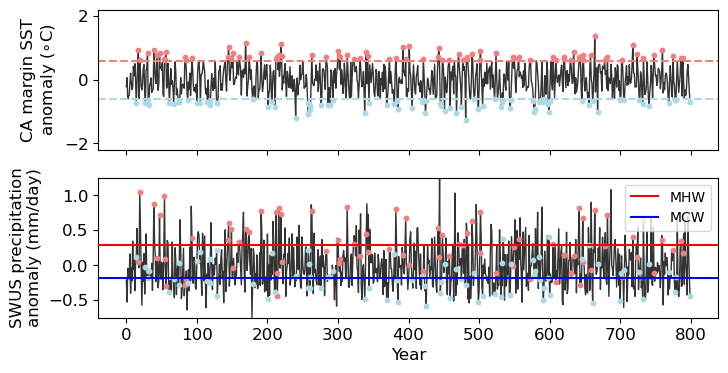

In [13]:
fig, ax = plt.subplots(2,1,figsize = (8,4), sharex = True)

ma2x = data['marg_detrend_dict_mon']['CESM104']['abrupt4x']
m_pr = data['sw_detrend_dict_mon']['CESM104']['abrupt4x']
p1 = np.percentile(ma2x, 90)
p2 = np.percentile(ma2x, 10)

ind_h = np.where(ma2x > p1)[0]
ind_c = np.where(ma2x <p2)[0]
rain_when_mhw= m_pr[ind_h]
rain_when_mcw= m_pr[ind_c]
mean_h = np.mean(rain_when_mhw)
mean_c = np.mean(rain_when_mcw)

# runs = consecutive(inds)
# ind_N = len(runs)    

# z_score = (mean_p - avg_precip_all) / (std_precip_all/ np.sqrt(ind_N))

plt.sca(ax[0])
plt.plot(ma2x, color = 'k', alpha = 0.8, linewidth = 1)
plt.scatter(ind_h, ma2x[ind_h], color = 'lightcoral', zorder = 2, s= 10)
plt.axhline(p1, color = 'lightcoral', linestyle = '--')
plt.scatter(ind_c, ma2x[ind_c], color = 'lightblue', zorder = 2, s= 10)
plt.axhline(p2, color = 'lightblue', linestyle = '--')

plt.ylabel("CA margin SST\nanomaly ($\circ$C)", fontsize = 12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.ylim([-2.2,2.2])

plt.sca(ax[1])
plt.plot(m_pr, color = 'k', alpha = 0.8, linewidth = 1)
plt.scatter(ind_h, m_pr[ind_h], color = 'lightcoral', zorder = 2, s= 10)
plt.axhline(mean_h, color = 'r', label = 'MHW', zorder = 10)
plt.scatter(ind_c, m_pr[ind_c], color = 'lightblue', zorder = 2, s= 10)
plt.axhline(mean_c, color = 'b', label = 'MCW', zorder = 10)

plt.xlabel("Year", fontsize = 12)
plt.ylabel("SWUS precipitation\nanomaly (mm/day)", fontsize = 12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.ylim([-0.75,1.25])
plt.legend(loc = 'upper right')
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/for_thesis/MHW_lines.jpg', dpi = 300,bbox_inches="tight")

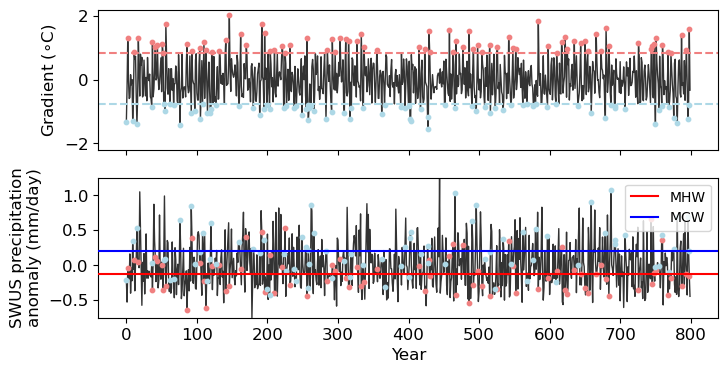

In [14]:
# Again but using the gradient as the SST index

fig, ax = plt.subplots(2,1,figsize = (8,4), sharex = True)

marg = data['marg_detrend_dict_mon']['CESM104']['abrupt4x']
eep = data['eep_detrend_dict_mon']['CESM104']['abrupt4x']

index = marg-eep

m_pr = data['sw_detrend_dict_mon']['CESM104']['abrupt4x']
p1 = np.percentile(index, 90)
p2 = np.percentile(index, 10)

ind_h = np.where(index > p1)[0]
ind_c = np.where(index <p2)[0]
rain_when_mhw= m_pr[ind_h]
rain_when_mcw= m_pr[ind_c]
mean_h = np.mean(rain_when_mhw)
mean_c = np.mean(rain_when_mcw)

# runs = consecutive(inds)
# ind_N = len(runs)    

# z_score = (mean_p - avg_precip_all) / (std_precip_all/ np.sqrt(ind_N))

plt.sca(ax[0])
plt.plot(index, color = 'k', alpha = 0.8, linewidth = 1)
plt.scatter(ind_h, index[ind_h], color = 'lightcoral', zorder = 2, s= 10)
plt.axhline(p1, color = 'lightcoral', linestyle = '--')
plt.scatter(ind_c, index[ind_c], color = 'lightblue', zorder = 2, s= 10)
plt.axhline(p2, color = 'lightblue', linestyle = '--')

plt.ylabel("Gradient ($\circ$C)", fontsize = 12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.ylim([-2.2,2.2])

plt.sca(ax[1])
plt.plot(m_pr, color = 'k', alpha = 0.8, linewidth = 1)
plt.scatter(ind_h, m_pr[ind_h], color = 'lightcoral', zorder = 2, s= 10)
plt.axhline(mean_h, color = 'r', label = 'MHW', zorder = 10)
plt.scatter(ind_c, m_pr[ind_c], color = 'lightblue', zorder = 2, s= 10)
plt.axhline(mean_c, color = 'b', label = 'MCW', zorder = 10)

plt.xlabel("Year", fontsize = 12)
plt.ylabel("SWUS precipitation\nanomaly (mm/day)", fontsize = 12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.ylim([-0.75,1.25])
plt.legend(loc = 'upper right')
# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/for_thesis/MHW_lines.jpg', dpi = 300,bbox_inches="tight")

# Checking ENSO

In [22]:
def regress_ENSO_seasonal(nino_index, sst_index):


    len = nino_index.shape[0]
    x = nino_index[:len]
    y = sst_index[:len]
    polyfit = np.polyfit(x, y,1)
    poly = np.poly1d(polyfit)
    fit = poly(x)
    marg_wo_enso_seasonal = y - fit

    return marg_wo_enso_seasonal

In [23]:
marg_mon= data['marg_detrend_dict_mon']
pr_mon = data['sw_detrend_dict_mon']
nino_mon = data['nino_detrend_dict_mon']

marg_mon_noenso = {}

for mod in all_models:
    exps = model_experiments[mod]
    marg_mon_noenso[mod]=  {}
    for exp in exps:
        marg_mon_noenso[mod][exp] = regress_ENSO_seasonal(nino_mon[mod][exp], marg_mon[mod][exp])


pr_mon_noenso = {}

for mod in all_models:
    exps = model_experiments[mod]
    pr_mon_noenso[mod] = {}
    for exp in exps:
        pr_mon_noenso[mod][exp] = regress_ENSO_seasonal(nino_mon[mod][exp], pr_mon[mod][exp])


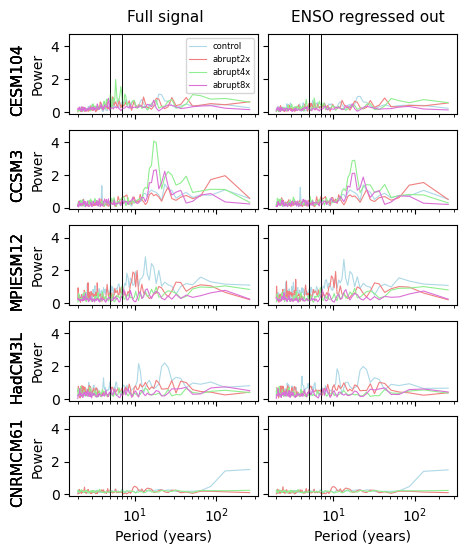

In [15]:
import scipy.signal as sig
marg_summer = data['marg_detrend_dict_mon']
fig, ax = plt.subplots(5,2,figsize=(5,6), sharex = True, sharey = True, 
                       gridspec_kw={'wspace': 0.05, 'hspace': 0.2})
ax = ax.ravel()
chunkLength = 256

for j, mod in enumerate(all_models):
    exps = model_experiments[mod]
    plot_num = j*2
    plt.sca(ax[plot_num])
    for i,exp in enumerate(exps):
        
        modexp = marg_summer[mod][exp]
        f, p = sig.welch(modexp, window='hann', nperseg=chunkLength, noverlap=chunkLength/2.)
        
        periods = 1 / f
        
        # Mask out the zero frequency to avoid divide-by-zero
        mask = f > 0
        periods = periods[mask]
        power = p[mask]
    
    
        plt.plot(periods, power, label = exp, color = colors_scatter[exp], linewidth = 0.8)
    
        
    
    
        plt.ylabel("Power")
        plt.title("Power Spectrum")
        plt.xscale('log')
        # plt.xticks(np.arange(1,100,5))
        plt.axvline(5, color = 'k', alpha = 0.7, linewidth =0.5)
        plt.axvline(7, color = 'k', alpha = 0.7, linewidth =0.5)
        # plt.xlim([2,20])
        plt.title(" ")
        plt.text(0.45, 2, mod, fontsize=11, 
                     va='center', ha='right', rotation=90)

    plot_num = j*2+1
    plt.sca(ax[plot_num])
    for i,exp in enumerate(exps):
        
        modexp = marg_mon_noenso[mod][exp]
        f, p = sig.welch(modexp, window='hann', nperseg=chunkLength, noverlap=chunkLength/2.)
        
        periods = 1 / f
        
        # Mask out the zero frequency to avoid divide-by-zero
        mask = f > 0
        periods = periods[mask]
        power = p[mask]
    
    
        plt.plot(periods, power, label = exp, color = colors_scatter[exp], linewidth = 0.8)
    
        
    
    
        # plt.xlabel("Period (years)")
        plt.title("Power Spectrum")
        plt.xscale('log')
        # plt.xticks(np.arange(1,100,5))
        plt.axvline(5, color = 'k', alpha = 0.7, linewidth =0.5)
        plt.axvline(7, color = 'k', alpha = 0.7, linewidth =0.5)
        # plt.xlim([2,20])
        plt.ylim([-0.1,4.75])
        plt.yticks([0,2,4])
        plt.title(" ")

plt.sca(ax[0])
plt.legend(fontsize = 6)
plt.text(8,5.5,"Full signal",fontsize = 11)
plt.sca(ax[1])
plt.text(3,5.5,"ENSO regressed out",fontsize = 11)
plt.sca(ax[8])
plt.xlabel("Period (years)")
plt.sca(ax[9])
plt.xlabel("Period (years)")

fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/for_thesis/power_spec.jpg', dpi = 300,bbox_inches="tight")

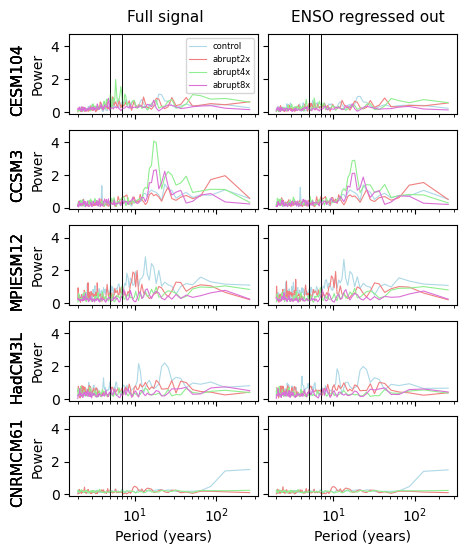

In [28]:
import scipy.signal as sig
marg_summer = data['marg_detrend_dict_mon']
fig, ax = plt.subplots(5,2,figsize=(5,6), sharex = True, sharey = True, 
                       gridspec_kw={'wspace': 0.05, 'hspace': 0.2})
ax = ax.ravel()
chunkLength = 256

for j, mod in enumerate(all_models):
    exps = model_experiments[mod]
    plot_num = j*2
    plt.sca(ax[plot_num])
    for i,exp in enumerate(exps):

        
        modexp = marg_summer[mod][exp]

        f, p = sig.welch(
            modexp,
            fs=1,                         # one JJAS value per year
            window="hann",
            nperseg=chunkLength,
            noverlap=chunkLength // 2,
            detrend = 'constant'
        )
        # f, p = sig.welch(modexp, window='hann', nperseg=chunkLength, noverlap=chunkLength/2.)
        
        periods = 1 / f
        
        # Mask out the zero frequency to avoid divide-by-zero
        mask = f > 0
        periods = periods[mask]
        power = p[mask]
    
    
        plt.plot(periods, power, label = exp, color = colors_scatter[exp], linewidth = 0.8)
    
        
    
    
        plt.ylabel("Power")
        plt.title("Power Spectrum")
        plt.xscale('log')
        # plt.xticks(np.arange(1,100,5))
        plt.axvline(5, color = 'k', alpha = 0.7, linewidth =0.5)
        plt.axvline(7, color = 'k', alpha = 0.7, linewidth =0.5)
        # plt.xlim([2,20])
        plt.title(" ")
        plt.text(0.45, 2, mod, fontsize=11, 
                     va='center', ha='right', rotation=90)

    plot_num = j*2+1
    plt.sca(ax[plot_num])
    for i,exp in enumerate(exps):
        
        modexp = marg_mon_noenso[mod][exp]
        # f, p = sig.welch(modexp, window='hann', nperseg=chunkLength, noverlap=chunkLength/2.)
        f, p = sig.welch(
            modexp,
            fs=1,                         # one JJAS value per year
            window="hann",
            nperseg=chunkLength,
            noverlap=chunkLength // 2,
            detrend = 'constant'
        )
        periods = 1 / f
        
        # Mask out the zero frequency to avoid divide-by-zero
        mask = f > 0
        periods = periods[mask]
        power = p[mask]
    
    
        plt.plot(periods, power, label = exp, color = colors_scatter[exp], linewidth = 0.8)
    
        
    
    
        # plt.xlabel("Period (years)")
        plt.title("Power Spectrum")
        plt.xscale('log')
        # plt.xticks(np.arange(1,100,5))
        plt.axvline(5, color = 'k', alpha = 0.7, linewidth =0.5)
        plt.axvline(7, color = 'k', alpha = 0.7, linewidth =0.5)
        # plt.xlim([2,20])
        plt.ylim([-0.1,4.75])
        plt.yticks([0,2,4])
        plt.title(" ")

plt.sca(ax[0])
plt.legend(fontsize = 6)
plt.text(8,5.5,"Full signal",fontsize = 11)
plt.sca(ax[1])
plt.text(3,5.5,"ENSO regressed out",fontsize = 11)
plt.sca(ax[8])
plt.xlabel("Period (years)")
plt.sca(ax[9])
plt.xlabel("Period (years)")

fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_review2/power_spec.jpg', dpi = 300,bbox_inches="tight")

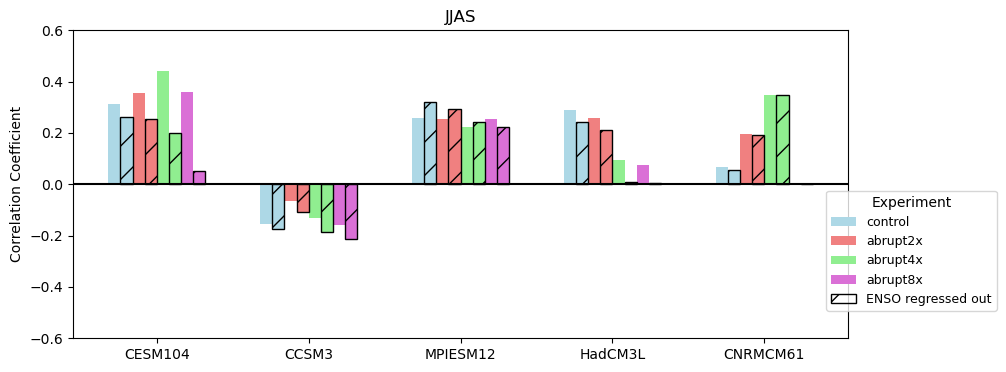

In [33]:
fig, ax = plt.subplots(1,1,figsize=(10, 4), sharex = True, sharey = True)

corr = np.zeros([5,4])
corr_noenso = np.zeros([5,4])
for i,mod in enumerate(all_models):
    exps = model_experiments[mod]
    for j,exp in enumerate(exps):
        x,y = marg_mon[mod][exp],pr_mon[mod][exp]
        r = scipy.stats.pearsonr(x, y)[0]
        corr[i,j] = r

        x,y = marg_mon_noenso[mod][exp],pr_mon_noenso[mod][exp]
        r = scipy.stats.pearsonr(x, y)[0]
        corr_noenso[i,j] = r


    
xpos = np.arange(len(all_models))
width = 0.08
exps = model_experiments['CESM104']
for j,e in enumerate(exps):
    offset = j*2*width
    plt.bar(xpos + offset, corr[:, j], width, label=model_experiments[all_models[0]][j], color = colors_scatter[e])
    plt.bar(xpos + offset+width, corr_noenso[:, j], width, label='no ENSO', hatch = '/',color = colors_scatter[e],edgecolor = 'k', zorder = 2)


plt.ylabel('Correlation Coefficient')
plt.title('JJAS')
n_exp = len(exps)
cluster_width = 2 * n_exp * width
plt.xticks(xpos + cluster_width/2 - width/2, all_models)
plt.axhline(0, color = 'k')
from matplotlib.patches import Patch
legend_handles = []
for i, exp in enumerate(exps):
    legend_handles.append(Patch(facecolor=colors_scatter[exp], label=exp))
legend_handles.append(Patch(facecolor='none', hatch='/', edgecolor='k', label='ENSO regressed out'))
plt.ylim(-0.6,0.6)
plt.legend(handles=legend_handles, title='Experiment', fontsize=9,bbox_to_anchor=(1.2, .5))
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_review2/corrs_enso.jpg', dpi = 300,bbox_inches="tight")


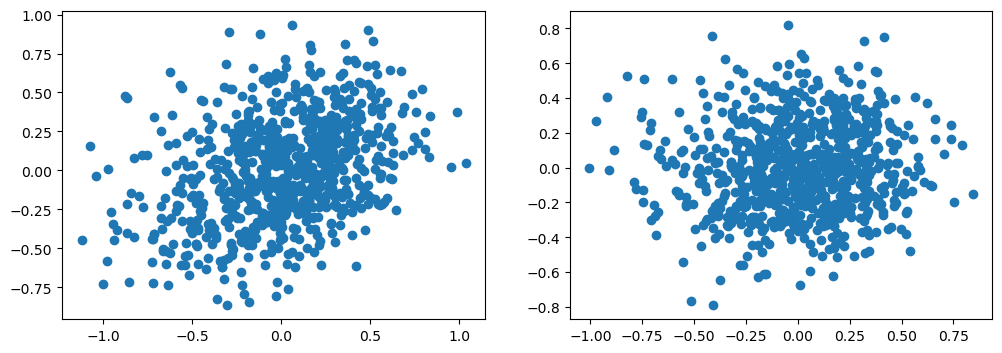

In [32]:
mod = 'CESM104'
exp = 'abrupt8x'
fig, ax = plt.subplots(1,2,figsize = (12,4))
ax[0].scatter(marg_mon[mod][exp],pr_mon[mod][exp])
ax[1].scatter(marg_mon_noenso[mod][exp],pr_mon_noenso[mod][exp])

# Equilibrium

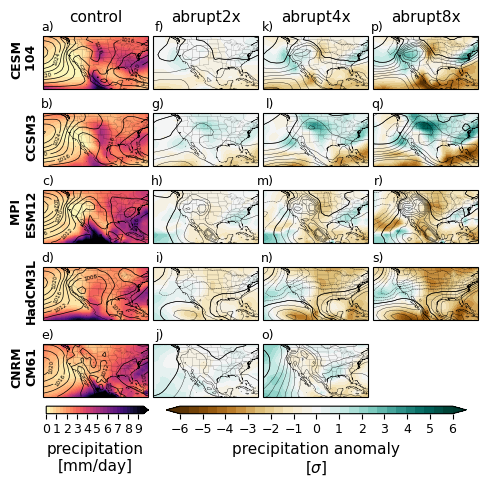

In [16]:
letters = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)','g)', 'h)', 'i)', 'j)', 'k)', 'l)','m)', 'n)', 'o)', 'p)', 'q)', 'r)', 's)']

fig, axes = plt.subplots(len(all_models), 4,
                         figsize=(6,5),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
    for col, exp in enumerate(exps):
        ax = axes[row, col]

        if col == 0:
            control_pr = data['pr_mon_map_nonanom_all'][mod]['control'][:1000]
            control_slp = data['slp_mon_map_nonanom_all'][mod]['control'][:1000]
            lon = control_pr.lon
            lat = control_pr.lat
            to_plot_pr =  control_pr[-200:].mean(axis = 0)
            to_plot_slp =  control_slp[-200:].mean(axis = 0)

            # Plot pr in colored filled contours
            c = ax.contourf(lon[15:], lat[10:26], to_plot_pr[10:26,15:], 
                            levels=np.linspace(0,9.5,30),
                            cmap = 'magma_r',
                            # norm = colors.TwoSlopeNorm(vcenter=0.),
                            transform=ccrs.PlateCarree(),
                            extend = 'max'
                           )
            # Plot SLP is black contour lines
            levels = np.arange(996, 1030,2)
            f2 = ax.contour(lon[15:], lat[10:26], to_plot_slp[10:26,15:], levels=levels,
                                      colors='black', linewidths=0.5,transform=ccrs.PlateCarree())
            ax.clabel(f2,levels = [1000,1004,1008,1012,1016,1020,1024] , fontsize=4, inline=True, inline_spacing=2
                     )


        else:
        
            control_pr = data['pr_mon_map_nonanom_all'][mod]['control'][:1000]
            other_exp_pr = data['pr_mon_map_nonanom_all'][mod][exp][:1000]
            control_slp = data['slp_mon_map_nonanom_all'][mod]['control'][:1000]
            other_exp_slp = data['slp_mon_map_nonanom_all'][mod][exp][:1000]
            lon = control_pr.lon
            lat = control_pr.lat
            to_plot_pr = (other_exp_pr[-200:].mean(axis = 0) - control_pr[-200:].mean(axis = 0))/control_pr[-200:].std(axis = 0)
            to_plot_slp = (other_exp_slp[-200:].mean(axis = 0) - control_slp[-200:].mean(axis = 0))/ control_slp[-200:].std(axis = 0)
            
            # Plot pr in colored filled contours
            f = ax.contourf(lon, lat, to_plot_pr, 
                            levels=np.linspace(-6,6,30),
                            cmap = 'BrBG',
                            norm = colors.TwoSlopeNorm(vcenter=0.),
                            transform=ccrs.PlateCarree(),
                            extend = 'both'
                           )

            # Plot SLP in black contour lines
            levels = np.arange(-6,7,1)
            f2 = ax.contour(lon, lat, to_plot_slp, levels=levels,
                                      colors='black', linewidths=0.25,transform=ccrs.PlateCarree())
            ax.contour(lon, lat, to_plot_slp, levels=[0],
                                      colors='black', linewidths=0.5,transform=ccrs.PlateCarree())


        ax.text(0.1, 1.15, letters[row+ col*5], fontsize=9,
        va='center', ha='right', transform=ax.transAxes)      


        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([220,290,16,46])

        # Model title
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9,fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)

        # Exp title
        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.1)

    # Delete unused columns if model has < 4 experiments
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Colorbars
cbar_ax1 = fig.add_axes([0.13, 0.1, 0.17, 0.015])  
cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="mm/day", ticks = np.arange(0,10,1))
cb.ax.tick_params(labelsize=9)
cb.set_label('precipitation\n[mm/day]', size=11)

cbar_ax2 = fig.add_axes([0.33, 0.1, 0.5, 0.015])  
cb=fig.colorbar(f, cax=cbar_ax2, orientation="horizontal", label="standard deviations", ticks = np.arange(-6,7,1))
cb.ax.tick_params(labelsize=9)
cb.set_label('precipitation anomaly\n[$\sigma$]', size=11)
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/slp_pr_eq_mean.jpg', dpi = 300,bbox_inches="tight")

In [18]:
# Control precip in SWUS
c = []
for mod in all_models:
    print(mod)
    control_pr = data['pr_mon_map_nonanom_all'][mod]['control'][:1000]
    control_pr = control_pr[-200:].mean(axis = 0)
    print(get_sw(control_pr))
    c.append(get_sw(control_pr))


CESM104
1.0663953646574749
CCSM3
0.7568386736156961
MPIESM12
0.7324116311644187
HadCM3L
1.440683999590142
CNRMCM61
1.0093198198885462


In [19]:
np.mean(c)

1.0011298977832557

In [20]:


eq_mean_pr = {}
diff_pr = {}
sigma_pr = {}
for mod in all_models:
    exps = model_experiments[mod]
    eq_mean_pr[mod] = {}
    diff_pr[mod] = {}
    sigma_pr[mod] = {}
    control_pr = data['pr_mon_map_nonanom_all'][mod]['control'][:1000]
    control_pr = control_pr[-200:].mean(axis = 0)
    control_pr = get_sw(control_pr)
    sw_ts = get_sw_ts(data['pr_mon_map_nonanom_all'][mod]['control'][:1000])
    sw_std = sw_ts[-200:].std()
    for exp in exps:
        exp_pr = data['pr_mon_map_nonanom_all'][mod][exp][:1000]
        exp_pr = exp_pr[-200:].mean(axis = 0)
        exp_pr = get_sw(exp_pr) 

        eq_mean_pr[mod][exp] = exp_pr
        diff_pr[mod][exp] = exp_pr - control_pr
        sigma_pr[mod][exp] = diff_pr[mod][exp]/sw_std

sigma_pr

{'CESM104': {'control': 0.0,
  'abrupt2x': -0.11420807441783812,
  'abrupt4x': 0.1502959470438703,
  'abrupt8x': 0.8420316227065122},
 'CCSM3': {'control': 0.0,
  'abrupt2x': 0.5203074665427143,
  'abrupt4x': 0.668532134390507,
  'abrupt8x': 0.9957047445320749},
 'MPIESM12': {'control': 0.0,
  'abrupt2x': -0.8129895006591583,
  'abrupt4x': -1.5980720914466569,
  'abrupt8x': -2.20902408662481},
 'HadCM3L': {'control': 0.0,
  'abrupt2x': -0.09557411185638896,
  'abrupt4x': -0.1898317634078009,
  'abrupt8x': -0.6916671314642189},
 'CNRMCM61': {'control': 0.0,
  'abrupt2x': -0.5789135153305743,
  'abrupt4x': -1.240539989428126}}

In [21]:
a2x = []
a4x = []
a8x = []
for mod in all_models:
    exps = model_experiments[mod]
    for exp in exps:
        if exp == 'abrupt2x':
            a2x.append(sigma_pr[mod][exp])
        elif exp == 'abrupt4x':
            a4x.append(sigma_pr[mod][exp])
        elif exp == 'abrupt8x':
            a8x.append(sigma_pr[mod][exp])
        else: 
            pass
             

In [22]:
np.mean(a8x)

-0.2657387127126104

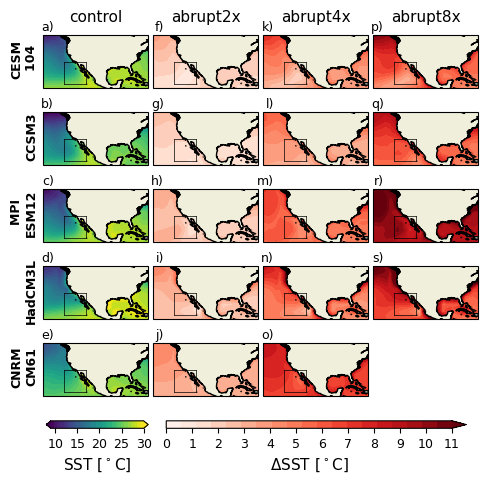

In [23]:
letters = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)','g)', 'h)', 'i)', 'j)', 'k)', 'l)','m)', 'n)', 'o)', 'p)', 'q)', 'r)', 's)']

fig, axes = plt.subplots(len(all_models), 4,
                         figsize=(6,5),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
    for col, exp in enumerate(exps):
        ax = axes[row, col]

        if col == 0:
            control = data['tas_mon_map_nonanom_all'][mod]['control'][:1000]
            lon = control.lon
            lat = control.lat
            to_plot =  control[-200:].mean(axis = 0) - 273

            c = ax.contourf(lon, lat, to_plot, 
                            levels=np.linspace(9,30,30),
                            cmap = 'viridis',
                            # norm = colors.TwoSlopeNorm(vcenter=0.),
                            transform=ccrs.PlateCarree(),
                            extend = 'both'
                           )
            
        else:

            control = data['tas_mon_map_nonanom_all'][mod]['control'][:1000]
            other_exp = data['tas_mon_map_nonanom_all'][mod][exp][:1000]
            lon = control.lon
            lat = control.lat
            to_plot = (other_exp[-200:].mean(axis = 0)-273) - (control[-200:].mean(axis = 0)- 273) 
        
            f = ax.contourf(lon, lat, to_plot, 
                            levels=np.linspace(0,11,20),
                            cmap = 'Reds',
                            # norm = colors.TwoSlopeNorm(vcenter=0.),
                            transform=ccrs.PlateCarree(),
                            extend = 'max'
                           )

        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cart.feature.LAND, zorder=2, edgecolor='k')
        ax.set_extent([220,290,16,46])
        

        # Model title
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9,fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        # Exp title
        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.1)
        
        ax.plot([233.75,233.75], [18.75, 33.75], color='k', linewidth=0.5,
            transform=ccrs.Geodetic())
    
        ax.plot([248.75,248.75], [18.75, 33.75], color='k', linewidth=.5,
                transform=ccrs.Geodetic())
        
        ax.plot([233.75, 248.75], [18.75, 18.75], color='k', linewidth=.5,
                transform=ccrs.Geodetic())
        
        ax.plot([233.75,248.75], [33.75,33.75], color='k', linewidth=.5,
                transform=ccrs.Geodetic())
        
        
        ax.text(0.1, 1.15, letters[row+ col*5], fontsize=9,
        va='center', ha='right', transform=ax.transAxes)    
        
    # Delete unused columns if model has < 4 experiments
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Colorbars
cbar_ax1 = fig.add_axes([0.13, 0.07, 0.17, 0.015])  
cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="C", ticks = np.arange(10,35,5))
cb.ax.tick_params(labelsize=9)
cb.set_label('SST [$^\circ$C]', size=11)

cbar_ax2 = fig.add_axes([0.33, 0.07, 0.5, 0.015])  
cb=fig.colorbar(f, cax=cbar_ax2, orientation="horizontal", label=r"$\Delta$C", ticks = np.arange(0,12,1))
cb.ax.tick_params(labelsize=9)
cb.set_label('$\Delta$SST [$^\circ$C]', size=11)
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/SST_mean.jpg', dpi = 300,bbox_inches="tight")

In [24]:
# Control precip in SWUS
c = []
for mod in all_models:
    print(mod)
    control_pr = data['tas_mon_map_nonanom_all'][mod]['control'][:1000]
    control_pr = control_pr[-200:].mean(axis = 0)
    print(get_ca(control_pr)-273)
    c.append(get_ca(control_pr)-273)


CESM104
23.424260300149626
CCSM3
22.373311431718264
MPIESM12
22.3614612915124
HadCM3L
22.971768424445656
CNRMCM61
23.899995917217666


In [25]:
np.mean(c)

23.006159473008722

In [34]:
data['tas_mon_map_nonanom_all'][mod]['control'][:1000][:,16:21,24:30].lon

<xarray.DataArray 'lon' (lon: 6)>
array([241.25, 243.75, 246.25, 248.75, 251.25, 253.75])
Coordinates:
  * lon      (lon) float64 241.2 243.8 246.2 248.8 251.2 253.8
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X

In [37]:
data['tas_mon_map_nonanom_all'][mod]['control'][:1000].sel(lat = slice(31.25,41.25), lon = slice(241.25, 253.75)).lon

<xarray.DataArray 'lon' (lon: 6)>
array([241.25, 243.75, 246.25, 248.75, 251.25, 253.75])
Coordinates:
  * lon      (lon) float64 241.2 243.8 246.2 248.8 251.2 253.8
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X

In [26]:
eq_mean = {}
diff = {}
for mod in all_models:
    exps = model_experiments[mod]
    eq_mean[mod] = {}
    diff[mod] = {}
    control_tas = data['tas_mon_map_nonanom_all'][mod]['control'][:1000]
    control_tas = control_tas[-200:].mean(axis = 0)
    control_tas = get_ca(control_tas) - 273
    for exp in exps:
        exp_pr = data['tas_mon_map_nonanom_all'][mod][exp][:1000]
        exp_pr = exp_pr[-200:].mean(axis = 0)
        exp_pr = get_ca(exp_pr) - 273

        eq_mean[mod][exp] = exp_pr
        diff[mod][exp] = exp_pr - control_tas
            

  
# eq_mean  = np.nanmean(eq_mean_array,  axis=0)



In [27]:
diff

{'CESM104': {'control': 0.0,
  'abrupt2x': 1.3531410604849725,
  'abrupt4x': 2.9953356026958886,
  'abrupt8x': 4.7103811407286},
 'CCSM3': {'control': 0.0,
  'abrupt2x': 1.5265352381269963,
  'abrupt4x': 3.6922817083008113,
  'abrupt8x': 5.937573702511315},
 'MPIESM12': {'control': 0.0,
  'abrupt2x': 2.3430465933697633,
  'abrupt4x': 5.286187833119413,
  'abrupt8x': 9.34276278397897},
 'HadCM3L': {'control': 0.0,
  'abrupt2x': 2.5064509224122276,
  'abrupt4x': 4.8241299400174285,
  'abrupt8x': 6.778014567913772},
 'CNRMCM61': {'control': 0.0,
  'abrupt2x': 3.2412306158055344,
  'abrupt4x': 6.565634732194383}}

In [28]:
a2x = []
a4x = []
a8x = []
for mod in all_models:
    exps = model_experiments[mod]
    for exp in exps:
        if exp == 'abrupt2x':
            a2x.append(diff[mod][exp])
        elif exp == 'abrupt4x':
            a4x.append(diff[mod][exp])
        elif exp == 'abrupt8x':
            a8x.append(diff[mod][exp])
        else: 
            pass
             

In [29]:
print(np.mean(a2x))
print(np.mean(a4x))
print(np.mean(a8x))

2.194080886039899
4.6727139632655845
6.692183048783164


In [30]:
a8x

[4.7103811407286, 5.937573702511315, 9.34276278397897, 6.778014567913772]

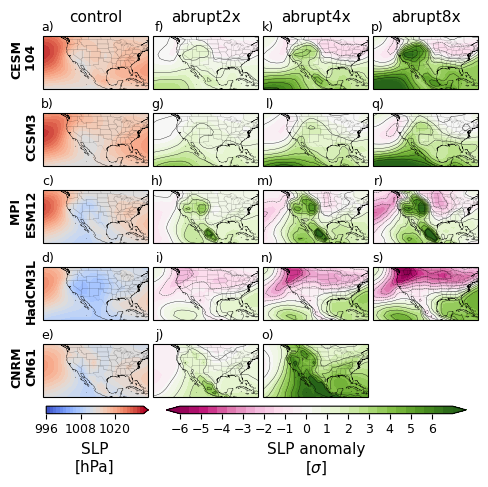

In [31]:
letters = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)','g)', 'h)', 'i)', 'j)', 'k)', 'l)','m)', 'n)', 'o)', 'p)', 'q)', 'r)', 's)']

fig, axes = plt.subplots(len(all_models), 4,
                         figsize=(6,5),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
    for col, exp in enumerate(exps):
        ax = axes[row, col]

        if col == 0:
            control_pr = data['pr_mon_map_nonanom_all'][mod]['control'][:1000]
            control_slp = data['slp_mon_map_nonanom_all'][mod]['control'][:1000]
            lon = control_pr.lon
            lat = control_pr.lat
            to_plot_pr =  control_pr[-200:].mean(axis = 0)
            to_plot_slp =  control_slp[-200:].mean(axis = 0)

            # Plot pr in colored filled contours
            c = ax.contourf(lon[15:], lat[10:26], to_plot_slp[10:26,15:], 
                          levels=np.linspace(996,1030,30),
                            cmap = 'coolwarm',
                            # norm = colors.TwoSlopeNorm(vcenter=0.),
                            transform=ccrs.PlateCarree(),
                            extend = 'max'
                           )
            # Plot SLP is black contour lines



        else:
        
            control_pr = data['pr_mon_map_nonanom_all'][mod]['control'][:1000]
            other_exp_pr = data['pr_mon_map_nonanom_all'][mod][exp][:1000]
            control_slp = data['slp_mon_map_nonanom_all'][mod]['control'][:1000]
            other_exp_slp = data['slp_mon_map_nonanom_all'][mod][exp][:1000]
            lon = control_pr.lon
            lat = control_pr.lat
            to_plot_pr = (other_exp_pr[-200:].mean(axis = 0) - control_pr[-200:].mean(axis = 0))/control_pr[-200:].std(axis = 0)
            to_plot_slp = (other_exp_slp[-200:].mean(axis = 0) - control_slp[-200:].mean(axis = 0))/ control_slp[-200:].std(axis = 0)
            
            # Plot pr in colored filled contours
            f = ax.contourf(lon, lat, to_plot_slp, 
                            levels=np.linspace(-6,7,30),
                            cmap = 'PiYG',
                            norm = colors.TwoSlopeNorm(vcenter=0.),
                            transform=ccrs.PlateCarree(),
                            extend = 'both'
                           )

            # Plot SLP in black contour lines

            levels = np.arange(-6,7,1)
            f2 = ax.contour(lon, lat, to_plot_slp, levels=levels,
                                      colors='black', linewidths=0.25,transform=ccrs.PlateCarree())

        ax.text(0.1, 1.15, letters[row+ col*5], fontsize=9,
        va='center', ha='right', transform=ax.transAxes)      


        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([220,290,16,46])

        # Model title
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9,fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)

        # Exp title
        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.1)

    # Delete unused columns if model has < 4 experiments
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Colorbars
cbar_ax1 = fig.add_axes([0.13, 0.1, 0.17, 0.015])  
cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="hPa", ticks = np.arange(996,1030,12))
cb.ax.tick_params(labelsize=9)
cb.set_label('SLP\n[hPa]', size=11)

cbar_ax2 = fig.add_axes([0.33, 0.1, 0.5, 0.015])  
cb=fig.colorbar(f, cax=cbar_ax2, orientation="horizontal", label="standard deviations", ticks = np.arange(-6,7,1))
cb.ax.tick_params(labelsize=9)
cb.set_label('SLP anomaly\n[$\sigma$]', size=11)

# MHW

0.3326482122285986
-0.16645360526351258
0.255466362833894
0.070577681287645
0.29595277147109256


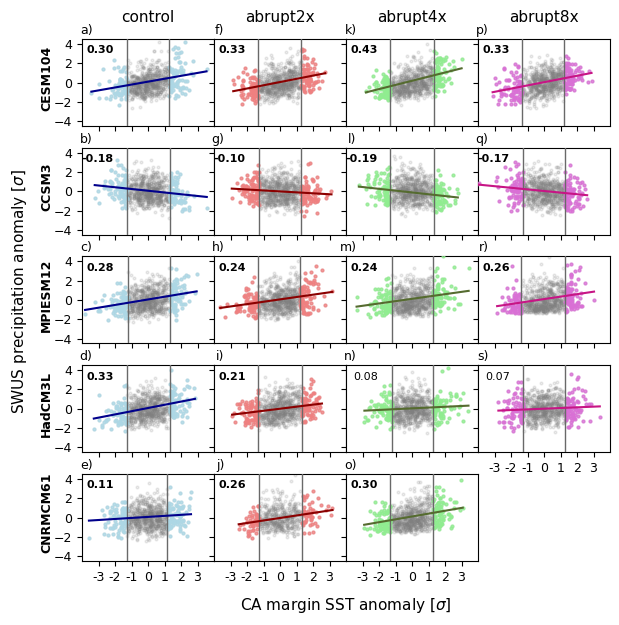

In [35]:
# Detrended CA margin SST dictionary
marg_mon = data['marg_detrend_dict_mon']
# Detrended SWUS precip dictionary
pr_mon = data['sw_detrend_dict_mon']
letters = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)','g)', 'h)', 'i)', 'j)', 'k)', 'l)','m)', 'n)', 'o)', 'p)', 'q)', 'r)', 's)']

fig, axes = plt.subplots(len(all_models),4, figsize=(6,6), sharex=False, sharey=True,
                         gridspec_kw={'wspace': 0, 'hspace': 0.25})
fig.subplots_adjust(left=0.1, right=0.98, top=0.92, bottom=0.05, wspace=0, hspace=0.25)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    title = mod
    
    all_m = []
    for col,exp in enumerate(exps):
        
        scatter_color = colors_scatter[exp]
        fit_color = colors_fit[exp]

        margin_raw = marg_mon[mod][exp][:800]
        margin = (marg_mon[mod][exp][:800]-np.mean(marg_mon[mod][exp][:800]))/ np.std(marg_mon[mod][exp][:800])
        southwest = (pr_mon[mod][exp][:800]-np.mean(pr_mon[mod][exp][:800]))/ np.std(pr_mon[mod][exp][:800])
        
        # Get 10th and 90th percentile CA margin SST
        p1 = np.percentile(margin_raw, 10)
        mcw_ind = np.where(margin_raw < p1)[0]
        p2 = np.percentile(margin_raw, 90)
        mhw_ind = np.where(margin_raw > p2)[0]

        p1_std = (p1 - margin_raw.mean())/margin_raw.std()
        p2_std = (p2 - margin_raw.mean())/margin_raw.std()

        # Concatenate precip during extreme SSTs
        x_mhw = np.concatenate([margin[mcw_ind], margin[mhw_ind]])
        y_mhw = np.concatenate([southwest[mcw_ind], southwest[mhw_ind]])
        
    
        ax = axes[row, col]
        ax.set_xticklabels([])
        
        ax.scatter(margin, southwest, color='gray', alpha=0.15, s = 4)
        ax.scatter(x_mhw, y_mhw, color=scatter_color, alpha=0.75, s = 4, zorder = 10)

        # Get regression between extreme CA margin SST and SWUS precipitation
        n = len(mhw_ind)
        m,b, r, p, se = scipy.stats.linregress(x_mhw,y_mhw)
        all_m.append(m)
        
        x_fit = np.linspace(x_mhw.min(), x_mhw.max(), 1000)
        # Plot fit
        ax.plot(x_fit, x_fit * m + b, color=fit_color, 
                label = f"m = {m:.2f}\np = {p:.1e} ", zorder = 15)

        # Plot p value in bold if significant
        if p < 0.05:
            ax.text(0.24,0.87, f"{m:.2f}", fontsize = 8,va='center', ha='right', transform=ax.transAxes, fontweight = 'bold')
        else:
            ax.text(0.24,0.87, f"{m:.2f}", fontsize = 8,va='center', ha='right', transform=ax.transAxes)

        # Model title
        if col == 0:
            ax.text(-0.22, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        # Exp title
        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.1)

        ax.text(0.08, 1.1, letters[row+ col*5], fontsize=9,
        va='center', ha='right', transform=ax.transAxes)     

        ax.axvline(p1_std, color = 'dimgrey', linewidth = 1, zorder = 12)
        ax.axvline(p2_std, color = 'dimgrey', linewidth = 1, zorder = 12)
        
        ax.set_yticks(np.arange(-4,6,2))
        ax.tick_params(labelsize=9)
        ax.set_ylim([-4.5,4.5])
        ax.set_xlim([-4,4])
        ax.set_xticks(np.arange(-3,4,1))
        ax.tick_params(labelsize=9)

        if row == 4:
            ax.set_xticklabels(np.arange(-3,4,1))

        if row == 3 and col == 3:
            ax.set_xticklabels(np.arange(-3,4,1))

    print(np.mean(m))   
    
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Add overall title
fig.supylabel("SWUS precipitation anomaly [$\sigma$]", fontsize=11, x = -0.02)
fig.supxlabel("CA margin SST anomaly [$\sigma$]", fontsize=11, x = 0.54, y = -0.04)
# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/jjas_figs/Extreme_scatter_bold_nolegend_allgray.jpg', dpi = 300,bbox_inches="tight")
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_pre_review/Extreme_scatter_bold_nolegend_allgray_newpercentile.jpg', dpi = 300,bbox_inches="tight")

0.3326482122285986
-0.16645360526351258
0.255466362833894
0.070577681287645
0.29595277147109256


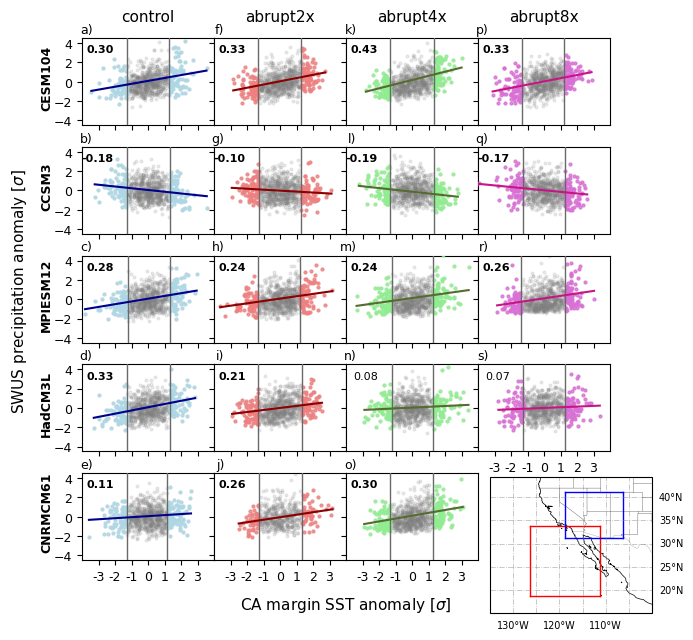

In [32]:
# Detrended CA margin SST dictionary
marg_mon = data['marg_detrend_dict_mon']
# Detrended SWUS precip dictionary
pr_mon = data['sw_detrend_dict_mon']
letters = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)','g)', 'h)', 'i)', 'j)', 'k)', 'l)','m)', 'n)', 'o)', 'p)', 'q)', 'r)', 's)']

fig, axes = plt.subplots(len(all_models),4, figsize=(6,6), sharex=False, sharey=True,
                         gridspec_kw={'wspace': 0, 'hspace': 0.25})
fig.subplots_adjust(left=0.1, right=0.98, top=0.92, bottom=0.05, wspace=0, hspace=0.25)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    title = mod
    
    all_m = []
    for col,exp in enumerate(exps):
        
        scatter_color = colors_scatter[exp]
        fit_color = colors_fit[exp]

        margin_raw = marg_mon[mod][exp][:800]
        margin = (marg_mon[mod][exp][:800]-np.mean(marg_mon[mod][exp][:800]))/ np.std(marg_mon[mod][exp][:800])
        southwest = (pr_mon[mod][exp][:800]-np.mean(pr_mon[mod][exp][:800]))/ np.std(pr_mon[mod][exp][:800])
        
        # Get 10th and 90th percentile CA margin SST
        p1 = np.percentile(margin_raw, 10)
        mcw_ind = np.where(margin_raw < p1)[0]
        p2 = np.percentile(margin_raw, 90)
        mhw_ind = np.where(margin_raw > p2)[0]

        p1_std = (p1 - margin_raw.mean())/margin_raw.std()
        p2_std = (p2 - margin_raw.mean())/margin_raw.std()

        # Concatenate precip during extreme SSTs
        x_mhw = np.concatenate([margin[mcw_ind], margin[mhw_ind]])
        y_mhw = np.concatenate([southwest[mcw_ind], southwest[mhw_ind]])
        
    
        ax = axes[row, col]
        ax.set_xticklabels([])
        
        ax.scatter(margin, southwest, color='gray', alpha=0.15, s = 4)
        ax.scatter(x_mhw, y_mhw, color=scatter_color, alpha=0.75, s = 4, zorder = 10)

        # Get regression between extreme CA margin SST and SWUS precipitation
        n = len(mhw_ind)
        m,b, r, p, se = scipy.stats.linregress(x_mhw,y_mhw)
        all_m.append(m)
        
        x_fit = np.linspace(x_mhw.min(), x_mhw.max(), 1000)
        # Plot fit
        ax.plot(x_fit, x_fit * m + b, color=fit_color, 
                label = f"m = {m:.2f}\np = {p:.1e} ", zorder = 15)

        # Plot p value in bold if significant
        if p < 0.05:
            ax.text(0.24,0.87, f"{m:.2f}", fontsize = 8,va='center', ha='right', transform=ax.transAxes, fontweight = 'bold')
        else:
            ax.text(0.24,0.87, f"{m:.2f}", fontsize = 8,va='center', ha='right', transform=ax.transAxes)

        # Model title
        if col == 0:
            ax.text(-0.22, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        # Exp title
        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.1)

        ax.text(0.08, 1.1, letters[row+ col*5], fontsize=9,
        va='center', ha='right', transform=ax.transAxes)     

        ax.axvline(p1_std, color = 'dimgrey', linewidth = 1, zorder = 12)
        ax.axvline(p2_std, color = 'dimgrey', linewidth = 1, zorder = 12)
        
        ax.set_yticks(np.arange(-4,6,2))
        ax.tick_params(labelsize=9)
        ax.set_ylim([-4.5,4.5])
        ax.set_xlim([-4,4])
        ax.set_xticks(np.arange(-3,4,1))
        ax.tick_params(labelsize=9)

        if row == 4:
            ax.set_xticklabels(np.arange(-3,4,1))

        if row == 3 and col == 3:
            ax.set_xticklabels(np.arange(-3,4,1))

    print(np.mean(m))   
    
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

ax_map = fig.add_axes([0.78, -0.06, 0.27, 0.27],
                      projection=ccrs.PlateCarree())
control_slp = data['slp_mon_map_nonanom_all'][mod]['control']
lon = control_slp.lon
lat = control_slp.lat
# c = ax_map.contourf(lon, lat, np.zeros([lat.shape[0],lon.shape[0]]), 
#                 #levels=np.linspace(10,30,30),
#                 # cmap = 'RdYlBu_r',
#                 # norm = colors.TwoSlopeNorm(vcenter=14.),
#                 transform=ccrs.PlateCarree(),
#                 # extend = 'both'
#                )

ax_map.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.5)
ax_map.add_feature(cf.STATES, lw=0.2, alpha = 0.5)
ax_map.set_extent([225,260,15,43])

ax_map.plot([233.75,233.75], [18.75, 33.75], color='r', linewidth=1,
           transform=ccrs.PlateCarree())
    
ax_map.plot([248.75,248.75], [18.75, 33.75], color='r', linewidth=1,
        transform=ccrs.PlateCarree())

ax_map.plot([233.75, 248.75], [18.75, 18.75], color='r', linewidth=1,
        transform=ccrs.PlateCarree())

ax_map.plot([233.75,248.75], [33.75,33.75], color='r', linewidth=1,
        transform=ccrs.PlateCarree())


ax_map.plot([241.25,241.25], [31.25, 41.25], color='b', linewidth=1,
           transform=ccrs.PlateCarree())
    
ax_map.plot([253.75,253.75], [31.25, 41.25], color='b', linewidth=1,
        transform=ccrs.PlateCarree())

ax_map.plot([241.25,253.75], [31.25, 31.25], color='b', linewidth=1,
        transform=ccrs.PlateCarree())

ax_map.plot([241.25,253.75], [41.25,41.25], color='b', linewidth=1,
        transform=ccrs.PlateCarree())

gl = ax_map.gridlines(crs=crs, draw_labels=True,
                  linewidth=.6, color='gray', alpha=0.5, linestyle='-.')

gl.top_labels = False
gl.left_labels = False
gl.bottom_labels = True
gl.right_labels = True
gl.xlabel_style = {"size" : 7}
gl.ylabel_style = {"size" : 7}


# Add overall title
fig.supylabel("SWUS precipitation anomaly [$\sigma$]", fontsize=11, x = -0.02)
fig.supxlabel("CA margin SST anomaly [$\sigma$]", fontsize=11, x = 0.54, y = -0.04)
# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/jjas_figs/Extreme_scatter_bold_nolegend_allgray.jpg', dpi = 300,bbox_inches="tight")
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/Extreme_scatter_bold_nolegend_allgray_newpercentile_withmap.jpg', dpi = 300,bbox_inches="tight")

0.3326482122285986
-0.16645360526351258
0.255466362833894
0.070577681287645
0.29595277147109256


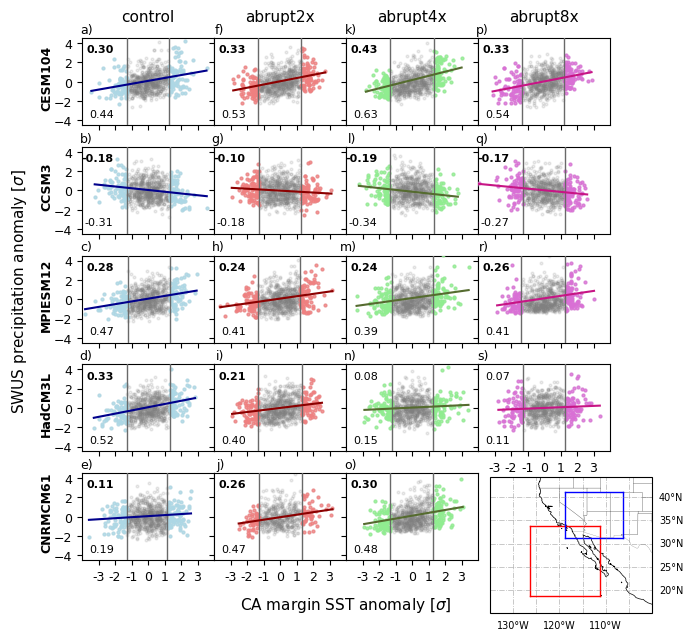

In [12]:
# Detrended CA margin SST dictionary
marg_mon = data['marg_detrend_dict_mon']
# Detrended SWUS precip dictionary
pr_mon = data['sw_detrend_dict_mon']
letters = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)','g)', 'h)', 'i)', 'j)', 'k)', 'l)','m)', 'n)', 'o)', 'p)', 'q)', 'r)', 's)']

fig, axes = plt.subplots(len(all_models),4, figsize=(6,6), sharex=False, sharey=True,
                         gridspec_kw={'wspace': 0, 'hspace': 0.25})
fig.subplots_adjust(left=0.1, right=0.98, top=0.92, bottom=0.05, wspace=0, hspace=0.25)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    title = mod
    
    all_m = []
    for col,exp in enumerate(exps):
        
        scatter_color = colors_scatter[exp]
        fit_color = colors_fit[exp]

        margin_raw = marg_mon[mod][exp][:800]
        margin = (marg_mon[mod][exp][:800]-np.mean(marg_mon[mod][exp][:800]))/ np.std(marg_mon[mod][exp][:800])
        southwest = (pr_mon[mod][exp][:800]-np.mean(pr_mon[mod][exp][:800]))/ np.std(pr_mon[mod][exp][:800])
        
        # Get 10th and 90th percentile CA margin SST
        p1 = np.percentile(margin_raw, 10)
        mcw_ind = np.where(margin_raw < p1)[0]
        p2 = np.percentile(margin_raw, 90)
        mhw_ind = np.where(margin_raw > p2)[0]

        p1_std = (p1 - margin_raw.mean())/margin_raw.std()
        p2_std = (p2 - margin_raw.mean())/margin_raw.std()

        # Concatenate precip during extreme SSTs
        x_mhw = np.concatenate([margin[mcw_ind], margin[mhw_ind]])
        y_mhw = np.concatenate([southwest[mcw_ind], southwest[mhw_ind]])
        
    
        ax = axes[row, col]
        ax.set_xticklabels([])
        
        ax.scatter(margin, southwest, color='gray', alpha=0.15, s = 4)
        ax.scatter(x_mhw, y_mhw, color=scatter_color, alpha=0.75, s = 4, zorder = 10)

        # Get regression between extreme CA margin SST and SWUS precipitation
        n = len(mhw_ind)
        m,b, r, p, se = scipy.stats.linregress(x_mhw,y_mhw)
        all_m.append(m)
        
        x_fit = np.linspace(x_mhw.min(), x_mhw.max(), 1000)
        # Plot fit
        ax.plot(x_fit, x_fit * m + b, color=fit_color, 
                label = f"m = {m:.2f}\np = {p:.1e} ", zorder = 15)

        # Plot p value in bold if significant
        if p < 0.05:
            ax.text(0.24,0.87, f"{m:.2f}", fontsize = 8,va='center', ha='right', transform=ax.transAxes, fontweight = 'bold')
        else:
            ax.text(0.24,0.87, f"{m:.2f}", fontsize = 8,va='center', ha='right', transform=ax.transAxes)

        ax.text(0.24,0.13, f"{r:.2f}", fontsize = 8,va='center', ha='right', transform=ax.transAxes)

        # Model title
        if col == 0:
            ax.text(-0.22, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        # Exp title
        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.1)

        ax.text(0.08, 1.1, letters[row+ col*5], fontsize=9,
        va='center', ha='right', transform=ax.transAxes)     

        ax.axvline(p1_std, color = 'dimgrey', linewidth = 1, zorder = 12)
        ax.axvline(p2_std, color = 'dimgrey', linewidth = 1, zorder = 12)
        
        ax.set_yticks(np.arange(-4,6,2))
        ax.tick_params(labelsize=9)
        ax.set_ylim([-4.5,4.5])
        ax.set_xlim([-4,4])
        ax.set_xticks(np.arange(-3,4,1))
        ax.tick_params(labelsize=9)

        if row == 4:
            ax.set_xticklabels(np.arange(-3,4,1))

        if row == 3 and col == 3:
            ax.set_xticklabels(np.arange(-3,4,1))

    print(np.mean(m))   
    
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

ax_map = fig.add_axes([0.78, -0.06, 0.27, 0.27],
                      projection=ccrs.PlateCarree())
control_slp = data['slp_mon_map_nonanom_all'][mod]['control']
lon = control_slp.lon
lat = control_slp.lat
# c = ax_map.contourf(lon, lat, np.zeros([lat.shape[0],lon.shape[0]]), 
#                 #levels=np.linspace(10,30,30),
#                 # cmap = 'RdYlBu_r',
#                 # norm = colors.TwoSlopeNorm(vcenter=14.),
#                 transform=ccrs.PlateCarree(),
#                 # extend = 'both'
#                )

ax_map.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.5)
ax_map.add_feature(cf.STATES, lw=0.2, alpha = 0.5)
ax_map.set_extent([225,260,15,43])

ax_map.plot([233.75,233.75], [18.75, 33.75], color='r', linewidth=1,
           transform=ccrs.PlateCarree())
    
ax_map.plot([248.75,248.75], [18.75, 33.75], color='r', linewidth=1,
        transform=ccrs.PlateCarree())

ax_map.plot([233.75, 248.75], [18.75, 18.75], color='r', linewidth=1,
        transform=ccrs.PlateCarree())

ax_map.plot([233.75,248.75], [33.75,33.75], color='r', linewidth=1,
        transform=ccrs.PlateCarree())


ax_map.plot([241.25,241.25], [31.25, 41.25], color='b', linewidth=1,
           transform=ccrs.PlateCarree())
    
ax_map.plot([253.75,253.75], [31.25, 41.25], color='b', linewidth=1,
        transform=ccrs.PlateCarree())

ax_map.plot([241.25,253.75], [31.25, 31.25], color='b', linewidth=1,
        transform=ccrs.PlateCarree())

ax_map.plot([241.25,253.75], [41.25,41.25], color='b', linewidth=1,
        transform=ccrs.PlateCarree())

gl = ax_map.gridlines(crs=crs, draw_labels=True,
                  linewidth=.6, color='gray', alpha=0.5, linestyle='-.')

gl.top_labels = False
gl.left_labels = False
gl.bottom_labels = True
gl.right_labels = True
gl.xlabel_style = {"size" : 7}
gl.ylabel_style = {"size" : 7}


# Add overall title
fig.supylabel("SWUS precipitation anomaly [$\sigma$]", fontsize=11, x = -0.02)
fig.supxlabel("CA margin SST anomaly [$\sigma$]", fontsize=11, x = 0.54, y = -0.04)
# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/jjas_figs/Extreme_scatter_bold_nolegend_allgray.jpg', dpi = 300,bbox_inches="tight")
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_pre_review/Extreme_scatter_bold_nolegend_allgray_newpercentile_withmap_corr.jpg', dpi = 300,bbox_inches="tight")

In [12]:
data.keys()

dict_keys(['sw_detrend_dict_mon_map', 'eq_cca_abs', 'slp_detrend_dict_mon_map', 'slp_mon_map_nonanom_all', 'marg_dict_mon', 'sw_detrend_dict_mon', 'tas_detrend_dict_mon_map', 'nino_dict_mon', 'pr_mon_map_nonanom_all', 'tas_mon_map_nonanom_all', 'sw_dict_mon', 'nino_detrend_dict_mon', 'eep_detrend_dict_mon', 'eep_dict_mon', 'marg_detrend_dict_mon'])

0.34029555479534
-0.14081883077399765
0.19348324183059204
0.029930854483290314
0.26520451758780245


Text(0.54, -0.04, 'CA margin SST anomaly [$\\sigma$]')

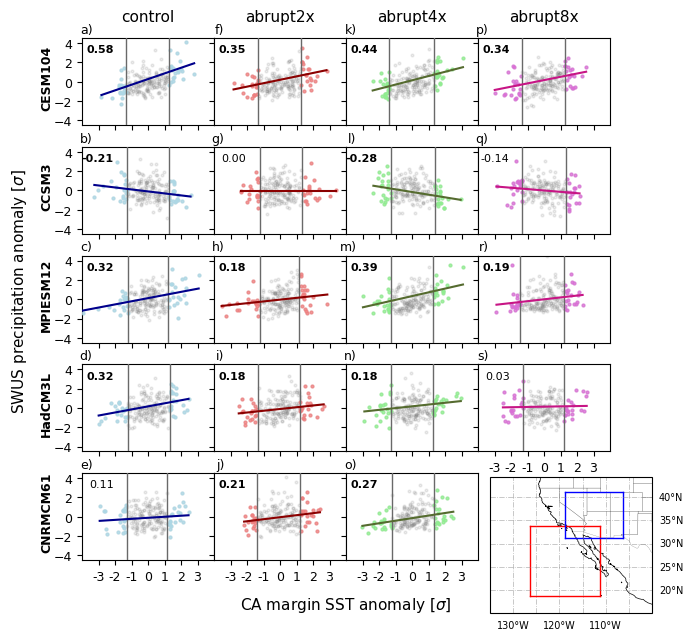

In [33]:
# Detrended CA margin SST dictionary

# Detrended SWUS precip dictionary

letters = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)','g)', 'h)', 'i)', 'j)', 'k)', 'l)','m)', 'n)', 'o)', 'p)', 'q)', 'r)', 's)']

fig, axes = plt.subplots(len(all_models),4, figsize=(6,6), sharex=False, sharey=True,
                         gridspec_kw={'wspace': 0, 'hspace': 0.25})
fig.subplots_adjust(left=0.1, right=0.98, top=0.92, bottom=0.05, wspace=0, hspace=0.25)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    title = mod
    
    all_m = []
    for col,exp in enumerate(exps):
        
        scatter_color = colors_scatter[exp]
        fit_color = colors_fit[exp]

        margin_raw = get_ca_ts(data['tas_mon_map_nonanom_all'][mod][exp][:1000][-200:])
        sw_raw = get_sw_ts(data['pr_mon_map_nonanom_all'][mod][exp][:1000][-200:])
        margin = (margin_raw-np.mean(margin_raw))/ np.std(margin_raw)
        southwest = (sw_raw-np.mean(sw_raw))/ np.std(sw_raw)
        
        # Get 10th and 90th percentile CA margin SST
        p1 = np.percentile(margin_raw, 10)
        mcw_ind = np.where(margin_raw < p1)[0]
        p2 = np.percentile(margin_raw, 90)
        mhw_ind = np.where(margin_raw > p2)[0]

        p1_std = (p1 - margin_raw.mean())/margin_raw.std()
        p2_std = (p2 - margin_raw.mean())/margin_raw.std()

        # Concatenate precip during extreme SSTs
        x_mhw = np.concatenate([margin[mcw_ind], margin[mhw_ind]])
        y_mhw = np.concatenate([southwest[mcw_ind], southwest[mhw_ind]])
        
    
        ax = axes[row, col]
        ax.set_xticklabels([])
        
        ax.scatter(margin, southwest, color='gray', alpha=0.15, s = 4)
        ax.scatter(x_mhw, y_mhw, color=scatter_color, alpha=0.75, s = 4, zorder = 10)

        # Get regression between extreme CA margin SST and SWUS precipitation
        n = len(mhw_ind)
        m,b, r, p, se = scipy.stats.linregress(x_mhw,y_mhw)
        all_m.append(m)
        
        x_fit = np.linspace(x_mhw.min(), x_mhw.max(), 1000)
        # Plot fit
        ax.plot(x_fit, x_fit * m + b, color=fit_color, 
                label = f"m = {m:.2f}\np = {p:.1e} ", zorder = 15)

        # Plot p value in bold if significant
        if p < 0.05:
            ax.text(0.24,0.87, f"{m:.2f}", fontsize = 8,va='center', ha='right', transform=ax.transAxes, fontweight = 'bold')
        else:
            ax.text(0.24,0.87, f"{m:.2f}", fontsize = 8,va='center', ha='right', transform=ax.transAxes)

        # Model title
        if col == 0:
            ax.text(-0.22, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        # Exp title
        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.1)

        ax.text(0.08, 1.1, letters[row+ col*5], fontsize=9,
        va='center', ha='right', transform=ax.transAxes)     

        ax.axvline(p1_std, color = 'dimgrey', linewidth = 1, zorder = 12)
        ax.axvline(p2_std, color = 'dimgrey', linewidth = 1, zorder = 12)
        
        ax.set_yticks(np.arange(-4,6,2))
        ax.tick_params(labelsize=9)
        ax.set_ylim([-4.5,4.5])
        ax.set_xlim([-4,4])
        ax.set_xticks(np.arange(-3,4,1))
        ax.tick_params(labelsize=9)

        if row == 4:
            ax.set_xticklabels(np.arange(-3,4,1))

        if row == 3 and col == 3:
            ax.set_xticklabels(np.arange(-3,4,1))

    print(np.mean(m))   
    
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

ax_map = fig.add_axes([0.78, -0.06, 0.27, 0.27],
                      projection=ccrs.PlateCarree())
control_slp = data['slp_mon_map_nonanom_all'][mod]['control']
lon = control_slp.lon
lat = control_slp.lat
# c = ax_map.contourf(lon, lat, np.zeros([lat.shape[0],lon.shape[0]]), 
#                 #levels=np.linspace(10,30,30),
#                 # cmap = 'RdYlBu_r',
#                 # norm = colors.TwoSlopeNorm(vcenter=14.),
#                 transform=ccrs.PlateCarree(),
#                 # extend = 'both'
#                )

ax_map.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.5)
ax_map.add_feature(cf.STATES, lw=0.2, alpha = 0.5)
ax_map.set_extent([225,260,15,43])

ax_map.plot([233.75,233.75], [18.75, 33.75], color='r', linewidth=1,
           transform=ccrs.PlateCarree())
    
ax_map.plot([248.75,248.75], [18.75, 33.75], color='r', linewidth=1,
        transform=ccrs.PlateCarree())

ax_map.plot([233.75, 248.75], [18.75, 18.75], color='r', linewidth=1,
        transform=ccrs.PlateCarree())

ax_map.plot([233.75,248.75], [33.75,33.75], color='r', linewidth=1,
        transform=ccrs.PlateCarree())


ax_map.plot([241.25,241.25], [31.25, 41.25], color='b', linewidth=1,
           transform=ccrs.PlateCarree())
    
ax_map.plot([253.75,253.75], [31.25, 41.25], color='b', linewidth=1,
        transform=ccrs.PlateCarree())

ax_map.plot([241.25,253.75], [31.25, 31.25], color='b', linewidth=1,
        transform=ccrs.PlateCarree())

ax_map.plot([241.25,253.75], [41.25,41.25], color='b', linewidth=1,
        transform=ccrs.PlateCarree())

gl = ax_map.gridlines(crs=crs, draw_labels=True,
                  linewidth=.6, color='gray', alpha=0.5, linestyle='-.')

gl.top_labels = False
gl.left_labels = False
gl.bottom_labels = True
gl.right_labels = True
gl.xlabel_style = {"size" : 7}
gl.ylabel_style = {"size" : 7}


# Add overall title
fig.supylabel("SWUS precipitation anomaly [$\sigma$]", fontsize=11, x = -0.02)
fig.supxlabel("CA margin SST anomaly [$\sigma$]", fontsize=11, x = 0.54, y = -0.04)
# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/jjas_figs/Extreme_scatter_bold_nolegend_allgray.jpg', dpi = 300,bbox_inches="tight")
# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_pre_review/Extreme_scatter_bold_nolegend_allgray_newpercentile_withmap.jpg', dpi = 300,bbox_inches="tight")

In [20]:
360-data['pr_mon_map_nonanom_all'][mod][exp][:1000][-200:][:,16:21,24:30].lon

<xarray.DataArray 'lon' (lon: 6)>
array([118.75, 116.25, 113.75, 111.25, 108.75, 106.25])
Coordinates:
  * lon      (lon) float64 241.2 243.8 246.2 248.8 251.2 253.8

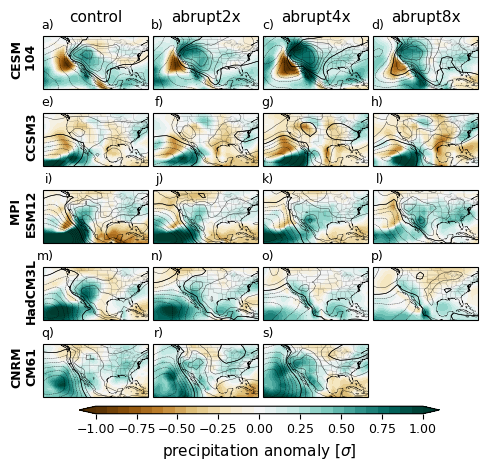

In [35]:
precip_maps_s = data['sw_detrend_dict_mon_map']
margin_ts_s = data['marg_detrend_dict_mon']
sw_ts_s = data['sw_detrend_dict_mon']
tas_maps_s = data['tas_detrend_dict_mon_map']
slp_maps_s = data['slp_detrend_dict_mon_map']


letters = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)','g)', 'h)', 'i)', 'j)', 'k)', 'l)','m)', 'n)', 'o)', 'p)', 'q)', 'r)', 's)']
fig, axes = plt.subplots(len(all_models), 4,
                         figsize=(6,5),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod

    for col, exp in enumerate(exps):
        ax = axes[row, col]

        
        lat = tas_maps_s[mod][exp].lat
        lon = tas_maps_s[mod][exp].lon

        # Get vars for model and experiment
        marg = margin_ts_s[mod][exp][:800]
        sw = sw_ts_s[mod][exp][:800]
        slp_map = slp_maps_s[mod][exp][:800]
        pr_map = precip_maps_s[mod][exp][:800]

        # Get MHW mons    
        p90, inds, N, z, mean_pr = MHW(marg,sw, type = 'heat')

        # Pr composite mean during MHWs
        mhw_pr = pr_map[inds,:,:]
        plot = (mhw_pr.mean(axis = 0) - pr_map.mean(axis = 0)) / pr_map.std(axis = 0)

        # SLP composite mean during MHWs
        mhw_slp = slp_map[inds,:,:]
        slp_contours = (mhw_slp.mean(axis = 0) - slp_map.mean(axis = 0)) / slp_map.std(axis = 0)

        # Plot pr mean
        f = ax.contourf(lon, lat, plot, 
                        levels = np.linspace(-1,1, 30), 
                        cmap = 'BrBG',
                        norm = colors.TwoSlopeNorm(vcenter=0.),
                        transform=ccrs.PlateCarree(),
                        extend = 'both'
                       )

        # Plot SLP mean
        levels = np.arange(-1.,1,.2)
        ax.contour(lon, lat, slp_contours, levels=levels,
                                  colors='black', linewidths=0.25, transform=ccrs.PlateCarree())

        ax.contour(lon, lat, slp_contours, levels=[0],
                                  colors='black', linewidths=0.5, transform=ccrs.PlateCarree())

        
        
        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([220,290,16,46])

        ax.text(0.1, 1.2, letters[row*4 + col], fontsize=9,
        va='center', ha='right', transform=ax.transAxes)   

        # Model title
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        # Exp title
        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.1)
        
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Colorbar

cbar_ax1 = fig.add_axes([0.185, 0.1, 0.6, 0.015])  
cb = fig.colorbar(f, cax=cbar_ax1, ticks = np.arange(-1,1.25,0.25), orientation = 'horizontal')
cb.ax.tick_params(labelsize=9)
cb.set_label('precipitation anomaly [$\sigma$]', size=11)
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/MHW_composite.jpg', dpi = 300,bbox_inches="tight")

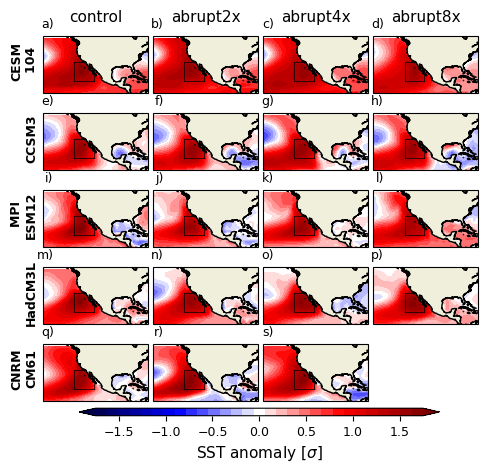

In [37]:
precip_maps_s = data['sw_detrend_dict_mon_map']
margin_ts_s = data['marg_detrend_dict_mon']
sw_ts_s = data['sw_detrend_dict_mon']
tas_maps_s = data['tas_detrend_dict_mon_map']
slp_maps_s = data['slp_detrend_dict_mon_map']


letters = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)','g)', 'h)', 'i)', 'j)', 'k)', 'l)','m)', 'n)', 'o)', 'p)', 'q)', 'r)', 's)']
fig, axes = plt.subplots(len(all_models), 4,
                         figsize=(6,5),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod

    for col, exp in enumerate(exps):
        ax = axes[row, col]

        
        lat = tas_maps_s[mod][exp].lat
        lon = tas_maps_s[mod][exp].lon

        # Get vars for model and experiment
        marg = margin_ts_s[mod][exp][:800]
        sw = sw_ts_s[mod][exp][:800]
        slp_map = slp_maps_s[mod][exp][:800]
        tas_map = tas_maps_s[mod][exp][:800]

        # Get MHW mons    
        p90, inds, N, z, mean_pr = MHW(marg,sw, type = 'heat')

        # Pr composite mean during MHWs
        mhw_tas = tas_map[inds,:,:]
        plot = (mhw_tas.mean(axis = 0) - tas_map.mean(axis = 0)) / tas_map.std(axis = 0)

        # # SLP composite mean during MHWs
        # mhw_slp = slp_map[inds,:,:]
        # slp_contours = (mhw_slp.mean(axis = 0) - slp_map.mean(axis = 0)) / slp_map.std(axis = 0)

        # Plot pr mean
        f = ax.contourf(lon, lat, plot, 
                        levels = np.linspace(-1.75,1.75, 30), 
                        cmap = 'seismic',
                        norm = colors.TwoSlopeNorm(vcenter=0.),
                        transform=ccrs.PlateCarree(),
                        extend = 'both'
                       )

        # Plot SLP mean
        # levels = np.arange(-1.,1,.2)
        # ax.contour(lon, lat, slp_contours, levels=levels,
        #                           colors='black', linewidths=0.25, transform=ccrs.PlateCarree())

        # ax.contour(lon, lat, slp_contours, levels=[0],
        #                           colors='black', linewidths=0.5, transform=ccrs.PlateCarree())

        ax.plot([233.75,233.75], [18.75, 33.75], color='k', linewidth=0.5,
            transform=ccrs.Geodetic())
    
        ax.plot([248.75,248.75], [18.75, 33.75], color='k', linewidth=.5,
                transform=ccrs.Geodetic())
        
        ax.plot([233.75, 248.75], [18.75, 18.75], color='k', linewidth=.5,
                transform=ccrs.Geodetic())
        
        ax.plot([233.75,248.75], [33.75,33.75], color='k', linewidth=.5,
                transform=ccrs.Geodetic())
        
        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.add_feature(cart.feature.LAND, zorder=2, edgecolor='k')
        ax.set_extent([210,290,10,46])

        ax.text(0.1, 1.2, letters[row*4 + col], fontsize=9,
        va='center', ha='right', transform=ax.transAxes)   

        # Model title
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        # Exp title
        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.1)
        
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Colorbar

cbar_ax1 = fig.add_axes([0.185, 0.1, 0.6, 0.015])  
cb = fig.colorbar(f, cax=cbar_ax1, ticks = np.arange(-1.5,2,0.5), orientation = 'horizontal')
cb.ax.tick_params(labelsize=9)
cb.set_label('SST anomaly [$\sigma$]', size=11)
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/MHW_compositeSST.jpg', dpi = 300,bbox_inches="tight")

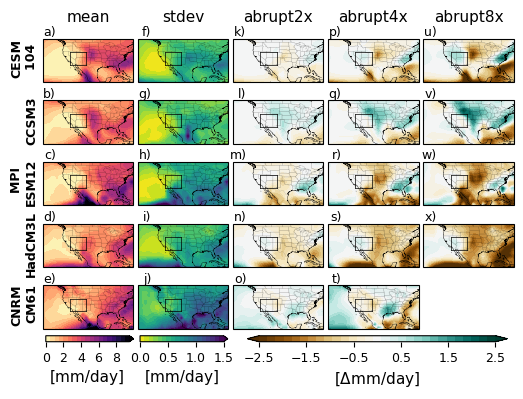

In [38]:
model_experiments_si = {
    'CESM104': ['mean','stdev', 'abrupt2x', 'abrupt4x', 'abrupt8x'],
    'CCSM3': ['mean', 'stdev','abrupt2x', 'abrupt4x', 'abrupt8x'],
    'MPIESM12': ['mean','stdev', 'abrupt2x', 'abrupt4x', 'abrupt8x'],
    'HadCM3L': ['mean', 'stdev','abrupt2x', 'abrupt4x', 'abrupt8x'],
    'CNRMCM61': ['mean','stdev', 'abrupt2x', 'abrupt4x']
}


letters = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)','g)', 'h)', 'i)', 'j)', 'k)', 'l)','m)', 'n)', 'o)', 'p)', 'q)', 'r)', 's)','t)', 'u)', 'v)', 'w)', 'x)']

fig, axes = plt.subplots(len(all_models), 5,
                         figsize=(6.5, 4),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments_si[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
        
    for col, exp in enumerate(exps):
        ax = axes[row, col]
        control_pr = data['pr_mon_map_nonanom_all'][mod]['control'][:1000]
        control_slp = data['slp_mon_map_nonanom_all'][mod]['control'][:1000]
        lon = control_pr.lon
        lat = control_pr.lat
        if col == 0:
            # Plot pr control mean
            to_plot_pr =  control_pr[-200:].mean(axis = 0)
            c = ax.contourf(lon[15:], lat[10:26], to_plot_pr[10:26,15:], 
                            levels=np.linspace(0,9.5,20),
                            cmap = 'magma_r',
                            # norm = colors.TwoSlopeNorm(vcenter=0.),
                            transform=ccrs.PlateCarree(),
                            extend = 'max'
                           )


        elif col == 1:
            # Plot pr control stdev
            to_plot_pr =  control_pr[-200:].std(axis = 0)
            g = ax.contourf(lon[15:], lat[10:26], to_plot_pr[10:26,15:], 
                            levels=np.linspace(0,1.5,20),
                            # cmap = 'gist_heat_r',
                            cmap = 'viridis_r',
                            # norm = colors.TwoSlopeNorm(vcenter=0.),
                            transform=ccrs.PlateCarree(),
                            extend = 'max'
                           )

        else:
            # Plot absolute pr anomaly
            other_exp_pr = data['pr_mon_map_nonanom_all'][mod][exp][:1000]
            to_plot_pr = (other_exp_pr[-200:].mean(axis = 0) - control_pr[-200:].mean(axis = 0))
        
            f = ax.contourf(lon, lat, to_plot_pr, 
                            levels=np.linspace(-2.5,2.5,30),
                            cmap = 'BrBG',
                            norm = colors.TwoSlopeNorm(vcenter=0.),
                            transform=ccrs.PlateCarree(),
                            extend = 'both'
                           )

        ax.text(0.15, 1.15, letters[row + col*5], fontsize=9,
        va='center', ha='right', transform=ax.transAxes)      

        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([220,290,18,46])

        # Model title
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9,fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        # Exp title
        if row == 0:
            ax.text(0.5, 1.5, exp, fontsize=11,
                    va='center', ha = 'center',transform=ax.transAxes)


        ax.plot([241.2,241.2], [31.25, 41.25], color='k', linewidth=.5,
        transform=ccrs.Geodetic())

        ax.plot([253.8,253.8], [31.25, 41.25], color='k', linewidth=.5,
                transform=ccrs.Geodetic())
        
        ax.plot([241.2,253.8], [31.25, 31.25], color='k', linewidth=.5,
                transform=ccrs.Geodetic())
        
        ax.plot([241.2 ,253.8], [41.25, 41.25], color='k', linewidth=.5,
                transform=ccrs.Geodetic())

    for col in range(len(exps), 5):
        fig.delaxes(axes[row, col])

# Colorbars
cbar_ax1 = fig.add_axes([0.13, 0.1, 0.135, 0.015])  
cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="mm/day", ticks = np.arange(0,9,2))
cb.ax.tick_params(labelsize=9)
cb.set_label('[mm/day]', size=11)

cbar_ax2 = fig.add_axes([0.275, 0.1, 0.135, 0.015])  
cb=fig.colorbar(g, cax=cbar_ax2, orientation="horizontal", label="mm/day", ticks = np.arange(0,2,0.5))
cb.ax.tick_params(labelsize=9)
cb.set_label('[mm/day]', size=11)

cbar_ax3 = fig.add_axes([0.44, 0.1, 0.4, 0.015])  
cb=fig.colorbar(f, cax=cbar_ax3, orientation="horizontal", label="standard deviations", ticks = np.arange(-2.5,3.5,1))
cb.ax.tick_params(labelsize=9)
cb.set_label(r'[$\Delta$mm/day]', size=11)
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/precip_raw_units.jpg', dpi = 300,bbox_inches="tight")

# CCA

In [39]:
def CCA_decomposition(slp_library, slp_target,pr_library,tas_library, Na, Ns, Nr):
    """
    Reconstructs SLP target from SLP library, computes precipitation assocaited with reconstructed SLP

    Parameters
    ----------
    slp_library : 3-D time series of sea level presssure, (time, lat, lon)
        SLP library

    slp_target : 2-D spatial map of sea level pressure, (lat, lon)
        SLP to reconstruct

    pr_library : 3-D time series of precipitation, (time, lat, lon)
        precipitation map library

    tas_library : 3-D time series of near surface temperature, (time, lat, lon)
        temperature map library

    Na : integer
        number of closest slp_library maps to retain

    Ns : integer
        number of maps to randomly subsample from Na, maps slp_target is reconstructed from

    Nr : integer
        number of times to repeat subsampling procedure

    Returns
    -------
    inds : array
        The randomly sampled Ns indices 

    distances: array
        Euclidean distances of Na closest SLP library maps

    weights: array
        correlation coefficients relating each Ns slp_library to the slp_target, weights that are applied to the corresponding pr_library maps 

    reconstruction_slp : 2-D map
        SLP pattern that resembles slp_target, reconstructed from slp_library

    reconstruction_pr : 2-D map
        precipitation pattern associated with the constrcuted reconstruction_slp

    reconstruction_tas: 2-D map
        temperature pattern associated with the constrcuted reconstruction_slp    
        
    """
    weights_lat = np.sqrt(np.cos(np.deg2rad(slp_target.lat)))
    weights_lat = np.asarray(weights_lat).squeeze()
    
    slp_target = np.array(slp_target)
    slp_library= np.array(slp_library)
    pr_library = np.array(pr_library)
    tas_library = np.array(tas_library)
    # print(slp_library.shape)
    slp_library_weighted = slp_library * weights_lat[None,:, None]
    slp_target_weighted = slp_target * weights_lat[:, None]
    
    # Flatten the arrays so I can compute distances
    flat_target = slp_target_weighted.flatten()
    
    Nt = slp_library.shape[0]
    flat_slp_library = slp_library_weighted.reshape(Nt, -1)
    flat_pr_library = pr_library.reshape(Nt, -1)
    flat_tas_library = tas_library.reshape(Nt, -1)
    
    lat = slp_target.shape[0]
    lon = slp_target.shape[1]

    flat_shape = lat*lon
    
    # Compute Euclidean distances for each time step in flat_slp_library
    dists = np.linalg.norm(flat_slp_library - flat_target, axis=1)
    
    # Get indices and distances of smallest distances
    best_indices = np.argsort(dists)[:Na]
    distances = dists[best_indices]
    
    # Create arrays to store each reconstruction in Nr
    resample_recon_slp = np.zeros([Nr, flat_shape])
    resample_recon_pr = np.zeros([Nr, flat_shape])
    resample_recon_tas = np.zeros([Nr, flat_shape])

    # Subsampling procedure
    for i in range(Nr):
        # Randomly sample Ns indices from Na without replacement. These are our candidate maps
        inds = np.random.choice(best_indices, size = Ns, replace = False)
        
        slp_analog_fields = flat_slp_library[inds,:]
        pr_analog_fields = flat_pr_library[inds,:]
        tas_analog_fields = flat_tas_library[inds,:]

        # Least squares regression. Compute Ns coefficients (weights) that relate each slp_analog_fields to flat_target
        weights, residuals, rank, s = np.linalg.lstsq(slp_analog_fields.T, flat_target, rcond=None)

        # Apply weights to each candidate map (SLP, pr, and tas) and linearly combine.
        # The weights that relate SLP maps are applied to the corresponding pr and tas library maps
        reconstruction_slp_flat = slp_analog_fields.T @ weights
        resample_recon_slp[i,:] = reconstruction_slp_flat
        
        reconstruction_pr_flat = pr_analog_fields.T @ weights
        resample_recon_pr[i,:] = reconstruction_pr_flat

        reconstruction_tas_flat = tas_analog_fields.T @ weights
        resample_recon_tas[i,:] = reconstruction_tas_flat

    # Take mean of the Nr best estimates to get the final analog, reshape back to lat lon
    reconstruction_pr = resample_recon_pr.mean(axis = 0).reshape(lat, lon)   
    reconstruction_slp = resample_recon_slp.mean(axis = 0).reshape(lat, lon)  
    reconstruction_tas = resample_recon_tas.mean(axis = 0).reshape(lat, lon) 
    
    return inds, distances, weights, reconstruction_slp, reconstruction_pr, reconstruction_tas


In [40]:
slp_map = data['slp_mon_map_nonanom_all']
pr_map = data['pr_mon_map_nonanom_all']
tas_map = data['tas_mon_map_nonanom_all']

# Dictionaries to hold circulation/dynamic component
mean_circ_slp_eq = {}
mean_circ_pr_eq = {}
mean_circ_tas_eq = {}

# Dictionaries to hold residual/thermodynamic component
mean_pr_resid_eq = {}
mean_slp_resid_eq = {}
mean_tas_resid_eq = {}

# Dictionaries to hold total anomaly
mean_slp_eq = {}
mean_pr_eq = {}
mean_tas_eq = {}

# Dictionaries to hold control standard deviations
control_pr_std = {}
control_slp_std = {}
control_tas_std = {}

np.random.seed(0)

for mod in all_models:
    exps = model_experiments[mod]
    mean_circ_slp_eq[mod] = {}
    mean_circ_pr_eq[mod] = {}
    mean_circ_tas_eq[mod] = {}
    
    mean_pr_resid_eq[mod] = {}
    mean_slp_resid_eq[mod] = {}
    mean_tas_resid_eq[mod] = {}
    
    mean_slp_eq[mod] = {}
    mean_pr_eq[mod] = {}
    mean_tas_eq[mod] = {}


    slp_control = slp_map[mod]['control'][:1000]
    pr_control = pr_map[mod]['control'][:1000]
    tas_control = tas_map[mod]['control'][:1000]

    slp_control_mean = slp_control[-200:].mean(axis = 0)
    pr_control_mean = pr_control[-200:].mean(axis = 0)
    tas_control_mean = tas_control[-200:].mean(axis = 0)

    slp_control_std = slp_control[-200:].std(axis = 0)
    pr_control_std = pr_control[-200:].std(axis = 0)
    tas_control_std = tas_control[-200:].std(axis = 0)

    control_pr_std[mod] = pr_control_std
    control_slp_std[mod] = slp_control_std
    control_tas_std[mod] = tas_control_std

    # Getting control library anomalies
    slp_library = (slp_control - slp_control_mean)
    pr_library = (pr_control - pr_control_mean)
    tas_library = (tas_control - tas_control_mean)

    for exp in exps:

        slp = slp_map[mod][exp][:1000,:,:]
        pr = pr_map[mod][exp][:1000,:,:]
        tas = tas_map[mod][exp][:1000,:,:]
    
        pr_eq_exp = pr[-200:].mean(axis = 0)
        tas_eq_exp = tas[-200:].mean(axis = 0)
        slp_eq_exp = slp[-200:].mean(axis = 0)

        # Remove control mean to get anomaly relative to control
        pr_prime = (pr_eq_exp - pr_control_mean)
        slp_prime = (slp_eq_exp - slp_control_mean)
        tas_prime = (tas_eq_exp - tas_control_mean) 
    
        slp_target = slp_prime
        inds_analog, dists, weights, circ_slp, circ_pr , circ_tas= CCA_decomposition(slp_library, slp_target,pr_library, tas_library, Na=150, Ns=70, Nr = 100)
    
        mean_circ_slp_eq[mod][exp] =  circ_slp
        mean_circ_pr_eq[mod][exp] =  circ_pr
        mean_circ_tas_eq[mod][exp] =  circ_tas
    
        mean_slp_eq[mod][exp] =  slp_prime  
        mean_pr_eq[mod][exp] =   pr_prime 
        mean_tas_eq[mod][exp] =   tas_prime
    
        mean_pr_resid_eq[mod][exp] = pr_prime - circ_pr
        mean_slp_resid_eq[mod][exp] = slp_prime - circ_slp
        mean_tas_resid_eq[mod][exp] =tas_prime - circ_tas


In [41]:
mean_pr_eq[mod][exp][16:21,24:30].lon

<xarray.DataArray 'lon' (lon: 6)>
array([241.25, 243.75, 246.25, 248.75, 251.25, 253.75])
Coordinates:
  * lon      (lon) float64 241.2 243.8 246.2 248.8 251.2 253.8
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X

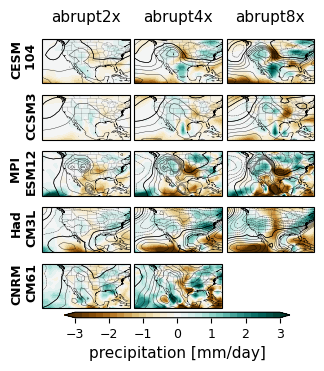

In [42]:
lon = slp_map['CESM104']['control'].lon
lat = slp_map['CESM104']['control'].lat

fig, axes = plt.subplots(len(all_models), 3,
                         figsize=(3.75, 3.65),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod][1:]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod == 'HadCM3L':
        title = 'Had\nCM3L'
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
    for col, exp in enumerate(exps):
        ax = axes[row, col]

        f = ax.contourf(lon, lat, mean_circ_pr_eq[mod][exp],
                           levels=np.linspace(-3,3,30),
                           cmap='BrBG',
                           norm=colors.TwoSlopeNorm(vcenter=0.),
                           transform=ccrs.PlateCarree(),
                           extend='both')
        

        levels = np.arange(-3,3.5,0.5)
        c_eq = ax.contour(lon, lat, mean_circ_slp_eq[mod][exp],
                          levels=levels, colors='black', linewidths=0.25,
                          transform=ccrs.PlateCarree())
        # ax.clabel(c_eq, fmt='%d', fontsize=5, inline=True, inline_spacing=2)

        ax.contour(lon, lat, mean_circ_slp_eq[mod][exp],
                           levels=[0], colors='black', linewidths=0.5,
                           transform=ccrs.PlateCarree())


        # Add coastlines and features
        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([220,290,16,46])

        
        # Titles and labels
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)

        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.2)
        
    # Delete unused columns if model has < 4 experiments
    for col in range(len(exps), 3):
        fig.delaxes(axes[row, col])

# Colorbar
# cbar_ax = fig.add_axes([0.99, 0.35, 0.015, 0.3])
cbar_ax1 = fig.add_axes([0.185, 0.1, 0.6, 0.015])  
cb = fig.colorbar(f, cax=cbar_ax1, ticks = np.arange(-3,4,1), orientation = 'horizontal')
cb.ax.tick_params(labelsize=9)
cb.set_label('precipitation [mm/day]', size=11)
# Super labels
# fig.suptitle("Pr MHW detrended", fontsize=9, x=0.54, y = 0.95)
# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_pre_review/eq_circ_mmday.jpg', dpi = 300,bbox_inches="tight")

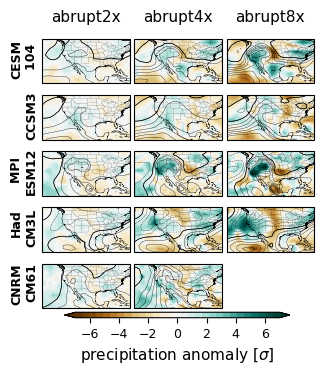

In [43]:
lon = slp_map['CESM104']['control'].lon
lat = slp_map['CESM104']['control'].lat

fig, axes = plt.subplots(len(all_models), 3,
                         figsize=(3.75, 3.65),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod][1:]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod == 'HadCM3L':
        title = 'Had\nCM3L'
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
    for col, exp in enumerate(exps):
        ax = axes[row, col]

        f = ax.contourf(lon, lat, mean_circ_pr_eq[mod][exp]/control_pr_std[mod],
                           levels=np.linspace(-7,7,30),
                           cmap='BrBG',
                           norm=colors.TwoSlopeNorm(vcenter=0.),
                           transform=ccrs.PlateCarree(),
                           extend='both')
        

        levels = np.arange(-6,7,1)
        c_eq = ax.contour(lon, lat, mean_circ_slp_eq[mod][exp]/control_slp_std[mod],
                          levels=levels, colors='black', linewidths=0.25,
                          transform=ccrs.PlateCarree())
        # ax.clabel(c_eq, fmt='%d', fontsize=5, inline=True, inline_spacing=2)

        ax.contour(lon, lat, mean_circ_slp_eq[mod][exp]/control_slp_std[mod],
                           levels=[0], colors='black', linewidths=0.5,
                           transform=ccrs.PlateCarree())


        # Add coastlines and features
        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([220,290,16,46])

        
        # Titles and labels
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)

        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.2)
        
    # Delete unused columns if model has < 4 experiments
    for col in range(len(exps), 3):
        fig.delaxes(axes[row, col])

# Colorbar
# cbar_ax = fig.add_axes([0.99, 0.35, 0.015, 0.3])
cbar_ax1 = fig.add_axes([0.185, 0.1, 0.6, 0.015])  
cb = fig.colorbar(f, cax=cbar_ax1, ticks = np.arange(-6,8,2), orientation = 'horizontal')
cb.ax.tick_params(labelsize=9)
cb.set_label('precipitation anomaly [$\sigma$]', size=11)
# Super labels
# fig.suptitle("Pr MHW detrended", fontsize=9, x=0.54, y = 0.95)
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/eq_circ_sigma.jpg', dpi = 300,bbox_inches="tight")

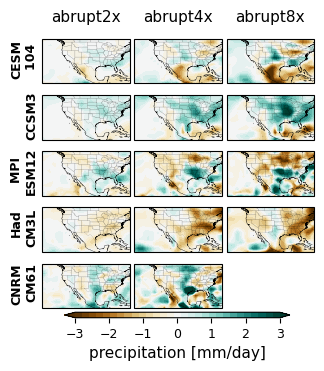

In [44]:
lon = slp_map['CESM104']['control'].lon
lat = slp_map['CESM104']['control'].lat

fig, axes = plt.subplots(len(all_models), 3,
                         figsize=(3.75, 3.65),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod][1:]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod == 'HadCM3L':
        title = 'Had\nCM3L'
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
    for col, exp in enumerate(exps):
        ax = axes[row, col]

        f = ax.contourf(lon, lat, mean_pr_resid_eq[mod][exp],
                           levels=np.linspace(-3,3,30),
                           cmap='BrBG',
                           norm=colors.TwoSlopeNorm(vcenter=0.),
                           transform=ccrs.PlateCarree(),
                           extend='both')
        

        # levels = np.arange(-6,7,1)
        # c_eq = ax.contour(lon, lat, mean_circ_slp_eq[mod][exp]/control_slp_std[mod],
        #                   levels=levels, colors='black', linewidths=0.25,
        #                   transform=ccrs.PlateCarree())
        # # ax.clabel(c_eq, fmt='%d', fontsize=5, inline=True, inline_spacing=2)

        # ax.contour(lon, lat, mean_circ_slp_eq[mod][exp]/control_slp_std[mod],
        #                    levels=[0], colors='black', linewidths=0.5,
        #                    transform=ccrs.PlateCarree())


        # Add coastlines and features
        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([220,290,16,46])

        
        # Titles and labels
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)

        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.2)
        
    # Delete unused columns if model has < 4 experiments
    for col in range(len(exps), 3):
        fig.delaxes(axes[row, col])

# Colorbar
# cbar_ax = fig.add_axes([0.99, 0.35, 0.015, 0.3])
cbar_ax1 = fig.add_axes([0.185, 0.1, 0.6, 0.015])  
cb = fig.colorbar(f, cax=cbar_ax1, ticks = np.arange(-3,4,1), orientation = 'horizontal')
cb.ax.tick_params(labelsize=9)
cb.set_label('precipitation [mm/day]', size=11)
# Super labels
# fig.suptitle("Pr MHW detrended", fontsize=9, x=0.54, y = 0.95)

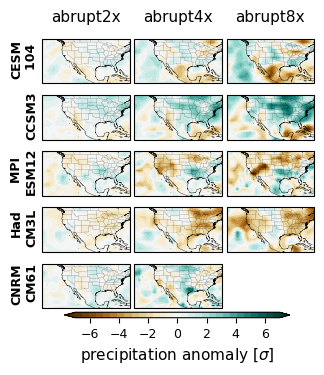

In [45]:
lon = slp_map['CESM104']['control'].lon
lat = slp_map['CESM104']['control'].lat

fig, axes = plt.subplots(len(all_models), 3,
                         figsize=(3.75, 3.65),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod][1:]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod == 'HadCM3L':
        title = 'Had\nCM3L'
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
    for col, exp in enumerate(exps):
        ax = axes[row, col]

        f = ax.contourf(lon, lat, mean_pr_resid_eq[mod][exp]/control_pr_std[mod],
                           levels=np.linspace(-7,7,30),
                           cmap='BrBG',
                           norm=colors.TwoSlopeNorm(vcenter=0.),
                           transform=ccrs.PlateCarree(),
                           extend='both')
        

        # levels = np.arange(-6,7,1)
        # c_eq = ax.contour(lon, lat, mean_circ_slp_eq[mod][exp]/control_slp_std[mod],
        #                   levels=levels, colors='black', linewidths=0.25,
        #                   transform=ccrs.PlateCarree())
        # # ax.clabel(c_eq, fmt='%d', fontsize=5, inline=True, inline_spacing=2)

        # ax.contour(lon, lat, mean_circ_slp_eq[mod][exp]/control_slp_std[mod],
        #                    levels=[0], colors='black', linewidths=0.5,
        #                    transform=ccrs.PlateCarree())


        # Add coastlines and features
        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([220,290,16,46])

        
        # Titles and labels
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)

        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.2)
        
    # Delete unused columns if model has < 4 experiments
    for col in range(len(exps), 3):
        fig.delaxes(axes[row, col])

# Colorbar
# cbar_ax = fig.add_axes([0.99, 0.35, 0.015, 0.3])
cbar_ax1 = fig.add_axes([0.185, 0.1, 0.6, 0.015])  
cb = fig.colorbar(f, cax=cbar_ax1, ticks = np.arange(-6,8,2), orientation = 'horizontal')
cb.ax.tick_params(labelsize=9)
cb.set_label('precipitation anomaly [$\sigma$]', size=11)
# Super labels
# fig.suptitle("Pr MHW detrended", fontsize=9, x=0.54, y = 0.95)
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/eq_resid_sigma.jpg', dpi = 300,bbox_inches="tight")

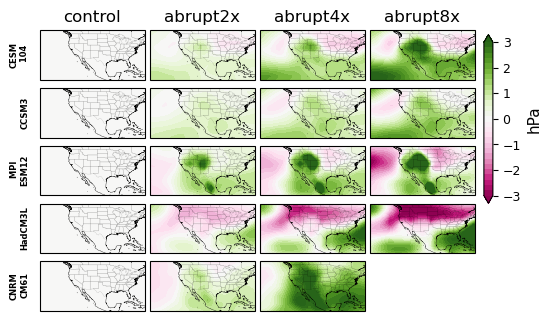

In [46]:
lon = slp_map['CESM104']['control'].lon
lat = slp_map['CESM104']['control'].lat

fig, axes = plt.subplots(len(all_models), 4,
                         figsize=(6,3.75),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.000001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
    for col, exp in enumerate(exps):
        ax = axes[row, col]


        f = ax.contourf(lon, lat,  mean_circ_slp_eq[mod][exp], 
                        levels = np.linspace(-3,3, 30), 
                        cmap = 'PiYG',
                        norm = colors.TwoSlopeNorm(vcenter=0.),
                        transform=ccrs.PlateCarree(),
                        extend = 'both'
                       )

        # Add coastlines and features

        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([215,290,16,45])

        
        # Titles and labels
        if col == 0:
            ax.text(-0.1, 0.5, title, fontsize=6, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        
        if row == 0:
            ax.set_title(exp, fontsize = 12)

    # Delete unused columns if model has < 4 experiments
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Colorbar
# cbar_ax = fig.add_axes([0.99, 0.35, 0.015, 0.3])
cbar_ax1 = fig.add_axes([0.865, 0.408, 0.015, 0.45])  
cb = fig.colorbar(f, cax=cbar_ax1, label="hPa", ticks = np.arange(-3,4,1)
            )
cb.ax.tick_params(labelsize=9)
cb.set_label('hPa', size=11)
# Super labels
# fig.suptitle("Pr MHW detrended", fontsize=9, x=0.54, y = 0.95)

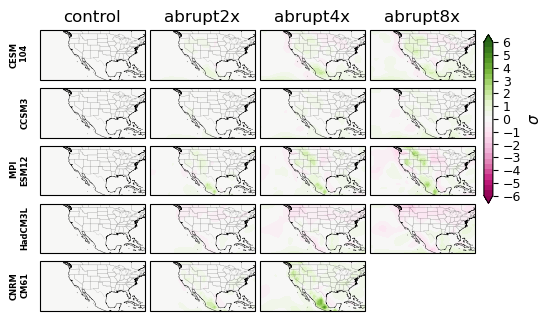

In [48]:
lon = slp_map['CESM104']['control'].lon
lat = slp_map['CESM104']['control'].lat

fig, axes = plt.subplots(len(all_models), 4,
                         figsize=(6,3.75),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.000001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
    for col, exp in enumerate(exps):
        ax = axes[row, col]


        f = ax.contourf(lon, lat,  mean_slp_resid_eq[mod][exp]/control_slp_std[mod], 
                        levels = np.linspace(-6,6, 30), 
                        cmap = 'PiYG',
                        norm = colors.TwoSlopeNorm(vcenter=0.),
                        transform=ccrs.PlateCarree(),
                        extend = 'both'
                       )

        # Add coastlines and features

        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([215,290,16,45])

        
        # Titles and labels
        if col == 0:
            ax.text(-0.1, 0.5, title, fontsize=6, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        
        if row == 0:
            ax.set_title(exp, fontsize = 12)

    # Delete unused columns if model has < 4 experiments
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Colorbar
# cbar_ax = fig.add_axes([0.99, 0.35, 0.015, 0.3])
cbar_ax1 = fig.add_axes([0.865, 0.408, 0.015, 0.45])  
cb = fig.colorbar(f, cax=cbar_ax1, label="hPa", ticks = np.arange(-6,7,1
                                            )
            )
cb.ax.tick_params(labelsize=9)
cb.set_label('$\sigma$', size=11)
# Super labels
# fig.suptitle("Pr MHW detrended", fontsize=9, x=0.54, y = 0.95)
# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/defense_figs/eq_slp_sigma_resid.jpg', dpi = 300,bbox_inches="tight")

In [49]:
# Get dictionary with decompoisition maps for MPIESM12 only, in mm/day
mod = 'MPIESM12'
mpi_data_pr_eq= {}
mpi_data_slp_eq = {}
mpi_data_tas_eq = {}

exps = model_experiments[mod]
for exp in exps:

    mpi_data_pr_eq[exp] = {
        'Total': mean_pr_eq[mod][exp],
        'Circulation':  mean_circ_pr_eq[mod][exp],
        'Residual': mean_pr_resid_eq[mod][exp]
    }

    mpi_data_slp_eq[exp] = {
        'Total': mean_slp_eq[mod][exp],
        'Circulation':  mean_circ_slp_eq[mod][exp],
        'Residual': mean_slp_resid_eq[mod][exp]
    }

    mpi_data_tas_eq[exp] = {
        'Total': mean_tas_eq[mod][exp],
        'Circulation':  mean_circ_tas_eq[mod][exp],
        'Residual': mean_tas_resid_eq[mod][exp]
    }

In [50]:
# Get equilibrium mean decomposition for SWUS, in mm/day
eq_contributions = {}

for mod in all_models:
    eq_contributions[mod] = {}
    exps = model_experiments[mod]
    for exp in exps:

        # Now I can area average the anomaly
        eq_comp = get_sw(mean_pr_eq[mod][exp])

        circ_comp = xr.DataArray(mean_circ_pr_eq[mod][exp],dims=[ "lat", "lon"],coords={"lat": lat, "lon":lon})
        circ_comp = get_sw(circ_comp)

        thermo_comp = xr.DataArray(mean_pr_resid_eq[mod][exp],dims=[ "lat", "lon"],coords={"lat": lat, "lon":lon})
        thermo_comp = get_sw(thermo_comp)
    
        eq_contributions[mod][exp] = {
            'Total': eq_comp,
            'Circulation': circ_comp,
            'Residual': thermo_comp
        }

# Set contributions to zero for CNRMCM61 because there is no abrupt8x experiment
eq_contributions['CNRMCM61'][ 'abrupt8x'] = {
            'Total': 0,
            'Circulation': 0,
            'Residual': 0
}


# mhw_contributions['CNRMCM61'][ 'abrupt8x'] = {
#             'Total': 0,
#             'Circulation': 0,
#             'Residual': 0
# }

In [51]:
eq_contributions

{'CESM104': {'control': {'Total': array(0.),
   'Circulation': array(0.),
   'Residual': array(0.)},
  'abrupt2x': {'Total': array(-0.03061986),
   'Circulation': array(0.16939934),
   'Residual': array(-0.2000192)},
  'abrupt4x': {'Total': array(0.04029511),
   'Circulation': array(0.1075185),
   'Residual': array(-0.06722339)},
  'abrupt8x': {'Total': array(0.22575352),
   'Circulation': array(0.26058477),
   'Residual': array(-0.03483127)}},
 'CCSM3': {'control': {'Total': array(0.),
   'Circulation': array(0.),
   'Residual': array(0.)},
  'abrupt2x': {'Total': array(0.09385062),
   'Circulation': array(0.1707064),
   'Residual': array(-0.07685578)},
  'abrupt4x': {'Total': array(0.1205867),
   'Circulation': array(0.2050663),
   'Residual': array(-0.08447961)},
  'abrupt8x': {'Total': array(0.17960056),
   'Circulation': array(0.06257093),
   'Residual': array(0.11702963)}},
 'MPIESM12': {'control': {'Total': array(0.),
   'Circulation': array(0.),
   'Residual': array(0.)},
  'ab

In [29]:
with open('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/data_mon/eq_cca_abs.pkl', 'wb') as f:
    pickle.dump(eq_contributions, f)

In [52]:
# Detrended variable maps
slp_map = data['slp_detrend_dict_mon_map']
pr_map = data['sw_detrend_dict_mon_map']
tas_map = data['tas_detrend_dict_mon_map']

# Ca margin SST and SWUS precipitation time series
marg_mon = data['marg_detrend_dict_mon']
sw_mon = data['sw_detrend_dict_mon']

# Dictionaries to hold dynamic/circulation component
mean_circ_slp_mhw = {}
mean_circ_pr_mhw = {}
mean_circ_tas_mhw = {}

# Dictionaries to hold residual/thermodynamic component
mean_pr_resid_mhw = {}
mean_slp_resid_mhw = {}
mean_tas_resid_mhw = {}

# Dictionaries to hold total anomalies
mean_slp_mhw = {}
mean_pr_mhw = {}
mean_tas_mhw = {}

# Dictionaries to hold variable standard deviations
pr_std = {}
slp_std = {}
tas_std = {}

np.random.seed(0)

for mod in all_models:
    exps = model_experiments[mod]
    mean_circ_slp_mhw[mod] = {}
    mean_circ_pr_mhw[mod] = {}
    mean_circ_tas_mhw[mod] = {}
    
    mean_pr_resid_mhw[mod] = {}
    mean_slp_resid_mhw[mod] = {}
    mean_tas_resid_mhw[mod] = {}
    
    mean_slp_mhw[mod] = {}
    mean_pr_mhw[mod]= {}
    mean_tas_mhw[mod]= {}

    pr_std[mod] = {}
    slp_std[mod] = {}
    tas_std[mod] = {}
    for exp in exps:
    
        # Get indices of MHW
        p90, inds_mhw, N, z, mean_pr = MHW(marg_mon[mod][exp][:800],sw_mon[mod][exp][:800], type = 'heat')

        slp = slp_map[mod][exp][:800,:,:]
        pr = pr_map[mod][exp][:800,:,:]
        tas = tas_map[mod][exp][:800,:,:]

        pr_std[mod][exp] = pr.std(axis = 0)
        slp_std[mod][exp] = slp.std(axis = 0)
        tas_std[mod][exp] = tas.std(axis = 0)

        # MHW mean anomaly relative to the entire time series
        slp_MHW_exp = (slp[inds_mhw,:,:] - slp.mean(axis = 0))
        pr_MHW_exp = (pr[inds_mhw,:,:]- pr.mean(axis = 0))
        tas_MHW_exp = (tas[inds_mhw,:,:]- tas.mean(axis = 0))

        # Mask out MHW indices from the libraries
        mask = ~np.isin(np.arange(slp.shape[0]), inds_mhw)
        slp_library = (slp[mask]- slp.mean(axis = 0))
        pr_library = (pr[mask]- pr.mean(axis = 0))
        tas_library = (tas[mask]- tas.mean(axis = 0))
        
        
        all_slp_analog = np.zeros([len(inds_mhw),25,45])
        all_pr_analog = np.zeros([len(inds_mhw),25,45])
        all_tas_analog = np.zeros([len(inds_mhw),25,45])
        pr_diff = np.zeros([len(inds_mhw),25,45])
        slp_diff = np.zeros([len(inds_mhw),25,45])
        tas_diff = np.zeros([len(inds_mhw),25,45])

        # For each MHW....
        for i, target  in enumerate(slp_MHW_exp):
            # For each MHW I do the entire resampling process (MHW loop is the outermost loop)
            inds_analog, dists, weights, circ_slp, circ_pr , circ_tas= CCA_decomposition(slp_library, target,pr_library,tas_library, Na=150, Ns=40, Nr = 100)

            # Components from the circulation reconstructions
            all_slp_analog[i,:,:] = circ_slp
            all_pr_analog[i,:,:] = circ_pr
            all_tas_analog[i,:,:] = circ_tas

            # The residual between the total MHW anomaly and the circulation component
            pr_diff[i,:,:] = pr_MHW_exp[i,:,:] - circ_pr
            slp_diff[i,:,:] = slp_MHW_exp[i,:,:] - circ_slp
            tas_diff[i,:,:] = tas_MHW_exp[i,:,:] - circ_tas
    
        # Average reconstructions of each MHW to get the final maps
        mean_circ_slp_mhw[mod][exp] =  all_slp_analog.mean(axis = 0)
        mean_circ_pr_mhw[mod][exp] =  all_pr_analog.mean(axis = 0)  
        mean_circ_tas_mhw[mod][exp] =  all_tas_analog.mean(axis = 0)  
    
        mean_slp_mhw[mod][exp] =  slp_MHW_exp.mean(axis = 0)   
        mean_pr_mhw[mod][exp] =   pr_MHW_exp.mean(axis = 0) 
        mean_tas_mhw[mod][exp] =   tas_MHW_exp.mean(axis = 0)

        mean_pr_resid_mhw[mod][exp] = pr_diff.mean(axis = 0)
        mean_slp_resid_mhw[mod][exp] = slp_diff.mean(axis = 0)
        mean_tas_resid_mhw[mod][exp] = tas_diff.mean(axis = 0)


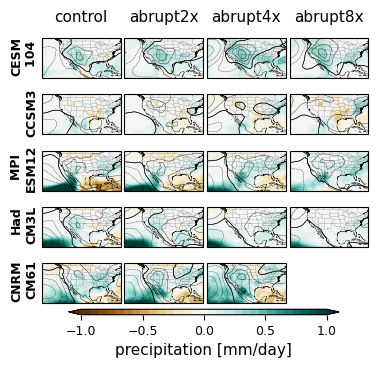

In [53]:
lon = slp_map['CESM104']['control'].lon
lat = slp_map['CESM104']['control'].lat

fig, axes = plt.subplots(len(all_models), 4,
                         figsize=(4.5, 3.65),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod == 'HadCM3L':
        title = 'Had\nCM3L'
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
    for col, exp in enumerate(exps):
        ax = axes[row, col]

        f = ax.contourf(lon, lat,  mean_circ_pr_mhw[mod][exp], 
                        levels = np.linspace(-1,1, 30), 
                        cmap = 'BrBG',
                        norm = colors.TwoSlopeNorm(vcenter=0.),
                        transform=ccrs.PlateCarree(),
                        extend = 'both'
                       )
        levels = np.arange(-1.,1,.2)
        f2 = ax.contour(lon, lat, mean_circ_slp_mhw[mod][exp], levels=levels,
                                  colors='black', linewidths=0.25, transform=ccrs.PlateCarree())
        # clabels = f2.clabel(fontsize = 5)
        f2 = ax.contour(lon, lat, mean_circ_slp_mhw[mod][exp], levels=[0],
                                  colors='black', linewidths=0.5, transform=ccrs.PlateCarree())


        # Add coastlines and features
        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([220,290,16,46])

        # ax.plot([241.2,241.2], [31.25, 41.25], color='k', linewidth=.5,
        # transform=ccrs.Geodetic())

        # ax.plot([253.8,253.8], [31.25, 41.25], color='k', linewidth=.5,
        #         transform=ccrs.Geodetic())
        
        # ax.plot([241.2,253.8], [31.25, 31.25], color='k', linewidth=.5,
        #         transform=ccrs.Geodetic())
        
        # ax.plot([241.2 ,253.8], [41.25, 41.25], color='k', linewidth=.5,
        #         transform=ccrs.Geodetic())

        
        # Titles and labels
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)

        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.2)
        
    # Delete unused columns if model has < 4 experiments
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Colorbar
# cbar_ax = fig.add_axes([0.99, 0.35, 0.015, 0.3])
cbar_ax1 = fig.add_axes([0.185, 0.1, 0.6, 0.015])  
cb = fig.colorbar(f, cax=cbar_ax1, ticks = np.arange(-1,1.5,0.5), orientation = 'horizontal')
cb.ax.tick_params(labelsize=9)
cb.set_label('precipitation [mm/day]', size=11)
# Super labels
# fig.suptitle("Pr MHW detrended", fontsize=9, x=0.54, y = 0.95)

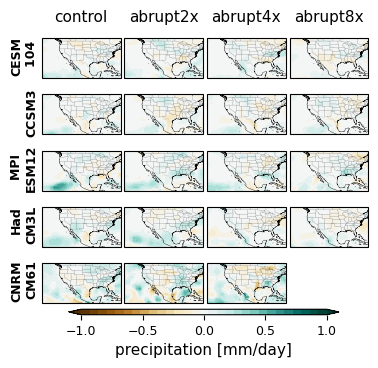

In [53]:
lon = slp_map['CESM104']['control'].lon
lat = slp_map['CESM104']['control'].lat

fig, axes = plt.subplots(len(all_models), 4,
                         figsize=(4.5, 3.65),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod == 'HadCM3L':
        title = 'Had\nCM3L'
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
    for col, exp in enumerate(exps):
        ax = axes[row, col]

        f = ax.contourf(lon, lat,  mean_pr_resid_mhw[mod][exp], 
                        levels = np.linspace(-1,1, 30), 
                        cmap = 'BrBG',
                        norm = colors.TwoSlopeNorm(vcenter=0.),
                        transform=ccrs.PlateCarree(),
                        extend = 'both'
                       )
        # levels = np.arange(-1.,1,.2)
        # f2 = ax.contour(lon, lat, mean_slp_resid_mhw[mod][exp], levels=levels,
        #                           colors='black', linewidths=0.25, transform=ccrs.PlateCarree())
        # # clabels = f2.clabel(fontsize = 5)
        # f2 = ax.contour(lon, lat, mean_slp_resid_mhw[mod][exp], levels=[0],
        #                           colors='black', linewidths=0.5, transform=ccrs.PlateCarree())


        # Add coastlines and features
        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([220,290,16,46])

        # ax.plot([241.2,241.2], [31.25, 41.25], color='k', linewidth=.5,
        # transform=ccrs.Geodetic())

        # ax.plot([253.8,253.8], [31.25, 41.25], color='k', linewidth=.5,
        #         transform=ccrs.Geodetic())
        
        # ax.plot([241.2,253.8], [31.25, 31.25], color='k', linewidth=.5,
        #         transform=ccrs.Geodetic())
        
        # ax.plot([241.2 ,253.8], [41.25, 41.25], color='k', linewidth=.5,
        #         transform=ccrs.Geodetic())

        
        # Titles and labels
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)

        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.2)
        
    # Delete unused columns if model has < 4 experiments
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Colorbar
# cbar_ax = fig.add_axes([0.99, 0.35, 0.015, 0.3])
cbar_ax1 = fig.add_axes([0.185, 0.1, 0.6, 0.015])  
cb = fig.colorbar(f, cax=cbar_ax1, ticks = np.arange(-1,1.5,0.5), orientation = 'horizontal')
cb.ax.tick_params(labelsize=9)
cb.set_label('precipitation [mm/day]', size=11)
# Super labels
# fig.suptitle("Pr MHW detrended", fontsize=9, x=0.54, y = 0.95)
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_pre_review/mhw_resid_mmday.jpg', dpi = 300,bbox_inches="tight")

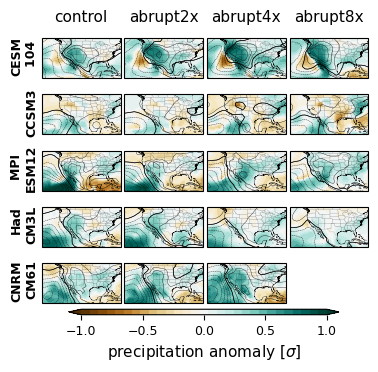

In [54]:
lon = slp_map['CESM104']['control'].lon
lat = slp_map['CESM104']['control'].lat

fig, axes = plt.subplots(len(all_models), 4,
                         figsize=(4.5, 3.65),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod == 'HadCM3L':
        title = 'Had\nCM3L'
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
    for col, exp in enumerate(exps):
        ax = axes[row, col]

        f = ax.contourf(lon, lat,  mean_circ_pr_mhw[mod][exp]/pr_std[mod][exp], 
                        levels = np.linspace(-1,1, 30), 
                        cmap = 'BrBG',
                        norm = colors.TwoSlopeNorm(vcenter=0.),
                        transform=ccrs.PlateCarree(),
                        extend = 'both'
                       )
        levels = np.arange(-1.,1,.2)
        f2 = ax.contour(lon, lat, mean_circ_slp_mhw[mod][exp]/slp_std[mod][exp], levels=levels,
                                  colors='black', linewidths=0.25, transform=ccrs.PlateCarree())
        # clabels = f2.clabel(fontsize = 5)
        f2 = ax.contour(lon, lat, mean_circ_slp_mhw[mod][exp]/slp_std[mod][exp], levels=[0],
                                  colors='black', linewidths=0.5, transform=ccrs.PlateCarree())


        # Add coastlines and features
        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([220,290,16,46])

        # ax.plot([241.2,241.2], [31.25, 41.25], color='k', linewidth=.5,
        # transform=ccrs.Geodetic())

        # ax.plot([253.8,253.8], [31.25, 41.25], color='k', linewidth=.5,
        #         transform=ccrs.Geodetic())
        
        # ax.plot([241.2,253.8], [31.25, 31.25], color='k', linewidth=.5,
        #         transform=ccrs.Geodetic())
        
        # ax.plot([241.2 ,253.8], [41.25, 41.25], color='k', linewidth=.5,
        #         transform=ccrs.Geodetic())

        
        # Titles and labels
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)

        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.2)
        
    # Delete unused columns if model has < 4 experiments
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Colorbar
# cbar_ax = fig.add_axes([0.99, 0.35, 0.015, 0.3])
cbar_ax1 = fig.add_axes([0.185, 0.1, 0.6, 0.015])  
cb = fig.colorbar(f, cax=cbar_ax1, ticks = np.arange(-1,1.5,0.5), orientation = 'horizontal')
cb.ax.tick_params(labelsize=9)
cb.set_label('precipitation anomaly [$\sigma$]', size=11)
# Super labels
# fig.suptitle("Pr MHW detrended", fontsize=9, x=0.54, y = 0.95)
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/mhw_circ_sigma.jpg', dpi = 300,bbox_inches="tight")

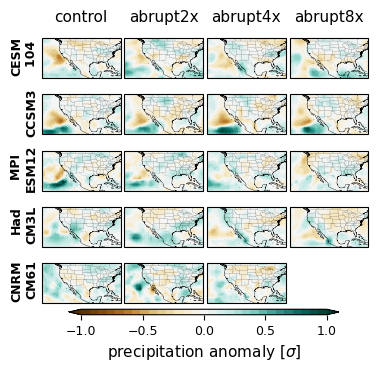

In [55]:
lon = slp_map['CESM104']['control'].lon
lat = slp_map['CESM104']['control'].lat

fig, axes = plt.subplots(len(all_models), 4,
                         figsize=(4.5, 3.65),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod == 'HadCM3L':
        title = 'Had\nCM3L'
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
    for col, exp in enumerate(exps):
        ax = axes[row, col]

        f = ax.contourf(lon, lat,  mean_pr_resid_mhw[mod][exp]/pr_std[mod][exp], 
                        levels = np.linspace(-1,1, 30), 
                        cmap = 'BrBG',
                        norm = colors.TwoSlopeNorm(vcenter=0.),
                        transform=ccrs.PlateCarree(),
                        extend = 'both'
               )
        # levels = np.arange(-1.,1,.2)
        # f2 = ax.contour(lon, lat, mean_circ_slp_mhw[mod][exp]/slp_std[mod][exp], levels=levels,
        #                           colors='black', linewidths=0.25, transform=ccrs.PlateCarree())
        # # clabels = f2.clabel(fontsize = 5)
        # f2 = ax.contour(lon, lat, mean_circ_slp_mhw[mod][exp]/slp_std[mod][exp], levels=[0],
        #                           colors='black', linewidths=0.5, transform=ccrs.PlateCarree())


        # Add coastlines and features
        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([220,290,16,46])

        # ax.plot([241.2,241.2], [31.25, 41.25], color='k', linewidth=.5,
        # transform=ccrs.Geodetic())

        # ax.plot([253.8,253.8], [31.25, 41.25], color='k', linewidth=.5,
        #         transform=ccrs.Geodetic())
        
        # ax.plot([241.2,253.8], [31.25, 31.25], color='k', linewidth=.5,
        #         transform=ccrs.Geodetic())
        
        # ax.plot([241.2 ,253.8], [41.25, 41.25], color='k', linewidth=.5,
        #         transform=ccrs.Geodetic())

        
        # Titles and labels
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)

        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.2)
        
    # Delete unused columns if model has < 4 experiments
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Colorbar
# cbar_ax = fig.add_axes([0.99, 0.35, 0.015, 0.3])
cbar_ax1 = fig.add_axes([0.185, 0.1, 0.6, 0.015])  
cb = fig.colorbar(f, cax=cbar_ax1, ticks = np.arange(-1,1.5,0.5), orientation = 'horizontal')
cb.ax.tick_params(labelsize=9)
cb.set_label('precipitation anomaly [$\sigma$]', size=11)
# Super labels
# fig.suptitle("Pr MHW detrended", fontsize=9, x=0.54, y = 0.95)
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/mhw_resid_sigma.jpg', dpi = 300,bbox_inches="tight")

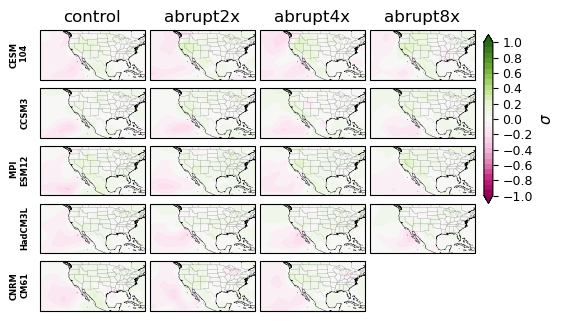

In [56]:
lon = slp_map['CESM104']['control'].lon
lat = slp_map['CESM104']['control'].lat

fig, axes = plt.subplots(len(all_models), 4,
                         figsize=(6,3.75),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.000001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
    for col, exp in enumerate(exps):
        ax = axes[row, col]


        f = ax.contourf(lon, lat,  mean_slp_resid_mhw[mod][exp]/slp_std[mod][exp], 
                        levels = np.linspace(-1,1, 30), 
                        cmap = 'PiYG',
                        norm = colors.TwoSlopeNorm(vcenter=0.),
                        transform=ccrs.PlateCarree(),
                        extend = 'both'
                       )

        # Add coastlines and features

        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([215,290,16,45])

        
        # Titles and labels
        if col == 0:
            ax.text(-0.1, 0.5, title, fontsize=6, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        
        if row == 0:
            ax.set_title(exp, fontsize = 12)

    # Delete unused columns if model has < 4 experiments
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Colorbar
# cbar_ax = fig.add_axes([0.99, 0.35, 0.015, 0.3])
cbar_ax1 = fig.add_axes([0.865, 0.408, 0.015, 0.45])  
cb = fig.colorbar(f, cax=cbar_ax1, label="hPa", ticks = np.arange(-1,1.2,0.2)
            )
cb.ax.tick_params(labelsize=9)
cb.set_label('$\sigma$', size=11)
# Super labels
# fig.suptitle("Pr MHW detrended", fontsize=9, x=0.54, y = 0.95)
# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_pre_review/mhw_slp_sigma_resid.jpg', dpi = 300,bbox_inches="tight")

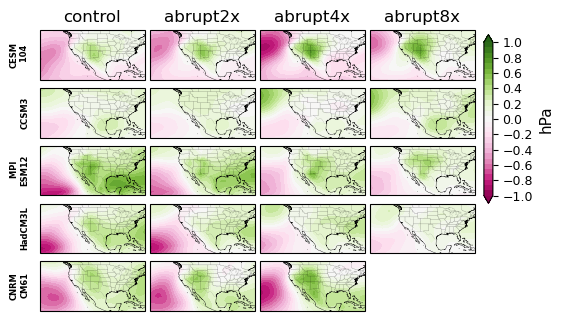

In [57]:
lon = slp_map['CESM104']['control'].lon
lat = slp_map['CESM104']['control'].lat

fig, axes = plt.subplots(len(all_models), 4,
                         figsize=(6,3.75),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.000001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
    for col, exp in enumerate(exps):
        ax = axes[row, col]


        f = ax.contourf(lon, lat,  mean_circ_slp_mhw[mod][exp], 
                        levels = np.linspace(-1,1, 30), 
                        cmap = 'PiYG',
                        norm = colors.TwoSlopeNorm(vcenter=0.),
                        transform=ccrs.PlateCarree(),
                        extend = 'both'
                       )

        # Add coastlines and features

        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([215,290,16,45])

        
        # Titles and labels
        if col == 0:
            ax.text(-0.1, 0.5, title, fontsize=6, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        
        if row == 0:
            ax.set_title(exp, fontsize = 12)

    # Delete unused columns if model has < 4 experiments
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Colorbar
# cbar_ax = fig.add_axes([0.99, 0.35, 0.015, 0.3])
cbar_ax1 = fig.add_axes([0.865, 0.408, 0.015, 0.45])  
cb = fig.colorbar(f, cax=cbar_ax1, label="hPa", ticks = np.arange(-1,1.2,0.2)
            )
cb.ax.tick_params(labelsize=9)
cb.set_label('hPa', size=11)
# Super labels
# fig.suptitle("Pr MHW detrended", fontsize=9, x=0.54, y = 0.95)
# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_pre_review/mhw_slp_sigma_circ.jpg', dpi = 300,bbox_inches="tight")

In [58]:
# Getting the decomposition values for the SWUS only, in mm/day
mhw_contributions = {}

for mod in all_models:
    mhw_contributions[mod] = {}
    exps = model_experiments[mod]
    for exp in exps:
        
        mhw_comp = get_sw(mean_pr_mhw[mod][exp])

        circ_comp = xr.DataArray(mean_circ_pr_mhw[mod][exp] ,dims=[ "lat", "lon"],coords={"lat": lat, "lon":lon})
        circ_comp = get_sw(circ_comp)

        thermo_comp = xr.DataArray(mean_pr_resid_mhw[mod][exp],dims=[ "lat", "lon"],coords={"lat": lat, "lon":lon})
        thermo_comp = get_sw(thermo_comp)
    
        mhw_contributions[mod][exp] = {
            'Total': mhw_comp,
            'Circulation': circ_comp,
            'Residual': thermo_comp
        }

In [59]:
# Making dictionary for MPIESM12 maps only, in mm/day

mpi_data_pr_mhw = {}
mpi_data_slp_mhw = {}
mpi_data_tas_mhw = {}
mod = 'MPIESM12'
exps = model_experiments[mod]
for exp in exps:

    mpi_data_pr_mhw[exp] = {
        'Total': mean_pr_mhw[mod][exp],
        'Circulation':  mean_circ_pr_mhw[mod][exp],
        'Residual': mean_pr_resid_mhw[mod][exp]
    }

    mpi_data_slp_mhw[exp] = {
        'Total': mean_slp_mhw[mod][exp],
        'Circulation':  mean_circ_slp_mhw[mod][exp],
        'Residual': mean_slp_resid_mhw[mod][exp]
    }

    mpi_data_tas_mhw[exp] = {
        'Total': mean_tas_mhw[mod][exp],
        'Circulation':  mean_circ_tas_mhw[mod][exp],
        'Residual': mean_tas_resid_mhw[mod][exp]
    }

In [60]:
mhw_contributions['CNRMCM61'][ 'abrupt8x'] = {
            'Total': 0,
            'Circulation': 0,
            'Residual': 0
}

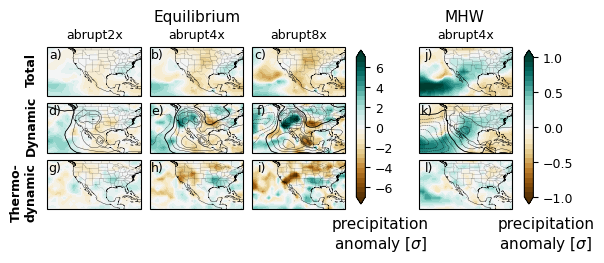

In [63]:
import matplotlib.gridspec as gridspec
comp = ['Total', 'Circulation', 'Residual']
titles = ['Total', 'Dynamic', 'Thermo-\ndynamic']
mod = 'MPIESM12'
exps = model_experiments[mod][1:]   # same set of experiments

# --- Create figure with 7 columns (4 for eq, 3 for mhw) ---
fig = plt.figure(figsize=(6,2.2))
gs = gridspec.GridSpec(3, 5, width_ratios=[1,1,1,0.6,1], wspace=0.1, hspace=0.01, figure=fig)
# ------------------------------------------------------
# Left block: Equilibrium (3×4)
# ------------------------------------------------------
axes_eq = np.empty((3,3), dtype=object)
for row in range(3):
    for col in range(3):
        axes_eq[row,col] = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
        ax = axes_eq[row,col]
        exp = exps[col]  # pick experiment
        to_plot = mpi_data_pr_eq[exp][comp[row]]/control_pr_std[mod]
        
        f_eq = ax.contourf(lon, lat, to_plot,
                           levels=np.linspace(-7,7,30),
                           cmap='BrBG',
                           norm=colors.TwoSlopeNorm(vcenter=0.),
                           transform=ccrs.PlateCarree(),
                           extend='both')
        
        if row == 1:
            levels = np.arange(-6,7,1)
            c_eq = ax.contour(lon, lat, (mpi_data_slp_eq[exp][comp[row]]/control_slp_std[mod]),
                              levels=levels, colors='black', linewidths=0.25,
                              transform=ccrs.PlateCarree())
            # ax.clabel(c_eq, fmt='%d', fontsize=5, inline=True, inline_spacing=2)

            ax.contour(lon, lat, (mpi_data_slp_eq[exp][comp[row]]/control_slp_std[mod]),
                               levels=[0], colors='black', linewidths=0.5,
                               transform=ccrs.PlateCarree())

        # ax.coastlines()
        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha=0.25)
        # ax.add_feature(cart.feature.OCEAN, zorder=100, edgecolor='k', color = 'white')
        ax.set_extent([215,290,12,45])
        ax.text(0.15, 0.84, letters[row*3 + col], fontsize=9,va='center', ha='right', transform=ax.transAxes)  
        
        # if col == 0 and row !=2:
        #     ax.text(-0.1, 0.5, titles[row], fontsize=9, fontweight='bold',
        #             va='center', ha='right', rotation=90, transform=ax.transAxes)
        if col == 0 and row == 2:
            ax.text(-0.1, 0.35, titles[row], fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)

        if col == 0 and row == 1:
            ax.text(-0.1, 0.55, titles[row], fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
            
        if col == 0 and row == 0:
            ax.text(-0.1, 0.55, titles[row], fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        if row == 0:
            ax.set_title(exp, fontsize = 9, y = 1.)

# Equilibrium colorbar
cbar_ax_eq = fig.add_axes([0.64, 0.15, 0.015, 0.7])
cb = fig.colorbar(f_eq, cax=cbar_ax_eq, ticks=np.arange(-6,8,2))
fig.text(0.68, -0.05, "precipitation\nanomaly [$\sigma$]", fontsize=11, ha="center")
cb.ax.tick_params(labelsize=9)
fig.text(0.375, 0.98, 'Equilibrium',fontsize=11, ha="center")


mod = 'MPIESM12'
exps = model_experiments[mod]

# ------------------------------------------------------
# Right block: MHW (3×3)
# ------------------------------------------------------
axes_mhw = np.empty((3,1), dtype=object)
exp = 'abrupt4x'
for row in range(3):
    for col in range(1):
        axes_mhw[row, col] = fig.add_subplot(gs[row, 4], projection=ccrs.PlateCarree())
        ax = axes_mhw[row,col]  
        to_plot = mpi_data_pr_mhw[exp][comp[row]]/pr_std[mod][exp]
        
        f_mhw = ax.contourf(lon, lat, to_plot,
                            levels=np.linspace(-1,1,30),
                            cmap='BrBG',
                            norm=colors.TwoSlopeNorm(vcenter=0.),
                            transform=ccrs.PlateCarree(),
                            extend='both')
        
        ax.text(0.15, 0.84, letters[row+9 + col], fontsize=9,va='center', ha='right', transform=ax.transAxes)

        
        if row == 1:
            levels = np.arange(-1.,1.2,.2)
            c_mhw = ax.contour(lon, lat, (mpi_data_slp_mhw[exp][comp[row]]/slp_std[mod][exp]),
                               levels=levels, colors='black', linewidths=0.25,
                               transform=ccrs.PlateCarree())
            # ax.clabel(c_mhw, levels = levels[::2],fmt='%d', fontsize=5, inline=True, inline_spacing=2)
            ax.contour(lon, lat, (mpi_data_slp_mhw[exp][comp[row]]/slp_std[mod][exp]),
                               levels=[0], colors='black', linewidths=0.5,
                               transform=ccrs.PlateCarree())
        # ax.plot([241.2,241.2], [31.25, 41.25], color='pink', linewidth=0.75,
        # transform=ccrs.Geodetic())
        
        # ax.plot([253.8,253.8], [31.25, 41.25], color='pink', linewidth=0.75,
        #         transform=ccrs.Geodetic())
        
        # ax.plot([241.2,253.8], [31.25, 31.25], color='pink', linewidth=0.75,
        #         transform=ccrs.Geodetic())
        
        # ax.plot([241.2 ,253.8], [41.25, 41.25], color='pink', linewidth=0.75,
        #         transform=ccrs.Geodetic())        
        # ax.coastlines()
        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha=0.25)
        ax.set_extent([215,290,12,45])
        
        
        if row == 0:
            ax.set_title(exp, fontsize = 9, y = 1.)

# MHW colorbar
cbar_ax_mhw = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cb = fig.colorbar(f_mhw, cax=cbar_ax_mhw, ticks=np.arange(-1,1.5,0.5))
cb.ax.tick_params(labelsize=9)
fig.text(0.82, 0.98, "MHW", fontsize=11, ha="center")
fig.text(0.956, -0.05, "precipitation\nanomaly [$\sigma$]", fontsize=11, ha="center")

# fig.text(0.07, 0.9, "a)", fontsize=16, ha="center")
# fig.text(0.69, 0.9, "b)", fontsize=16, ha="center")

# ------------------------------------------------------
# plt.suptitle("Equilibrium vs. MHW ", fontsize=14, fontweight='bold')
# fig.tight_layout(rect=[0, 0, 0.92, 1])
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/mpi_sigma.jpg', dpi = 300,bbox_inches="tight")

In [64]:
# Now that I have the SWUS decompisiton values in mm/day, I want to convert back to standardized anomalies (sigma)
eq_cont_stand = {}
# eq_cont_stand_tas = {}
for mod in all_models:
    exps = model_experiments[mod]
    # Get control precipitation
    control_pr = data['pr_mon_map_nonanom_all'][mod]['control'][:1000]
    control_tas = data['tas_mon_map_nonanom_all'][mod]['control'][:1000]
    # Get SWUS box average of precipitation
    sw_pr = get_sw_ts(control_pr)
    ca_tas = get_ca_ts(control_tas)
    # Get equilibrium std of SW box
    control_std_sw = sw_pr[200:].std(axis = 0)
    control_std_ca = ca_tas[200:].std(axis = 0)

    eq_cont_stand[mod] = {}
    # eq_cont_stand_tas[mod] = {}
    for exp in exps:
        
        # eq_contributions are in mm/day anomaly. Divide by equilibrium control standard deviation to get standardized anomalies
        eq_cont_stand[mod][exp] = {
            'Total': eq_contributions[mod][exp]['Total']/control_std_sw,
            'Circulation': eq_contributions[mod][exp]['Circulation']/control_std_sw,
            'Residual': eq_contributions[mod][exp]['Residual']/control_std_sw,
        }


mhw_cont_stand = {}
# mhw_cont_stand_tas = {}
for mod in all_models:
    
    exps = model_experiments[mod]
    mhw_cont_stand[mod] = {}
    # mhw_cont_stand_tas[mod] = {}
    
    for exp in exps:
        
        exp_pr = data['sw_detrend_dict_mon_map'][mod][exp][:800]
        exp_tas = data['tas_detrend_dict_mon_map'][mod][exp][:800]
        # Get SWUS box average
        sw_pr = get_sw_ts(exp_pr)
        ca_tas = get_ca_ts(exp_tas)
        # Get standard deviation of model and experiment precipitation in SWUS box
        exp_std_sw = sw_pr.std(axis = 0)
        exp_std_ca = ca_tas.std(axis = 0)
        
        # eq_contributions is in mm/day anomaly. Divice by model and experiment standard deviation to get standardized anomalies
        mhw_cont_stand[mod][exp] = {
            'Total': mhw_contributions[mod][exp]['Total']/exp_std_sw,
            'Circulation': mhw_contributions[mod][exp]['Circulation']/exp_std_sw,
            'Residual': mhw_contributions[mod][exp]['Residual']/exp_std_sw,
        }


eq_cont_stand['CNRMCM61'][ 'abrupt8x'] = {
            'Total': 0,
            'Circulation': 0,
            'Residual': 0
}


mhw_cont_stand['CNRMCM61'][ 'abrupt8x'] = {
            'Total': 0,
            'Circulation': 0,
            'Residual': 0
}

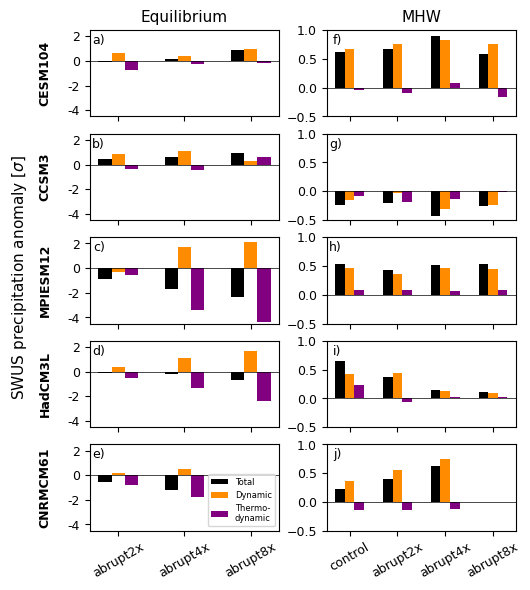

In [65]:
components = ['Total', 'Circulation', 'Residual']
titles = ['Total', 'Dynamic', 'Thermo-\ndynamic']
color_comp = ['black', 'darkorange', 'purple']
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(5.5, 6.5), sharex=False, sharey=False,gridspec_kw={'wspace': 0.25})
count = 0
letters = ['a)', 'b)', 'c)', 'd)', 'e)','f)','g)', 'h)', 'i)', 'j)']
for i, mod in enumerate(all_models):
    # exps = model_experiments[mod]
    # if mod == 'MPIESM12':
    #     mod_title = "MPI  \nESM12"
    # elif mod == 'CNRMCM61':
    #     mod_title = "CNRM\nCM61"
    # elif mod =='CESM104':
    #     mod_title = 'CESM\n104 '
    # else:
    mod_title = mod
    exps = ['control', 'abrupt2x', 'abrupt4x', 'abrupt8x']
    for j, kind in enumerate([eq_cont_stand, mhw_cont_stand]):

        title = 'Equilibrium' if j == 0 else 'MHW'
        ax = axs[i, j]
        bar_data = [ [kind[mod][exp][comp] for comp in components] for exp in exps ]
        bar_data = np.array(bar_data)
        if j == 0:
            bar_data = bar_data[1:,:]
            x = np.arange(len(exps)-1)
            xicks = exps[1:]
        else:
            x = np.arange(len(exps))
            
        width = 0.2
        
        for k in range(len(components)):
            ax.bar(x + width * k, bar_data[:,k], width=width, label=titles[k], color = color_comp[k])

        ax.axhline(0, color='black', linewidth=0.5)

        # set title
        if i == 0:
            ax.set_title(f"{title}", fontsize = 11, y = 1.0)
            
        # set y lims
        if j ==0: 
            ax.set_ylim([-4.5,2.5])
            ax.text(-0.2, 0.5, mod_title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes) 
            ax.set_yticks([-4,-2,0,2])  
            ax.set_yticklabels([-4,-2,0,2])      

        if j == 1:
            ax.set_ylim([-0.5, 1.])
            # ax.set_yticks([-0.5, 0, 0.5])
            # ax.set_yticklabels([-0.5, 0, 0.5])

        # blanks for x ticks
        
        if j == 0 and i != 4:
            # ax.set_ylabel("standard deviations", fontsize = 16)
            ax.set_xticks(x + width)
            ax.set_xticklabels([' ', ' ', ' '], rotation = 30)
            

        if j == 1 and i!=4:
            ax.set_xticks(x + width)
            ax.set_xticklabels([' ', ' ', ' ', ' '])      

        # adding xticks and legend

        if i == 4 and j == 1:
            # ax.legend(loc='lower right', fontsize = 6)
            ax.set_xticks(x + width)
            ax.set_xticklabels(exps, rotation = 30)

        if i ==4 and j == 0:
            ax.legend(loc='lower right', fontsize = 6)

        if i == 4 and j == 0:
            ax.set_xticks(x + width)
            ax.set_xticklabels(xicks, rotation = 30)

        # Add legend
        # if i == 0 and j == 0:
            # ax.legend(loc='lower right', fontsize = 16)

        ax.tick_params(labelsize=9)
        label_index = i + (5 * j)
        ax.text(0.08, 0.88, letters[label_index], fontsize=9, 
                    va='center', ha='right', transform=ax.transAxes)
        count +=1
        

# fig.text(0.07, 0.9, "(a)", fontsize=16, ha="center")
# fig.text(0.5, 0.9, "(b)", fontsize=16, ha="center")
fig.supylabel("SWUS precipitation anomaly [$\sigma$]", fontsize=11, x = -0.02)
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/cont_sigma_notsym.jpg', dpi = 300,bbox_inches="tight")

0.0
0.6371288171295643
0.4043884267871612
0.9800868510795997
0.0
0.8841949441647768
1.0621662844667707
0.3240938518540244
0.0
-0.3169121762863135
1.7151353792798572
2.0798428960458644
0.0
0.4137262346477389
1.1248381754777084
1.649294635405636
0.0
0.21052909027227473
0.5352691715883828


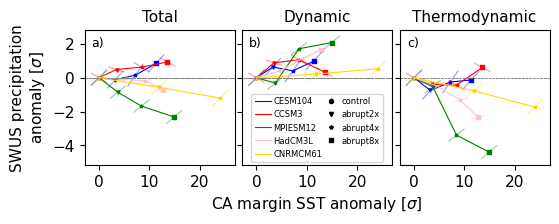

In [66]:
marg_mon_nonanom = data['marg_dict_mon']
pr_mon_nonanom = data['sw_dict_mon']

marg_mon = data['marg_detrend_dict_mon']
# Detrended SWUS precip dictionary
pr_mon = data['sw_detrend_dict_mon']

fig, ax = plt.subplots(1,3, figsize = (6,1.75), sharey = True, sharex = True,gridspec_kw={'wspace': 0.05})
shapes = ['o', 'v', '*', 's', 'd']
plt.sca(ax[0])
for i, mod in enumerate(all_models):
    exps = model_experiments[mod]
    sw_eq_mean = []
    marg_eq_mean = []
    
    for j,exp in enumerate(exps):

        margin = marg_mon_nonanom[mod][exp][:1000]
        marg_cont = marg_mon_nonanom[mod]['control'][:1000]
        marg_cont = marg_cont[-200:]
        marg_exp = margin[-200:].mean()

        z_sw = eq_cont_stand[mod][exp]['Total']
        # print(z_sw)
        z_ca = (marg_exp - marg_cont.mean(axis = 0))/ marg_cont.std(axis = 0)
        #z_sw = get_sw(z_sw)
        
        sw_eq_mean.append(z_sw)
        marg_eq_mean.append(z_ca)

        plt.scatter(z_ca, z_sw, color = model_colors[mod], marker = shapes[j], s = 5)


        marg_raw = marg_mon[mod][exp][:800]
        p1 = np.percentile(marg_raw, 10)
        mcw_ind = np.where(marg_raw < p1)[0]
        p2 = np.percentile(marg_raw, 90)
        mhw_ind = np.where(marg_raw > p2)[0]

        x_z = (marg_raw-np.mean(marg_raw))/ np.std(marg_raw)
        y_z = (pr_mon[mod][exp][:800]-np.mean(pr_mon[mod][exp][:800]))/ np.std(pr_mon[mod][exp][:800])
        
        x_mhw = np.concatenate([x_z[mcw_ind], x_z[mhw_ind]])
        y_mhw = np.concatenate([y_z[mcw_ind], y_z[mhw_ind]])

        m,b, r, p, se = scipy.stats.linregress(x_mhw,y_mhw)
        # print(m)
        new_x = np.linspace(z_ca.values-1.5, z_ca.values+1.5, 100)
        new_y = z_sw + m * (new_x - z_ca.values)
        plt.plot(new_x, new_y, color=model_colors[mod], alpha=0.4, linewidth = 0.8)
        plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)
    plt.plot(marg_eq_mean, sw_eq_mean, color = model_colors[mod], label = mod, linewidth = 0.8) 
    plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)
    plt.title('Total', fontsize = 11)
    ax[0].tick_params(labelsize=11)




plt.sca(ax[1])
for i, mod in enumerate(all_models):
    exps = model_experiments[mod]
    sw_eq_mean = []
    marg_eq_mean = []

    for j,exp in enumerate(exps):

        margin = marg_mon_nonanom[mod][exp][:1000]
        marg_cont = marg_mon_nonanom[mod]['control'][:1000]
        marg_cont = marg_cont[-200:]
        marg_exp = margin[-200:].mean()

        z_sw = eq_cont_stand[mod][exp]['Circulation']
        print(z_sw)
        z_ca = (marg_exp - marg_cont.mean(axis = 0))/ marg_cont.std(axis = 0)
        # print(z_ca.values)
        #z_sw = get_sw(z_sw)
        
        sw_eq_mean.append(z_sw)
        marg_eq_mean.append(z_ca)

        plt.scatter(z_ca, z_sw, color = model_colors[mod], marker = shapes[j], s = 5)

        

        marg_raw = marg_mon[mod][exp][:800]
        p1 = np.percentile(marg_raw, 10)
        mcw_ind = np.where(marg_raw < p1)[0]
        p2 = np.percentile(marg_raw, 90)
        mhw_ind = np.where(marg_raw > p2)[0]

        x_z = (marg_raw-np.mean(marg_raw))/ np.std(marg_raw)
        y_z = (pr_mon[mod][exp][:800]-np.mean(pr_mon[mod][exp][:800]))/ np.std(pr_mon[mod][exp][:800])
        
        x_mhw = np.concatenate([x_z[mcw_ind], x_z[mhw_ind]])
        y_mhw = np.concatenate([y_z[mcw_ind], y_z[mhw_ind]])

        m,b, r, p, se = scipy.stats.linregress(x_mhw,y_mhw)
        # print(m)
        new_x = np.linspace(z_ca.values-1.5, z_ca.values+1.5, 100)
        new_y = z_sw + m * (new_x - z_ca.values)
        plt.plot(new_x, new_y, color=model_colors[mod], alpha=0.4, linewidth = 0.8)
        plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)
    plt.plot(marg_eq_mean, sw_eq_mean, color = model_colors[mod], label = mod, linewidth = 0.8) 
    plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)
    ax[1].tick_params(labelsize=11)
    plt.title('Dynamic', fontsize = 11)



plt.sca(ax[2])
for i, mod in enumerate(all_models):
    exps = model_experiments[mod]
    sw_eq_mean = []
    marg_eq_mean = []


    for j,exp in enumerate(exps):


        margin = marg_mon_nonanom[mod][exp][:1000]
        marg_cont = marg_mon_nonanom[mod]['control'][:1000]
        marg_cont = marg_cont[-200:]
        marg_exp = margin[-200:].mean()

        z_sw = eq_cont_stand[mod][exp]['Residual']
        z_ca = (marg_exp - marg_cont.mean(axis = 0))/ marg_cont.std(axis = 0)
        #z_sw = get_sw(z_sw)
        
        sw_eq_mean.append(z_sw)
        marg_eq_mean.append(z_ca)

        plt.scatter(z_ca, z_sw, color = model_colors[mod], marker = shapes[j], s = 5)
        marg_raw = marg_mon[mod][exp][:800]
        p1 = np.percentile(marg_raw, 10)
        mcw_ind = np.where(marg_raw < p1)[0]
        p2 = np.percentile(marg_raw, 90)
        mhw_ind = np.where(marg_raw > p2)[0]

        x_z = (marg_raw-np.mean(marg_raw))/ np.std(marg_raw)
        y_z = (pr_mon[mod][exp][:800]-np.mean(pr_mon[mod][exp][:800]))/ np.std(pr_mon[mod][exp][:800])
        
        x_mhw = np.concatenate([x_z[mcw_ind], x_z[mhw_ind]])
        y_mhw = np.concatenate([y_z[mcw_ind], y_z[mhw_ind]])

        m,b, r, p, se = scipy.stats.linregress(x_mhw,y_mhw)
        # print(m)
        new_x = np.linspace(z_ca.values-1.5, z_ca.values+1.5, 100)
        new_y = z_sw + m * (new_x - z_ca.values)
        plt.plot(new_x, new_y, color=model_colors[mod], alpha=0.4, linewidth = 0.8)



    
    plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)
    plt.plot(marg_eq_mean, sw_eq_mean, color = model_colors[mod], label = mod, linewidth = 0.8) 
    

        

    
    ax[2].tick_params(labelsize=11)
    plt.title('Thermodynamic', fontsize = 11)
# plt.legend(loc = 'upper right', fontsize = 16)
ax[0].set_ylabel("SWUS precipitation\nanomaly [$\sigma$]", fontsize = 11)

ax[1].set_xlabel("CA margin SST anomaly [$\sigma$]", fontsize = 11)

from matplotlib.lines import Line2D

# Model handles (just lines, no markers)
model_handles = [
    Line2D([0], [0], color=color, linestyle='-', linewidth=0.8, label=mod)
    for mod, color in model_colors.items()
]

# Experiment handles (black markers only)
shapes = ['o', 'v', '*', 's', 'd']
exp_handles = [
    Line2D([0], [0], marker=shapes[j], color='k', linestyle='None',
           label=exp, markersize=3)
    for j, exp in enumerate(model_experiments[all_models[0]])
]

# Dummy headers
header_models = Line2D([], [], linestyle='None', label=" ")
header_exps   = Line2D([], [], linestyle='None', label=" ")

# Combine both (no headers)
handles = model_handles + exp_handles
labels = [h.get_label() for h in handles]

# Place legend in the second subplot
leg = ax[1].legend(handles, labels,
                   loc="lower center", bbox_to_anchor=(.5, -0.01),
                   fontsize=6, ncol=2, frameon=True,columnspacing=0.1, handletextpad=0.2,)

# Make headers bold
for text in leg.get_texts():
    if text.get_text() in ["Models", "Experiments"]:
        text.set_fontweight("bold")

ax[0].text(0.13, 0.9, 'a)', fontsize=9,
        va='center', ha='right', transform=ax[0].transAxes)
ax[1].text(0.13, 0.9, 'b)', fontsize=9,
        va='center', ha='right', transform=ax[1].transAxes)
ax[2].text(0.13, 0.9, 'c)', fontsize=9,
        va='center', ha='right', transform=ax[2].transAxes)
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/fig4_sigma.jpg', dpi = 300,bbox_inches="tight")

In [68]:
# Get the model mean decomposition values for each experiment

marg_mon_nonanom = data['marg_dict_mon']
pr_mon_nonanom = data['sw_dict_mon']

avg_decomp = np.zeros([4])
exps = model_experiments['CESM104']
for j, exp in enumerate(exps):

    all_mods = []
    for i, mod in enumerate(all_models):
        if exp == 'abrupt8x' and mod == 'CNRMCM61':
            continue
        else:
            all_mods.append(eq_cont_stand[mod][exp]['Circulation'])
    # Take mean across models for each experiment
    avg_decomp[j] =  np.mean(all_mods) 

# Get model mean CA margin equilibrium SST
avg_ca_marg = np.zeros([4])
for j, exp in enumerate(exps):

    all_mods = []
    for i, mod in enumerate(all_models):
        if exp == 'abrupt8x' and mod == 'CNRMCM61':
            continue
        else: 
            margin = marg_mon_nonanom[mod][exp][:1000]
            marg_cont = marg_mon_nonanom[mod]['control'][:1000]
            marg_cont = marg_cont[-200:]
            marg_exp = margin[-200:].mean()

            z_ca = (marg_exp - marg_cont.mean(axis = 0))/ marg_cont.std(axis = 0)
            all_mods.append(z_ca)

    avg_ca_marg[j] = np.mean(all_mods)

for i in range(4):
    print(avg_decomp[i]/avg_ca_marg[i])

np.polyfit(avg_ca_marg, avg_decomp, 1)

nan
0.06755705222705408
0.08464881523685566
0.09571915279685599


array([ 0.09404428, -0.05721435])

In [69]:
# Get the model mean decomposition values for each experiment

marg_mon_nonanom = data['marg_dict_mon']
pr_mon_nonanom = data['sw_dict_mon']

avg_decomp = np.zeros([4])
exps = model_experiments['CESM104']
for j, exp in enumerate(exps):

    all_mods = []
    for i, mod in enumerate(all_models):
        if exp == 'abrupt8x' and mod == 'CNRMCM61':
            continue
        else:
            all_mods.append(eq_cont_stand[mod][exp]['Residual'])
    # Take mean across models for each experiment
    avg_decomp[j] =  np.mean(all_mods) 

# Get model mean CA margin equilibrium SST
avg_ca_marg = np.zeros([4])
for j, exp in enumerate(exps):

    all_mods = []
    for i, mod in enumerate(all_models):
        if exp == 'abrupt8x' and mod == 'CNRMCM61':
            continue
        else: 
            margin = marg_mon_nonanom[mod][exp][:1000]
            marg_cont = marg_mon_nonanom[mod]['control'][:1000]
            marg_cont = marg_cont[-200:]
            marg_exp = margin[-200:].mean()

            z_ca = (marg_exp - marg_cont.mean(axis = 0))/ marg_cont.std(axis = 0)
            all_mods.append(z_ca)

    avg_ca_marg[j] = np.mean(all_mods)

for i in range(4):
    print(avg_decomp[i]/avg_ca_marg[i])

np.polyfit(avg_ca_marg, avg_decomp, 1)

nan
-0.10977566864349497
-0.12487903424612529
-0.11929949840917305


array([-0.12262384,  0.02186483])

In [70]:
# Get the model mean decomposition values for each experiment

marg_mon_nonanom = data['marg_dict_mon']
pr_mon_nonanom = data['sw_dict_mon']

avg_decomp = np.zeros([4])
exps = model_experiments['CESM104']
for j, exp in enumerate(exps):

    all_mods = []
    for i, mod in enumerate(all_models):
        if exp == 'abrupt8x' and mod == 'CNRMCM61':
            continue
        else:
            all_mods.append(eq_cont_stand[mod][exp]['Total'])
    # Take mean across models for each experiment
    avg_decomp[j] =  np.mean(all_mods) 

# Get model mean CA margin equilibrium SST
avg_ca_marg = np.zeros([4])
for j, exp in enumerate(exps):

    all_mods = []
    for i, mod in enumerate(all_models):
        if exp == 'abrupt8x' and mod == 'CNRMCM61':
            continue
        else: 
            margin = marg_mon_nonanom[mod][exp][:1000]
            marg_cont = marg_mon_nonanom[mod]['control'][:1000]
            marg_cont = marg_cont[-200:]
            marg_exp = margin[-200:].mean()

            z_ca = (marg_exp - marg_cont.mean(axis = 0))/ marg_cont.std(axis = 0)
            all_mods.append(z_ca)

    avg_ca_marg[j] = np.mean(all_mods)

for i in range(4):
    print(avg_decomp[i]/avg_ca_marg[i])

np.polyfit(avg_ca_marg, avg_decomp, 1)

nan
-0.04221862249033287
-0.04023022444955422
-0.023580349892648147


array([-0.02857957, -0.03534952])

0.0
0.6371288171295643
0.4043884267871612
0.9800868510795997
0.0
0.8841949441647768
1.0621662844667707
0.3240938518540244
0.0
-0.3169121762863135
1.7151353792798572
2.0798428960458644
0.0
0.4137262346477389
1.1248381754777084
1.649294635405636
0.0
0.21052909027227473
0.5352691715883828


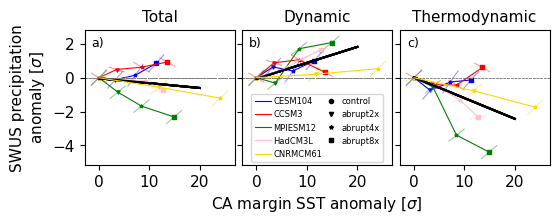

In [71]:
marg_mon_nonanom = data['marg_dict_mon']
pr_mon_nonanom = data['sw_dict_mon']

marg_mon = data['marg_detrend_dict_mon']
# Detrended SWUS precip dictionary
pr_mon = data['sw_detrend_dict_mon']

fig, ax = plt.subplots(1,3, figsize = (6,1.75), sharey = True, sharex = True,gridspec_kw={'wspace': 0.05})
shapes = ['o', 'v', '*', 's', 'd']
plt.sca(ax[0])
for i, mod in enumerate(all_models):
    exps = model_experiments[mod]
    sw_eq_mean = []
    marg_eq_mean = []
    
    for j,exp in enumerate(exps):

        margin = marg_mon_nonanom[mod][exp][:1000]
        marg_cont = marg_mon_nonanom[mod]['control'][:1000]
        marg_cont = marg_cont[-200:]
        marg_exp = margin[-200:].mean()

        z_sw = eq_cont_stand[mod][exp]['Total']
        # print(z_sw)
        z_ca = (marg_exp - marg_cont.mean(axis = 0))/ marg_cont.std(axis = 0)
        #z_sw = get_sw(z_sw)
        
        sw_eq_mean.append(z_sw)
        marg_eq_mean.append(z_ca)

        plt.scatter(z_ca, z_sw, color = model_colors[mod], marker = shapes[j], s = 5)


        marg_raw = marg_mon[mod][exp][:800]
        p1 = np.percentile(marg_raw, 10)
        mcw_ind = np.where(marg_raw < p1)[0]
        p2 = np.percentile(marg_raw, 90)
        mhw_ind = np.where(marg_raw > p2)[0]

        x_z = (marg_raw-np.mean(marg_raw))/ np.std(marg_raw)
        y_z = (pr_mon[mod][exp][:800]-np.mean(pr_mon[mod][exp][:800]))/ np.std(pr_mon[mod][exp][:800])
        
        x_mhw = np.concatenate([x_z[mcw_ind], x_z[mhw_ind]])
        y_mhw = np.concatenate([y_z[mcw_ind], y_z[mhw_ind]])

        m,b, r, p, se = scipy.stats.linregress(x_mhw,y_mhw)
        # print(m)
        new_x = np.linspace(z_ca.values-1.5, z_ca.values+1.5, 100)
        new_y = z_sw + m * (new_x - z_ca.values)
        plt.plot(new_x, new_y, color=model_colors[mod], alpha=0.4, linewidth = 0.8)
        plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)

    eq_x = np.linspace(0,20,100)
    eq_mean = (eq_x * -0.02857957) - 0.03534952
    plt.plot(eq_x, eq_mean, color = 'k')
    plt.plot(marg_eq_mean, sw_eq_mean, color = model_colors[mod], label = mod, linewidth = 0.8) 
    plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)
    plt.title('Total', fontsize = 11)
    ax[0].tick_params(labelsize=11)




plt.sca(ax[1])
for i, mod in enumerate(all_models):
    exps = model_experiments[mod]
    sw_eq_mean = []
    marg_eq_mean = []

    for j,exp in enumerate(exps):

        margin = marg_mon_nonanom[mod][exp][:1000]
        marg_cont = marg_mon_nonanom[mod]['control'][:1000]
        marg_cont = marg_cont[-200:]
        marg_exp = margin[-200:].mean()

        z_sw = eq_cont_stand[mod][exp]['Circulation']
        print(z_sw)
        z_ca = (marg_exp - marg_cont.mean(axis = 0))/ marg_cont.std(axis = 0)
        # print(z_ca.values)
        #z_sw = get_sw(z_sw)
        
        sw_eq_mean.append(z_sw)
        marg_eq_mean.append(z_ca)

        plt.scatter(z_ca, z_sw, color = model_colors[mod], marker = shapes[j], s = 5)

        

        marg_raw = marg_mon[mod][exp][:800]
        p1 = np.percentile(marg_raw, 10)
        mcw_ind = np.where(marg_raw < p1)[0]
        p2 = np.percentile(marg_raw, 90)
        mhw_ind = np.where(marg_raw > p2)[0]

        x_z = (marg_raw-np.mean(marg_raw))/ np.std(marg_raw)
        y_z = (pr_mon[mod][exp][:800]-np.mean(pr_mon[mod][exp][:800]))/ np.std(pr_mon[mod][exp][:800])
        
        x_mhw = np.concatenate([x_z[mcw_ind], x_z[mhw_ind]])
        y_mhw = np.concatenate([y_z[mcw_ind], y_z[mhw_ind]])

        m,b, r, p, se = scipy.stats.linregress(x_mhw,y_mhw)
        # print(m)
        new_x = np.linspace(z_ca.values-1.5, z_ca.values+1.5, 100)
        new_y = z_sw + m * (new_x - z_ca.values)
        plt.plot(new_x, new_y, color=model_colors[mod], alpha=0.4, linewidth = 0.8)
        plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)
    eq_x = np.linspace(0,20,100)
    eq_mean = (eq_x * 0.09404429) - 0.05721436
    plt.plot(eq_x, eq_mean, color = 'k')
    plt.plot(marg_eq_mean, sw_eq_mean, color = model_colors[mod], label = mod, linewidth = 0.8) 
    plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)
    ax[1].tick_params(labelsize=11)
    plt.title('Dynamic', fontsize = 11)



plt.sca(ax[2])
for i, mod in enumerate(all_models):
    exps = model_experiments[mod]
    sw_eq_mean = []
    marg_eq_mean = []


    for j,exp in enumerate(exps):


        margin = marg_mon_nonanom[mod][exp][:1000]
        marg_cont = marg_mon_nonanom[mod]['control'][:1000]
        marg_cont = marg_cont[-200:]
        marg_exp = margin[-200:].mean()

        z_sw = eq_cont_stand[mod][exp]['Residual']
        z_ca = (marg_exp - marg_cont.mean(axis = 0))/ marg_cont.std(axis = 0)
        #z_sw = get_sw(z_sw)
        
        sw_eq_mean.append(z_sw)
        marg_eq_mean.append(z_ca)

        plt.scatter(z_ca, z_sw, color = model_colors[mod], marker = shapes[j], s = 5)
        marg_raw = marg_mon[mod][exp][:800]
        p1 = np.percentile(marg_raw, 10)
        mcw_ind = np.where(marg_raw < p1)[0]
        p2 = np.percentile(marg_raw, 90)
        mhw_ind = np.where(marg_raw > p2)[0]

        x_z = (marg_raw-np.mean(marg_raw))/ np.std(marg_raw)
        y_z = (pr_mon[mod][exp][:800]-np.mean(pr_mon[mod][exp][:800]))/ np.std(pr_mon[mod][exp][:800])
        
        x_mhw = np.concatenate([x_z[mcw_ind], x_z[mhw_ind]])
        y_mhw = np.concatenate([y_z[mcw_ind], y_z[mhw_ind]])

        m,b, r, p, se = scipy.stats.linregress(x_mhw,y_mhw)
        # print(m)
        new_x = np.linspace(z_ca.values-1.5, z_ca.values+1.5, 100)
        new_y = z_sw + m * (new_x - z_ca.values)
        plt.plot(new_x, new_y, color=model_colors[mod], alpha=0.4, linewidth = 0.8)



    eq_x = np.linspace(0,20,100)
    eq_mean = (eq_x * -0.12262386) +  0.02186484
    plt.plot(eq_x, eq_mean, color = 'k')    
    plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)
    plt.plot(marg_eq_mean, sw_eq_mean, color = model_colors[mod], label = mod, linewidth = 0.8) 
    

        

    
    ax[2].tick_params(labelsize=11)
    plt.title('Thermodynamic', fontsize = 11)
# plt.legend(loc = 'upper right', fontsize = 16)
ax[0].set_ylabel("SWUS precipitation\nanomaly [$\sigma$]", fontsize = 11)

ax[1].set_xlabel("CA margin SST anomaly [$\sigma$]", fontsize = 11)

from matplotlib.lines import Line2D

# Model handles (just lines, no markers)
model_handles = [
    Line2D([0], [0], color=color, linestyle='-', linewidth=0.8, label=mod)
    for mod, color in model_colors.items()
]

# Experiment handles (black markers only)
shapes = ['o', 'v', '*', 's', 'd']
exp_handles = [
    Line2D([0], [0], marker=shapes[j], color='k', linestyle='None',
           label=exp, markersize=3)
    for j, exp in enumerate(model_experiments[all_models[0]])
]

# Dummy headers
header_models = Line2D([], [], linestyle='None', label=" ")
header_exps   = Line2D([], [], linestyle='None', label=" ")

# Combine both (no headers)
handles = model_handles + exp_handles
labels = [h.get_label() for h in handles]

# Place legend in the second subplot
leg = ax[1].legend(handles, labels,
                   loc="lower center", bbox_to_anchor=(.5, -0.01),
                   fontsize=6, ncol=2, frameon=True,columnspacing=0.1, handletextpad=0.2,)

# Make headers bold
for text in leg.get_texts():
    if text.get_text() in ["Models", "Experiments"]:
        text.set_fontweight("bold")

ax[0].text(0.13, 0.9, 'a)', fontsize=9,
        va='center', ha='right', transform=ax[0].transAxes)
ax[1].text(0.13, 0.9, 'b)', fontsize=9,
        va='center', ha='right', transform=ax[1].transAxes)
ax[2].text(0.13, 0.9, 'c)', fontsize=9,
        va='center', ha='right', transform=ax[2].transAxes)

fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/fig4_sigma_wmean.jpg', dpi = 300,bbox_inches="tight")

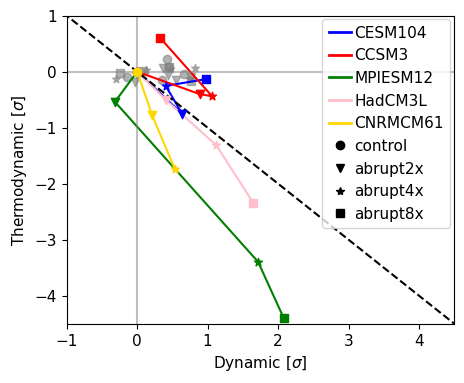

In [72]:
from matplotlib.lines import Line2D
shapes = ['o', 'v', '*', 's', 'd']

fig, ax = plt.subplots(1,1, figsize = (5,4))


for i, mod in enumerate(all_models):
    line_x= []
    line_y= []
    for j, exp in enumerate(model_experiments[mod]):
        plt.scatter(eq_cont_stand[mod][exp]['Circulation'], eq_cont_stand[mod][exp]['Residual'], color = model_colors[mod], marker = shapes[j] , label = exp, zorder  = 5)
        line_x.append(eq_cont_stand[mod][exp]['Circulation'])
        line_y.append(eq_cont_stand[mod][exp]['Residual'])

    plt.plot(line_x, line_y, color =  model_colors[mod])
plt.xlim([-1,4.5])
plt.ylim([-4.5,1])
plt.plot(np.linspace(-4.5,4.5,100), -np.linspace(-4.5,4.5,100), color = 'k', linestyle = '--')
plt.xlabel('Dynamic [$\sigma$]', fontsize = 11)
plt.ylabel('Thermodynamic [$\sigma$]', fontsize = 11)
plt.axhline(0, color = 'grey', alpha = 0.5)
plt.axvline(0, color = 'grey', alpha = 0.5)
# plt.legend()

for i, mod in enumerate(all_models):
    for j, exp in enumerate(model_experiments[mod]):
        plt.scatter(mhw_cont_stand[mod][exp]['Circulation'], mhw_cont_stand[mod][exp]['Residual'], color = 'gray', marker = shapes[j] , alpha = 0.6)


# plt.annotate('Residual faster', xy=(3,-2.6),xytext=(2.3,-2.6),
#              arrowprops=dict(facecolor='black', shrink=.08, width = 0.5, headlength = 10, headwidth=7),
#              horizontalalignment = 'right',color = 'black')



    # Model handles
    model_handles = [
        Line2D([0], [0], color=color, linestyle='-', linewidth=2, label=mod)
        for mod, color in model_colors.items()
    ]
    
    # Experiment handles
    exp_handles = [
        Line2D([0], [0], marker=shapes[j], color='k', linestyle='None',
               label=exp, markersize=6)
        for j, exp in enumerate(model_experiments[all_models[0]])
    ]
    # Dummy headers
    header_models = Line2D([], [], linestyle='None', label=" ")
    header_exps   = Line2D([], [], linestyle='None', label=" ")
    
    # Combine both (no headers)
    handles = model_handles + exp_handles
    labels = [h.get_label() for h in handles]
    
    # Place legend in the second subplot
    leg = ax.legend(handles, labels,
                    bbox_to_anchor=(0.64, 0.65), loc="center left",
                    fontsize=11, handlelength=1.5, handletextpad=0.2,)

# Make the headers bold
for text in leg.get_texts():
    if text.get_text() in ["Models", "Experiments"]:
        text.set_fontweight("bold")

ax.tick_params(labelsize=11)
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/dynvsthermo_sigma.jpg', dpi = 300,bbox_inches="tight")

0.0
0.1693993580139654
0.10751850758511904
0.26058479739274876
0.0
0.17070642313832327
0.20506632404710673
0.06257093213907108
0.0
-0.06958298338209695
0.3765845704238052
0.45666176491025073
0.0
0.13131445916630932
0.35701752733867326
0.5234771577185612
0.0
0.05764125347612133
0.14655259946623161


Text(0.5, 0, 'CA margin SST anomaly [$\\sigma$]')

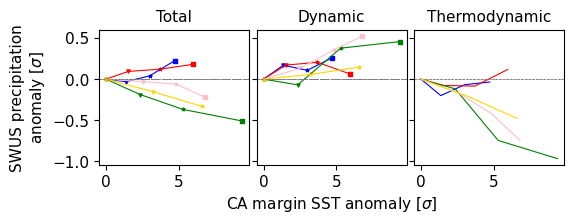

In [19]:
marg_mon_nonanom = data['marg_dict_mon']
pr_mon_nonanom = data['sw_dict_mon']

marg_mon = data['marg_detrend_dict_mon']
# Detrended SWUS precip dictionary
pr_mon = data['sw_detrend_dict_mon']

fig, ax = plt.subplots(1,3, figsize = (6,1.75), sharey = True, sharex = True,gridspec_kw={'wspace': 0.05})
shapes = ['o', 'v', '*', 's', 'd']
plt.sca(ax[0])
for i, mod in enumerate(all_models):
    exps = model_experiments[mod]
    sw_eq_mean = []
    marg_eq_mean = []
    
    for j,exp in enumerate(exps):

        margin = marg_mon_nonanom[mod][exp][:1000]
        marg_cont = marg_mon_nonanom[mod]['control'][:1000]
        marg_cont = marg_cont[-200:]
        marg_exp = margin[-200:].mean()

        z_sw = eq_contributions[mod][exp]['Total']
        # print(z_sw)
        z_ca = (marg_exp - marg_cont.mean(axis = 0))
        #z_sw = get_sw(z_sw)
        
        sw_eq_mean.append(z_sw)
        marg_eq_mean.append(z_ca)

        plt.scatter(z_ca, z_sw, color = model_colors[mod], marker = shapes[j], s = 5)


       
        plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)
    plt.plot(marg_eq_mean, sw_eq_mean, color = model_colors[mod], label = mod, linewidth = 0.8) 
    plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)
    plt.title('Total', fontsize = 11)
    ax[0].tick_params(labelsize=11)




plt.sca(ax[1])
for i, mod in enumerate(all_models):
    exps = model_experiments[mod]
    sw_eq_mean = []
    marg_eq_mean = []

    for j,exp in enumerate(exps):

        margin = marg_mon_nonanom[mod][exp][:1000]
        marg_cont = marg_mon_nonanom[mod]['control'][:1000]
        marg_cont = marg_cont[-200:]
        marg_exp = margin[-200:].mean()

        z_sw = eq_contributions[mod][exp]['Circulation']
        print(z_sw)
        z_ca = (marg_exp - marg_cont.mean(axis = 0))
        # print(z_ca.values)
        #z_sw = get_sw(z_sw)
        
        sw_eq_mean.append(z_sw)
        marg_eq_mean.append(z_ca)

        plt.scatter(z_ca, z_sw, color = model_colors[mod], marker = shapes[j], s = 5)

        

        
        plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)
    plt.plot(marg_eq_mean, sw_eq_mean, color = model_colors[mod], label = mod, linewidth = 0.8) 
    plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)
    ax[1].tick_params(labelsize=11)
    plt.title('Dynamic', fontsize = 11)



plt.sca(ax[2])
for i, mod in enumerate(all_models):
    exps = model_experiments[mod]
    sw_eq_mean = []
    marg_eq_mean = []


    for j,exp in enumerate(exps):


        margin = marg_mon_nonanom[mod][exp][:1000]
        marg_cont = marg_mon_nonanom[mod]['control'][:1000]
        marg_cont = marg_cont[-200:]
        marg_exp = margin[-200:].mean()

        z_sw = eq_contributions[mod][exp]['Residual']
        z_ca = (marg_exp - marg_cont.mean(axis = 0))
        #z_sw = get_sw(z_sw)
        
        sw_eq_mean.append(z_sw)
        marg_eq_mean.append(z_ca)


    
    plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)
    plt.plot(marg_eq_mean, sw_eq_mean, color = model_colors[mod], label = mod, linewidth = 0.8) 
    

        

    
    ax[2].tick_params(labelsize=11)
    plt.title('Thermodynamic', fontsize = 11)
# plt.legend(loc = 'upper right', fontsize = 16)
ax[0].set_ylabel("SWUS precipitation\nanomaly [$\sigma$]", fontsize = 11)

ax[1].set_xlabel("CA margin SST anomaly [$\sigma$]", fontsize = 11)


In [26]:
eq_contributions['MPIESM12']

{'control': {'Total': array(0.),
  'Circulation': array(0.),
  'Residual': array(0.)},
 'abrupt2x': {'Total': array(-0.18757982),
  'Circulation': array(-0.06958298),
  'Residual': array(-0.11799683)},
 'abrupt4x': {'Total': array(-0.36872072),
  'Circulation': array(0.37658457),
  'Residual': array(-0.74530529)},
 'abrupt8x': {'Total': array(-0.50968473),
  'Circulation': array(0.45666176),
  'Residual': array(-0.9663465)}}

In [22]:
mean_pr_resid_eq['CESM104']['abrupt8x'][0,:5]

<xarray.DataArray (lon: 5)>
array([-1.3171518 , -0.15491958, -0.44206607, -1.15863278, -1.33104309])
Coordinates:
    lat      float64 -8.75
  * lon      (lon) float64 181.2 183.8 186.2 188.8 191.2

In [24]:
data['pr_mon_map_nonanom_all']['CESM104']['abrupt4x']

<xarray.DataArray (time: 1000, lat: 25, lon: 45)>
array([[[13.24032846, 13.62843401, 13.9205285 , ...,  1.32243   ,
          1.30514029,  1.59429562],
        [ 7.72223105,  7.09882963,  6.75674623, ...,  1.701386  ,
          2.02870741,  2.09213302],
        [ 0.9158299 ,  0.9258914 ,  0.88975842, ...,  2.56134261,
          2.812701  ,  2.56767735],
        ...,
        [ 2.37752774,  2.68598175,  2.99978492, ...,  2.49549436,
          2.39966734,  2.65721854],
        [ 2.44333004,  2.57534506,  2.9946018 , ...,  2.78161345,
          2.66610338,  2.5523554 ],
        [ 2.15064973,  2.39399402,  2.70873603, ...,  2.35894343,
          2.60395383,  2.73416011]],

       [[ 6.0709511 ,  5.71989081,  5.51813594, ...,  1.08522258,
          1.12824077,  1.29813255],
        [ 6.44180328,  6.13212417,  5.62807839, ...,  1.43286513,
          1.612629  ,  1.63309083],
        [ 1.87638508,  1.84707945,  1.76896042, ...,  2.09814987,
          2.54440869,  2.74641817],
...
        [ 2.68277985,  2.76611737,  2.88258744, ...,  3.85404552,
          4.03618865,  4.28223798],
        [ 3.0899361 ,  2.79955756,  2.77189583, ...,  3.3947918 ,
          3.59719938,  3.81051216],
        [ 3.54971897,  3.26293276,  3.13657664, ...,  3.11059249,
          3.38477089,  3.68364393]],

       [[ 6.44606818,  6.0968505 ,  5.62060052, ...,  0.32156214,
          0.28793527,  0.33390241],
        [ 6.83486575,  6.66973162,  6.34606284, ...,  0.66895025,
          0.60797308,  0.72516422],
        [ 4.15336134,  3.74685036,  3.45501918, ...,  2.23972765,
          1.83880437,  1.7422959 ],
        ...,
        [ 2.9246224 ,  3.20830601,  3.13949545, ...,  2.18030456,
          2.52627582,  3.18987464],
        [ 3.39210656,  3.65299035,  4.01668146, ...,  2.39655203,
          2.9062176 ,  3.45260575],
        [ 4.12366699,  4.12622331,  4.05740511, ...,  2.7279198 ,
          3.21289531,  3.58381409]]])
Coordinates:
  * time     (time) int64 420 421 422 423 424 425 ... 1415 1416 1417 1418 1419
  * lat      (lat) float64 -8.75 -6.25 -3.75 -1.25 ... 43.75 46.25 48.75 51.25
  * lon      (lon) float64 181.2 183.8 186.2 188.8 ... 283.8 286.2 288.8 291.2

# Observations

In [14]:
era5 = xr.open_dataset('/scratch/olee/research/Paleo_group/era5_data/era5_jjas_whole_domain.nc')
gpcp = xr.open_mfdataset('/scratch/olee/research/Paleo_group/era5_data/precip*.nc',  combine='by_coords',drop_variables='time_bnds',decode_times=True, use_cftime=True)

In [15]:
precip_jjas = gpcp.sel(time=gpcp['time.month'].isin([6, 7, 8, 9]))
sw_precip = precip_jjas.sel(lat=slice(31.25,41.25), lon = slice(241.25,253.75)).precip

precip_jjas_gpcp = sw_precip.groupby('time.year').mean()
weights = np.cos(np.deg2rad(precip_jjas_gpcp.lat))
sw_weighted = precip_jjas_gpcp.weighted(weights)
sw_jjas_gpcp_box = sw_weighted.mean(("lon", "lat")).values

In [16]:
era5.valid_time

<xarray.DataArray 'valid_time' (valid_time: 188)>
array(['1979-06-01T00:00:00.000000000', '1979-07-01T00:00:00.000000000',
       '1979-08-01T00:00:00.000000000', '1979-09-01T00:00:00.000000000',
       '1980-06-01T00:00:00.000000000', '1980-07-01T00:00:00.000000000',
       '1980-08-01T00:00:00.000000000', '1980-09-01T00:00:00.000000000',
       '1981-06-01T00:00:00.000000000', '1981-07-01T00:00:00.000000000',
       '1981-08-01T00:00:00.000000000', '1981-09-01T00:00:00.000000000',
       '1982-06-01T00:00:00.000000000', '1982-07-01T00:00:00.000000000',
       '1982-08-01T00:00:00.000000000', '1982-09-01T00:00:00.000000000',
       '1983-06-01T00:00:00.000000000', '1983-07-01T00:00:00.000000000',
       '1983-08-01T00:00:00.000000000', '1983-09-01T00:00:00.000000000',
       '1984-06-01T00:00:00.000000000', '1984-07-01T00:00:00.000000000',
       '1984-08-01T00:00:00.000000000', '1984-09-01T00:00:00.000000000',
       '1985-06-01T00:00:00.000000000', '1985-07-01T00:00:00.000000000',
       '1985-08-01T00:00:00.000000000', '1985-09-01T00:00:00.000000000',
       '1986-06-01T00:00:00.000000000', '1986-07-01T00:00:00.000000000',
       '1986-08-01T00:00:00.000000000', '1986-09-01T00:00:00.000000000',
       '1987-06-01T00:00:00.000000000', '1987-07-01T00:00:00.000000000',
       '1987-08-01T00:00:00.000000000', '1987-09-01T00:00:00.000000000',
       '1988-06-01T00:00:00.000000000', '1988-07-01T00:00:00.000000000',
       '1988-08-01T00:00:00.000000000', '1988-09-01T00:00:00.000000000',
       '1989-06-01T00:00:00.000000000', '1989-07-01T00:00:00.000000000',
       '1989-08-01T00:00:00.000000000', '1989-09-01T00:00:00.000000000',
       '1990-06-01T00:00:00.000000000', '1990-07-01T00:00:00.000000000',
       '1990-08-01T00:00:00.000000000', '1990-09-01T00:00:00.000000000',
       '1991-06-01T00:00:00.000000000', '1991-07-01T00:00:00.000000000',
       '1991-08-01T00:00:00.000000000', '1991-09-01T00:00:00.000000000',
       '1992-06-01T00:00:00.000000000', '1992-07-01T00:00:00.000000000',
       '1992-08-01T00:00:00.000000000', '1992-09-01T00:00:00.000000000',
       '1993-06-01T00:00:00.000000000', '1993-07-01T00:00:00.000000000',
       '1993-08-01T00:00:00.000000000', '1993-09-01T00:00:00.000000000',
       '1994-06-01T00:00:00.000000000', '1994-07-01T00:00:00.000000000',
       '1994-08-01T00:00:00.000000000', '1994-09-01T00:00:00.000000000',
       '1995-06-01T00:00:00.000000000', '1995-07-01T00:00:00.000000000',
       '1995-08-01T00:00:00.000000000', '1995-09-01T00:00:00.000000000',
       '1996-06-01T00:00:00.000000000', '1996-07-01T00:00:00.000000000',
       '1996-08-01T00:00:00.000000000', '1996-09-01T00:00:00.000000000',
       '1997-06-01T00:00:00.000000000', '1997-07-01T00:00:00.000000000',
       '1997-08-01T00:00:00.000000000', '1997-09-01T00:00:00.000000000',
       '1998-06-01T00:00:00.000000000', '1998-07-01T00:00:00.000000000',
       '1998-08-01T00:00:00.000000000', '1998-09-01T00:00:00.000000000',
       '1999-06-01T00:00:00.000000000', '1999-07-01T00:00:00.000000000',
       '1999-08-01T00:00:00.000000000', '1999-09-01T00:00:00.000000000',
       '2000-06-01T00:00:00.000000000', '2000-07-01T00:00:00.000000000',
       '2000-08-01T00:00:00.000000000', '2000-09-01T00:00:00.000000000',
       '2001-06-01T00:00:00.000000000', '2001-07-01T00:00:00.000000000',
       '2001-08-01T00:00:00.000000000', '2001-09-01T00:00:00.000000000',
       '2002-06-01T00:00:00.000000000', '2002-07-01T00:00:00.000000000',
       '2002-08-01T00:00:00.000000000', '2002-09-01T00:00:00.000000000',
       '2003-06-01T00:00:00.000000000', '2003-07-01T00:00:00.000000000',
       '2003-08-01T00:00:00.000000000', '2003-09-01T00:00:00.000000000',
       '2004-06-01T00:00:00.000000000', '2004-07-01T00:00:00.000000000',
       '2004-08-01T00:00:00.000000000', '2004-09-01T00:00:00.000000000',
       '2005-06-01T00:00:00.000000000', '2005-07-01T00:00:00.000000000',
       '2005-08-01T00:00:00.000000000', '2005-09-01T00:00:00.000000000',
       '

In [17]:
grid_out = xr.Dataset({
    "lat": gpcp["lat"],
    "lon": gpcp["lon"]
})

import xesmf as xe

regridder = xe.Regridder(
    era5,
    grid_out,
    method="bilinear",   # best for precipitation
    periodic=False,
)

era5_regrid = regridder(era5)

In [18]:
era5_t2m = era5_regrid.t2m
era5_sst = era5_regrid.sst
era5_slp = era5_regrid.msl/100

t2m_jjas = era5_t2m.groupby('valid_time.year').mean()

In [19]:
latMin, latMax = data['pr_mon_map_nonanom_all']['CESM104']['control'][:1000].lat[0], data['pr_mon_map_nonanom_all']['CESM104']['control'][:1000].lat[-1]
lonMin, lonMax = data['pr_mon_map_nonanom_all']['CESM104']['control'][:1000].lon[0], data['pr_mon_map_nonanom_all']['CESM104']['control'][:1000].lon[-1]

pr_obs = precip_jjas.precip.groupby('time.year').mean().sel(year=slice(1979,2014), lat=slice(latMin,latMax), lon=slice(lonMin,lonMax))
tas_obs = era5_t2m.groupby('valid_time.year').mean().sel(year=slice(1979,2014),lat=slice(latMin,latMax), lon=slice(lonMin,lonMax))
slp_obs = era5_slp.groupby('valid_time.year').mean().sel(year=slice(1979,2014),lat=slice(latMin,latMax), lon=slice(lonMin,lonMax))

## Comparing gradient

In [40]:
def to_monthly(ds):
    year = ds.time.dt.year
    month = ds.time.dt.month

    # assign new coords
    ds = ds.assign_coords(year=("time", year.data), month=("time", month.data))

    # reshape the array to (..., "month", "year")
    return ds.set_index(time=("year", "month")).unstack("time")  


def dsc_map(data,type, dim = None, deg = None):
    time_length = data.shape[0]
    monthly = to_monthly(data)

    if type == 'constant':
        
        detrend = scipy.signal.detrend(monthly, axis = 2, type = 'constant')
        detrend_shaped = np.transpose(detrend, (3,2,0,1))


    if type == 'linear':

        detrend = scipy.signal.detrend(monthly, axis = 2, type = 'linear')
        detrend_shaped = np.transpose(detrend, (3,2,0,1))
        

    if type == 'nonlinear':
                
        fit = monthly.polyfit(dim, deg)
        trend_lines = xr.polyval(monthly[dim], fit['polyfit_coefficients'])
        detrended = monthly - trend_lines
        detrend_shaped = np.transpose(np.asarray(detrended), (3,2,0,1))

    
    deseasonalized = np.zeros(np.shape(data))
    for imonth in range(12):
        t = np.arange(imonth, time_length,12)
        deseasonalized[t,:,:] = (detrend_shaped[imonth,:,:,:])

    return deseasonalized


def dsc(data,type,dim = None, deg = None):

    monthly = to_monthly(data)
    time_length = len(data)
    
    if type == 'constant':
        detrend = scipy.signal.detrend(monthly, axis = 0, type = 'constant')

    if type == 'linear':
        detrend = scipy.signal.detrend(monthly, axis = 0, type = 'linear')       

    if type == 'nonlinear':

        fit = monthly.polyfit(dim, deg)
        trend_lines = xr.polyval(monthly[dim], fit['polyfit_coefficients'])
        detrend = monthly - trend_lines
        
    
    return deseasonalized

def get_margin_obs(ts_var):
    seasonal = ts_var.sel(lat = slice(18.75,33.75), lon = slice(233.75, 248.75))
    annual = seasonal.groupby('valid_time.year').mean()[:]
    
    topo  = xr.open_dataset('/scratch/olee/research/Paleo_group/model_data/topo.nc')
    land_mask = np.where(topo.topo > 0, np.nan, 1)
    land_mask_xr = xr.DataArray(land_mask,dims=['lat', 'lon'],coords={'lat': topo.lat, 'lon':topo.lon})

    lat_ca = seasonal.lat
    lon_ca = seasonal.lon
    # print(lat_ca)
    # print(lon_ca)
    
    topo_box = land_mask_xr.sel(lat=slice(lat_ca.values[0],lat_ca.values[-1]), lon=slice(lon_ca.values[0],lon_ca.values[-1]))
    
    seasonal = seasonal*topo_box
    annual = annual*topo_box
    
    # area weighting the ca margin
    
    ann_ca_c_w = weighted(annual)
    sea_ca_c_w = weighted(seasonal)

    return ann_ca_c_w, sea_ca_c_w

In [41]:
# Get ca margin
# Regridded is on same grid as models, use models topo
topo  = xr.open_dataset('/scratch/olee/research/Paleo_group/model_data/topo.nc')
land_mask = np.where(topo.topo > 0, np.nan, 1)
land_mask_xr = xr.DataArray(land_mask,dims=['lat', 'lon'],coords={'lat': topo.lat, 'lon':topo.lon})

camarg_era5 = era5_t2m.sel(lat = slice(18.75,33.75), lon = slice(233.75, 248.75))
lat_ca = camarg_era5.lat
lon_ca = camarg_era5.lon
topo_box = land_mask_xr.sel(lat=slice(lat_ca.values[0],lat_ca.values[-1]), lon=slice(lon_ca.values[0],lon_ca.values[-1]))

ca_marg_noland = camarg_era5*topo_box

# Weighted average
weights = np.cos(np.deg2rad(ca_marg_noland.lat))
cam_weighted = ca_marg_noland.weighted(weights)
ca_marg_mean = cam_weighted.mean(("lon", "lat")).values

In [42]:
ca_marg_mean = xr.DataArray(ca_marg_mean,dims=['time'],coords={'time': camarg_era5.valid_time.values})

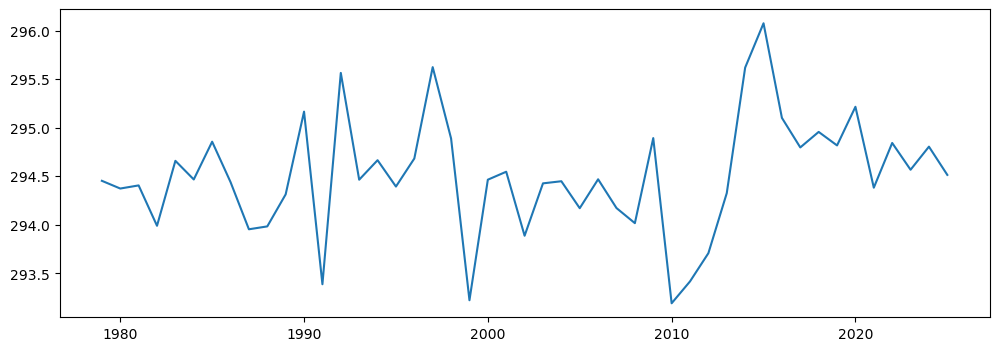

In [50]:
plt.figure(figsize = (12,4))
plt.plot(ca_marg_mean.groupby('time.year').mean().year, ca_marg_mean.groupby('time.year').mean())

In [43]:
year = ca_marg_mean.time.dt.year
month = ca_marg_mean.time.dt.month

# assign new coords
ds = ca_marg_mean.assign_coords(year=("time", year.data), month=("time", month.data))

monthly_camarg = ds.set_index(time=("year", "month")).unstack("time")  

In [51]:
detrended = scipy.signal.detrend(monthly_camarg, axis = 0, type = 'linear')    

In [52]:
cam_jjas_detrend = detrended.mean(axis = -1)
cam_jjas_detrend = xr.DataArray(cam_jjas_detrend,dims=['time'],coords={'time': np.unique(year)})

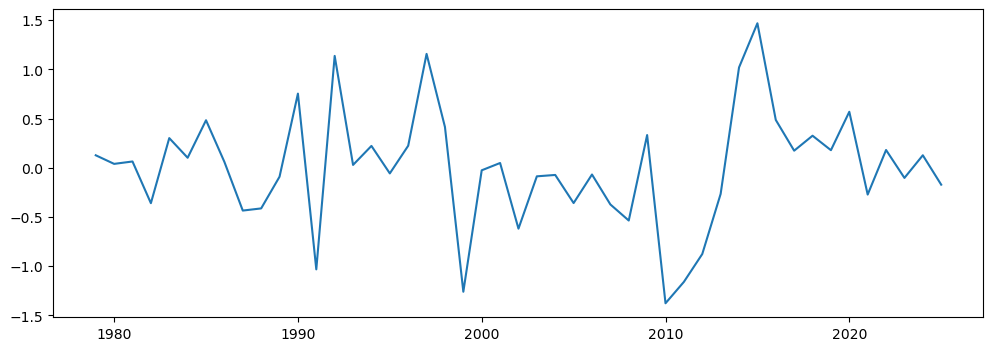

In [57]:
plt.figure(figsize = (12,4))
plt.plot(cam_jjas_detrend.time, cam_jjas_detrend)

In [84]:
# Get ca margin
# Regridded is on same grid as models, use models topo

eep_era5 = era5_t2m.sel(lat = slice(-5,5), lon = slice(190, 270))
lat_ca = camarg_era5.lat
lon_ca = camarg_era5.lon
# Weighted average
weights = np.cos(np.deg2rad(eep_era5.lat))
eeq_weighted = eep_era5.weighted(weights)
eep_mean = eeq_weighted.mean(("lon", "lat")).values

eep_mean = xr.DataArray(eep_mean,dims=['time'],coords={'time': eep_era5.valid_time.values})

year = eep_mean.time.dt.year
month = eep_mean.time.dt.month

# assign new coords
ds = eep_mean.assign_coords(year=("time", year.data), month=("time", month.data))

monthly_eep = ds.set_index(time=("year", "month")).unstack("time")  

In [85]:
detrended = scipy.signal.detrend(monthly_eep, axis = 0, type = 'linear')    
eep_jjas_detrend = detrended.mean(axis = -1)
eep_jjas_detrend = xr.DataArray(eep_jjas_detrend,dims=['time'],coords={'time': np.unique(year)})


In [58]:
precip_jjas = gpcp.sel(time=gpcp['time.month'].isin([6, 7, 8, 9]))
sw_precip = precip_jjas.sel(lat=slice(31.25,41.25), lon = slice(241.25,253.75)).precip

In [59]:
weights = np.cos(np.deg2rad(sw_precip.lat))
swus_weighted = sw_precip.weighted(weights)
swus_mean = swus_weighted.mean(("lon", "lat")).values

In [60]:
swus_mean = xr.DataArray(swus_mean,dims=['time'],coords={'time': sw_precip.time})

In [61]:
year = swus_mean.time.dt.year
month = swus_mean.time.dt.month

# assign new coords
ds = swus_mean.assign_coords(year=("time", year.data), month=("time", month.data))

monthly_swus = ds.set_index(time=("year", "month")).unstack("time")  

detrended = scipy.signal.detrend(monthly_swus, axis = 0, type = 'linear')    

swus_jjas_detrend = detrended.mean(axis = -1)
swus_jjas_detrend = xr.DataArray(swus_jjas_detrend,dims=['time'],coords={'time': np.unique(year)})

In [62]:
year = era5_t2m.valid_time.dt.year
month =era5_t2m.valid_time.dt.month

# assign new coords
ds = era5_t2m.assign_coords(year=("valid_time", year.data), month=("valid_time", month.data))

# reshape the array to (..., "month", "year")
monthly_t2m_map = ds.set_index(valid_time=("year", "month")).unstack("valid_time")  
detrend = scipy.signal.detrend(monthly_t2m_map, axis = 2, type = 'linear')
detrend_shaped = np.transpose(detrend, (3,2,0,1))

In [63]:
era5_t2m_detrend_map = detrend_shaped.mean(axis = 0)

In [64]:
era5_t2m_detrend_map = xr.DataArray(era5_t2m_detrend_map,dims=["time", 'lat', 'lon'],coords={"time": np.unique(year), 'lat': era5_t2m.lat, 'lon':era5_t2m.lon})

In [65]:
year = precip_jjas.time.dt.year
month =precip_jjas.time.dt.month

# assign new coords
ds = precip_jjas.assign_coords(year=("time", year.data), month=("time", month.data))

# reshape the array to (..., "month", "year")
monthly_precip_map = ds.set_index(time=("year", "month")).unstack("time")  

In [66]:
detrend = scipy.signal.detrend(monthly_precip_map.precip, axis = 2, type = 'linear')
detrend_shaped = np.transpose(detrend, (3,2,0,1))

gpcp_precip_detrend_map = detrend_shaped.mean(axis = 0)
gpcp_precip_detrend_map = xr.DataArray(gpcp_precip_detrend_map,dims=["time", 'lat', 'lon'],coords={"time": np.unique(year), 'lat': precip_jjas.lat, 'lon':precip_jjas.lon})

In [67]:

year = era5_slp.valid_time.dt.year
month =era5_slp.valid_time.dt.month

# assign new coords
ds = era5_slp.assign_coords(year=("valid_time", year.data), month=("valid_time", month.data))

# reshape the array to (..., "month", "year")
monthly_slp_map = ds.set_index(valid_time=("year", "month")).unstack("valid_time")  

In [68]:
detrend = scipy.signal.detrend(monthly_slp_map, axis = 2, type = 'linear')
detrend_shaped = np.transpose(detrend, (3,2,0,1))
era5_slp_detrend_map = detrend_shaped.mean(axis = 0)
era5_slp_detrend_map = xr.DataArray(era5_slp_detrend_map,dims=["time", 'lat', 'lon'],coords={"time": np.unique(year), 'lat': era5_slp.lat, 'lon':era5_slp.lon})

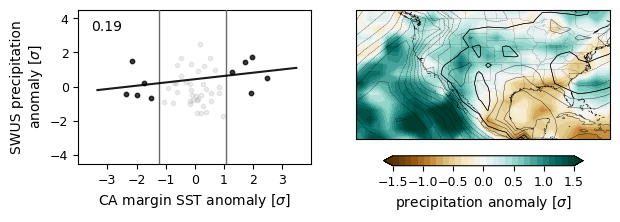

In [108]:
p90, inds, N, z, mean_pr = MHW(cam_jjas_detrend,swus_jjas_detrend, type = 'heat')

fig = plt.figure( figsize = (3,2.)
                        )


######### Now scatter plot




margin = (cam_jjas_detrend-np.mean(cam_jjas_detrend))/ np.std(cam_jjas_detrend)
southwest = (swus_jjas_detrend-np.mean(swus_jjas_detrend))/ np.std(swus_jjas_detrend)

p1 = np.percentile(cam_jjas_detrend, 10)
mcw_ind = np.where(cam_jjas_detrend < p1)[0]
p2 = np.percentile(cam_jjas_detrend, 90)
mhw_ind = np.where(cam_jjas_detrend > p2)[0]

p1_std = (p1 - cam_jjas_detrend.mean())/cam_jjas_detrend.std()
p2_std = (p2 - cam_jjas_detrend.mean())/cam_jjas_detrend.std()

# Concatenate precip during extreme SSTs
x_mhw = np.concatenate([margin[mcw_ind], margin[mhw_ind]])
y_mhw = np.concatenate([southwest[mcw_ind], southwest[mhw_ind]])

n = len(mhw_ind)
m,b, r, p, se = scipy.stats.linregress(x_mhw,y_mhw)

x_fit = np.linspace(x_mhw.min()-1, x_mhw.max()+1, 1000)
# Plot fit
plt.scatter(margin, southwest, color='gray', alpha=0.15, s = 10)

plt.scatter(x_mhw, y_mhw, color='k', alpha=0.75, s = 10, zorder = 10)
plt.plot(x_fit, x_fit * m + b, color='k', alpha = 0.9,
        label = f"m = {m:.2f}\np = {p:.1e} ", zorder = 15)

# plt.scatter(margin[35], southwest[35], color='red', s = 40, marker= '*', zorder = 10)
plt.xlabel('CA margin SST anomaly [$\sigma$]')
plt.ylabel('SWUS precipitation\nanomaly [$\sigma$]')
plt.text(-2.5,3.5, f"{m:.2f}", fontsize = 10,va='center', ha='right')
# plt.legend()


plt.axvline(p1_std, color = 'dimgrey', linewidth = 1, zorder = 12)
plt.axvline(p2_std, color = 'dimgrey', linewidth = 1, zorder = 12)

plt.yticks(np.arange(-4,6,2))
plt.tick_params(labelsize=9)
plt.ylim([-4.5,4.5])
plt.xlim([-4,4])
plt.xticks(np.arange(-3,4,1))
plt.tick_params(labelsize=9)



ax_map = fig.add_axes([1., 0.02, .95, 0.86], projection=crs)


mhw_pr = gpcp_precip_detrend_map[inds,:,:]
plot = (mhw_pr.mean(axis = 0) - gpcp_precip_detrend_map.mean(axis = 0)) / gpcp_precip_detrend_map.std(axis = 0)


# SLP composite mean during MHWs
mhw_slp = era5_slp_detrend_map[inds,:,:]
slp_contours = (mhw_slp.mean(axis = 0) - era5_slp_detrend_map.mean(axis = 0)) / era5_slp_detrend_map.std(axis = 0)

# Plot pr mean
f = ax_map.contourf(gpcp_precip_detrend_map.lon, gpcp_precip_detrend_map.lat, plot, 
                levels = np.linspace(-1.5,1.5, 30), 
                cmap = 'BrBG',
                norm = colors.TwoSlopeNorm(vcenter=0.),
                transform=ccrs.PlateCarree(),
                extend = 'both'
               )

# Plot SLP mean
levels = np.arange(-2,3,.2)
ax_map.contour(gpcp_precip_detrend_map.lon, gpcp_precip_detrend_map.lat, slp_contours, levels=levels,
                          colors='black', linewidths=0.25, transform=ccrs.PlateCarree())

ax_map.contour(gpcp_precip_detrend_map.lon, gpcp_precip_detrend_map.lat, slp_contours, levels=[0],
                          colors='black', linewidths=0.5, transform=ccrs.PlateCarree())



ax_map.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
ax_map.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
ax_map.set_extent([220,290,16,46])

# ax.set_title('Observed MHW composite (n=5)')
cbar = fig.colorbar(f, ax=ax_map,orientation = 'horizontal', use_gridspec = True,shrink = .7, pad = 0.1,label = 'precipitation anomaly [$\sigma$]',ticks = np.arange(-1.5,2,0.5)
                    #ticks = np.arange(0,7,1)
                   )
cbar.ax.tick_params(labelsize=9)


fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/obs_mhws.jpg', dpi = 300,bbox_inches="tight")

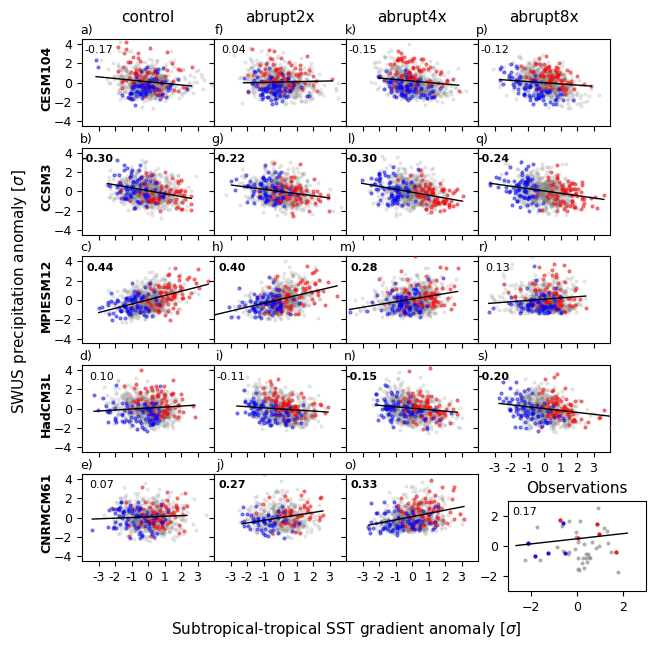

In [111]:
# Detrended CA margin SST dictionary
marg_mon = data['marg_detrend_dict_mon']
eep_mon = data['eep_detrend_dict_mon']
pr_mon =  data['sw_detrend_dict_mon']
# Detrended SWUS precip dictionary
pr_mon = data['sw_detrend_dict_mon']
letters = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)','g)', 'h)', 'i)', 'j)', 'k)', 'l)','m)', 'n)', 'o)', 'p)', 'q)', 'r)', 's)']

fig, axes = plt.subplots(len(all_models),4, figsize=(6,6), sharex=False, sharey=True,
                         gridspec_kw={'wspace': 0, 'hspace': 0.25})
fig.subplots_adjust(left=0.1, right=0.98, top=0.92, bottom=0.05, wspace=0, hspace=0.25)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    title = mod
    
    all_m = []
    for col,exp in enumerate(exps):
        
        scatter_color = colors_scatter[exp]
        fit_color = colors_fit[exp]

        margin_raw = marg_mon[mod][exp][:800]
        eep_raw = eep_mon[mod][exp][:800]
        grad_raw = margin_raw - eep_raw
        sw_raw = pr_mon[mod][exp][:800]
        grad = (grad_raw-np.mean(grad_raw))/ np.std(grad_raw)
        southwest = (sw_raw-np.mean(sw_raw))/ np.std(sw_raw)

        # Get 10th and 90th percentile CA margin SST
        p1 = np.percentile(margin_raw, 10)
        mcw_ind = np.where(margin_raw < p1)[0]
        p2 = np.percentile(margin_raw, 90)
        mhw_ind = np.where(margin_raw > p2)[0]

        # p1_std = (p1 - grad_raw.mean())/grad_raw.std()
        # p2_std = (p2 - grad_raw.mean())/grad_raw.std()

        # Concatenate precip during extreme SSTs
        x_extreme = np.concatenate([grad[mcw_ind], grad[mhw_ind]])
        y_extreme = np.concatenate([southwest[mcw_ind], southwest[mhw_ind]])

        # p90, inds, N, z, mean_pr = MHW(margin_raw,sw_raw, type = 'heat')
        
    
        ax = axes[row, col]
        ax.set_xticklabels([])
        
        ax.scatter(grad, southwest, color='gray', alpha=0.15, s = 4)
        ax.scatter(grad[mhw_ind], southwest[mhw_ind], color='red', alpha=0.4, s = 4, zorder = 10)

        ax.scatter(grad[mcw_ind], southwest[mcw_ind], color='blue', alpha=0.4, s = 4, zorder = 10)
        # Get regression between extreme CA margin SST and SWUS precipitation
        # n = len(red_ind)
        m,b, r, p, se = scipy.stats.linregress(x_extreme,y_extreme)
        all_m.append(m)
        
        x_fit = np.linspace(x_extreme.min(), x_extreme.max(), 1000)
        # Plot fit
        ax.plot(x_fit, x_fit * m + b, color='k', linewidth = 1,
                label = f"mhw/mcw: m = {m:.2f}", zorder = 15)


        # x_fit = np.linspace(grad.min(), southwest.max(), 1000)
        # # Plot fit
        # ax.plot(x_fit, x_fit * m + b, color='k', linestyle = '--',
        #         label = f"all events: m = {m:.2f}", zorder = 15)

        # ax.legend(fontsize = 5)
        

        # Plot p value in bold if significant
        if p < 0.05:
            ax.text(0.24,0.87, f"{m:.2f}", fontsize = 8,va='center', ha='right', transform=ax.transAxes, fontweight = 'bold')
        else:
            ax.text(0.24,0.87, f"{m:.2f}", fontsize = 8,va='center', ha='right', transform=ax.transAxes)
# 
        # Model title
        if col == 0:
            ax.text(-0.22, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        # Exp title
        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.1)

        ax.text(0.08, 1.1, letters[row+ col*5], fontsize=9,
        va='center', ha='right', transform=ax.transAxes)     

        # ax.axvline(p1_std, color = 'dimgrey', linewidth = 1, zorder = 12)
        # ax.axvline(p2_std, color = 'dimgrey', linewidth = 1, zorder = 12)
        
        ax.set_yticks(np.arange(-4,6,2))
        ax.tick_params(labelsize=9)
        ax.set_ylim([-4.5,4.5])
        ax.set_xlim([-4,4])
        ax.set_xticks(np.arange(-3,4,1))
        ax.tick_params(labelsize=9)

        if row == 4:
            ax.set_xticklabels(np.arange(-3,4,1))

        if row == 3 and col == 3:
            ax.set_xticklabels(np.arange(-3,4,1))

    # print(np.mean(m))   
    
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])


############## OBSERVATIONS ###############

new_ax = fig.add_axes([0.81, 0.0, 0.23, 0.15])

margin_obs = (cam_jjas_detrend-np.mean(cam_jjas_detrend))/ np.std(cam_jjas_detrend)
southwest_obs = (swus_jjas_detrend-np.mean(swus_jjas_detrend))/ np.std(swus_jjas_detrend)

p1 = np.percentile(cam_jjas_detrend, 10)
mcw_ind_obs = np.where(cam_jjas_detrend < p1)[0]
p2 = np.percentile(cam_jjas_detrend, 90)
mhw_ind_obs = np.where(cam_jjas_detrend > p2)[0]

grad_obs = cam_jjas_detrend - eep_jjas_detrend
grad_stand_obs = (grad_obs-np.mean(grad_obs))/ np.std(grad_obs)

# Concatenate precip during extreme SSTs
x_mhw_obs = np.concatenate([grad_stand_obs[mcw_ind_obs], grad_stand_obs[mhw_ind_obs]])
y_mhw_obs = np.concatenate([southwest_obs[mcw_ind_obs], southwest_obs[mhw_ind_obs]])

m_obs,b_obs, r, p_obs, se = scipy.stats.linregress(x_mhw_obs,y_mhw_obs)

x_fit = np.linspace(x_mhw_obs.min()-0.5, x_mhw_obs.max()+0.5, 1000)
# Plot fit
new_ax.scatter(grad_stand_obs, southwest_obs, color='gray', alpha=0.5, s = 4)



new_ax.scatter(grad_stand_obs[mhw_ind_obs], southwest_obs[mhw_ind_obs], color='red', alpha=0.8, s = 4, zorder = 10)

new_ax.scatter(grad_stand_obs[mcw_ind_obs], southwest_obs[mcw_ind_obs], color='blue', alpha=0.8, s = 4, zorder = 10)

new_ax.plot(x_fit, x_fit * m_obs + b_obs, color='k', 
        label = "mcw and mhw ", zorder = 15, linewidth = 1)


new_ax.set_yticks(np.arange(-2,4,2))
new_ax.tick_params(labelsize=9)
new_ax.set_ylim([-3,3])
new_ax.set_xlim([-3,3])
new_ax.set_xticks(np.arange(-2,4,2))
new_ax.tick_params(labelsize=9)

new_ax.set_title('Observations', fontsize = 11)
new_ax.text(-1.75,2.25, f"{m_obs:.2f}", fontsize = 8,va='center', ha='right')


                      

# Add overall title
fig.supylabel("SWUS precipitation anomaly [$\sigma$]", fontsize=11, x = -0.02)
fig.supxlabel("Subtropical-tropical SST gradient anomaly [$\sigma$]", fontsize=11, x = 0.54, y = -0.08)
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/scatter_gradient.jpg', dpi = 300,bbox_inches="tight")

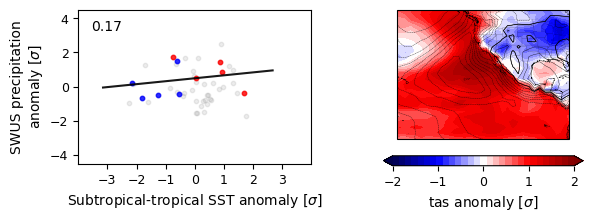

In [130]:
p90, inds, N, z, mean_pr = MHW(cam_jjas_detrend,swus_jjas_detrend, type = 'heat')

fig = plt.figure( figsize = (3,2.)
                        )


grad_obs = cam_jjas_detrend - eep_jjas_detrend
grad_stand_obs = (grad_obs-np.mean(grad_obs))/ np.std(grad_obs)

southwest = (swus_jjas_detrend-np.mean(swus_jjas_detrend))/ np.std(swus_jjas_detrend)

p1 = np.percentile(cam_jjas_detrend, 10)
mcw_ind = np.where(cam_jjas_detrend < p1)[0]
p2 = np.percentile(cam_jjas_detrend, 90)
mhw_ind = np.where(cam_jjas_detrend > p2)[0]

p1_std = (p1 - cam_jjas_detrend.mean())/cam_jjas_detrend.std()
p2_std = (p2 - cam_jjas_detrend.mean())/cam_jjas_detrend.std()

# Concatenate precip during extreme SSTs
x_mhw = np.concatenate([grad_stand_obs[mcw_ind], grad_stand_obs[mhw_ind]])
y_mhw = np.concatenate([southwest[mcw_ind], southwest[mhw_ind]])

n = len(mhw_ind)
m,b, r, p, se = scipy.stats.linregress(x_mhw,y_mhw)

x_fit = np.linspace(x_mhw.min()-1, x_mhw.max()+1, 1000)
# Plot fit
plt.scatter(grad_stand_obs, southwest, color='gray', alpha=0.15, s = 10)

plt.scatter(grad_stand_obs[mhw_ind], southwest[mhw_ind], color='red', alpha=0.8, s = 10, zorder = 10)

plt.scatter(grad_stand_obs[mcw_ind], southwest[mcw_ind], color='blue', alpha=0.8, s = 10, zorder = 10)
plt.plot(x_fit, x_fit * m + b, color='k', alpha = 0.9,
        label = f"m = {m:.2f}\np = {p:.1e} ", zorder = 15)

# plt.scatter(margin[35], southwest[35], color='red', s = 40, marker= '*', zorder = 10)
plt.xlabel('Subtropical-tropical SST anomaly [$\sigma$]')
plt.ylabel('SWUS precipitation\nanomaly [$\sigma$]')
plt.text(-2.5,3.5, f"{m:.2f}", fontsize = 10,va='center', ha='right')
# plt.legend()


# plt.axvline(p1_std, color = 'dimgrey', linewidth = 1, zorder = 12)
# plt.axvline(p2_std, color = 'dimgrey', linewidth = 1, zorder = 12)

plt.yticks(np.arange(-4,6,2))
plt.tick_params(labelsize=9)
plt.ylim([-4.5,4.5])
plt.xlim([-4,4])
plt.xticks(np.arange(-3,4,1))
plt.tick_params(labelsize=9)



ax_map = fig.add_axes([1., 0.02, .95, 0.86], projection=crs)


# mhw_pr = gpcp_precip_detrend_map[inds,:,:]
# plot = (mhw_pr.mean(axis = 0) - gpcp_precip_detrend_map.mean(axis = 0)) / gpcp_precip_detrend_map.std(axis = 0)


# SLP composite mean during MHWs
mhw_slp = era5_slp_detrend_map[inds,:,:]
slp_contours = (mhw_slp.mean(axis = 0) - era5_slp_detrend_map.mean(axis = 0)) / era5_slp_detrend_map.std(axis = 0)

mhw_tas = era5_t2m_detrend_map[inds,:,:]
plot = (mhw_tas.mean(axis = 0) - era5_t2m_detrend_map.mean(axis = 0)) / era5_t2m_detrend_map.std(axis = 0)

# Plot pr mean
f = ax_map.contourf(gpcp_precip_detrend_map.lon, gpcp_precip_detrend_map.lat, plot, 
                levels = np.linspace(-2,2, 30), 
                cmap = 'seismic',
                norm = colors.TwoSlopeNorm(vcenter=0.),
                transform=ccrs.PlateCarree(),
                extend = 'both'
               )

# Plot SLP mean
levels = np.arange(-2,3,.2)
ax_map.contour(gpcp_precip_detrend_map.lon, gpcp_precip_detrend_map.lat, slp_contours, levels=levels,
                          colors='black', linewidths=0.25, transform=ccrs.PlateCarree())

ax_map.contour(gpcp_precip_detrend_map.lon, gpcp_precip_detrend_map.lat, slp_contours, levels=[0],
                          colors='black', linewidths=0.5, transform=ccrs.PlateCarree())



ax_map.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
ax_map.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
ax_map.set_extent([200,280,-5,46])

# ax.set_title('Observed MHW composite (n=5)')
cbar = fig.colorbar(f, ax=ax_map,orientation = 'horizontal', use_gridspec = True,shrink = .7, pad = 0.1,label = 'tas anomaly [$\sigma$]',ticks = np.arange(-2.,3,1)
                    #ticks = np.arange(0,7,1)
                   )
cbar.ax.tick_params(labelsize=9)


# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/obs_mhws.jpg', dpi = 300,bbox_inches="tight")

In [131]:
mhw_ind

array([11, 13, 18, 35, 36])

In [132]:
inds

array([11, 13, 18, 35, 36])

In [134]:
era5_t2m_detrend_map.time[inds]

<xarray.DataArray 'time' (time: 5)>
array([1990, 1992, 1997, 2014, 2015])
Coordinates:
  * time     (time) int64 1990 1992 1997 2014 2015

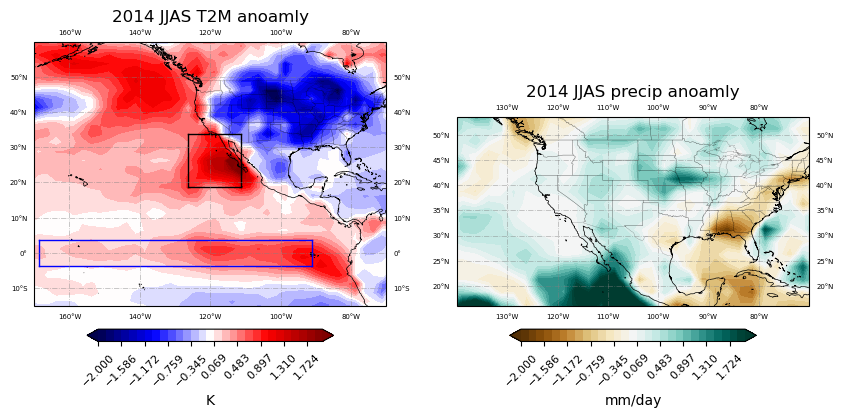

In [127]:
lon = t2m_jjas.lon
lat = t2m_jjas.lat
fig, axes = plt.subplots(1, 2,
                         figsize=(10,5),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={ 'hspace': 0.0001})

ax = axes[0]



# Draw gridlines in degrees over Mercator map
gl = ax.gridlines(crs=crs, draw_labels=True,
                  linewidth=.6, color='gray', alpha=0.5, linestyle='-.')
gl.xlabel_style = {"size" : 5}
gl.ylabel_style = {"size" : 5}

# To plot borders and coastlines, we can use cartopy feature
ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.5)
ax.add_feature(cf.STATES, lw=0.2, alpha = 0.5)
#/ax.add_feature(cart.feature.OCEAN, zorder=100, edgecolor='k')
ax.set_extent([190,290,-10,48])

to_plot= era5_t2m_detrend_map[35,:,:]
f = ax.contourf(lon, lat, to_plot, 
                    levels = np.linspace(-2,2,30), 
                    cmap = 'seismic',
                    # norm = colors.TwoSlopeNorm(vcenter=0),
                    transform=ccrs.PlateCarree(), 
                extend = 'both'
               )

ax.plot([233.75,233.75], [18.75, 33.75], color='k', linewidth=1,
           transform=ccrs.PlateCarree())
    
ax.plot([248.75,248.75], [18.75, 33.75], color='k', linewidth=1,
        transform=ccrs.PlateCarree())

ax.plot([233.75, 248.75], [18.75, 18.75], color='k', linewidth=1,
        transform=ccrs.PlateCarree())

ax.plot([233.75,248.75], [33.75,33.75], color='k', linewidth=1,
        transform=ccrs.PlateCarree())


ax.plot([191.25,191.25], [-3.75, 3.75], color='b', linewidth=1,
            transform=ccrs.PlateCarree())
    
ax.plot([268.75,268.75], [-3.75, 3.75], color='b', linewidth=1,
        transform=ccrs.PlateCarree())

ax.plot([191.25, 268.75], [-3.75,-3.75], color='b', linewidth=1,
        transform=ccrs.PlateCarree())

ax.plot([191.25,268.75], [3.75,3.75], color='b', linewidth=1,
        transform=ccrs.PlateCarree())
###########################################

ax.set_title('2014 JJAS T2M anoamly')
cbar = fig.colorbar(f, ax=ax,orientation = 'horizontal', use_gridspec = True,shrink = .7,pad = .06, label = 'K',#ticks = np.arange(0,9,1)
                    #ticks = np.arange(0,7,1)
                   )
cbar.ax.tick_params(labelsize=8, rotation = 45)


ax = axes[1]



# Draw gridlines in degrees over Mercator map
gl = ax.gridlines(crs=crs, draw_labels=True,
                  linewidth=.6, color='gray', alpha=0.5, linestyle='-.')
gl.xlabel_style = {"size" : 5}
gl.ylabel_style = {"size" : 5}

# To plot borders and coastlines, we can use cartopy feature
ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.5)
ax.add_feature(cf.STATES, lw=0.2, alpha = 0.5)
#/ax.add_feature(cart.feature.OCEAN, zorder=100, edgecolor='k')
ax.set_extent([220,290,16,48])

to_plot= gpcp_precip_detrend_map[35,:,:]
f = ax.contourf(lon, lat, to_plot, 
                    levels = np.linspace(-2,2,30), 
                    cmap = 'BrBG',
                     norm = colors.TwoSlopeNorm(vcenter=0),
                    transform=ccrs.PlateCarree(), 
                extend = 'both'
               )


###########################################

ax.set_title('2014 JJAS precip anoamly')
cbar = fig.colorbar(f, ax=ax,orientation = 'horizontal', use_gridspec = True,shrink = .7,pad = .06, label = 'mm/day',#ticks = np.arange(0,9,1)
                    #ticks = np.arange(0,7,1)
                   )
cbar.ax.tick_params(labelsize=8, rotation = 45)



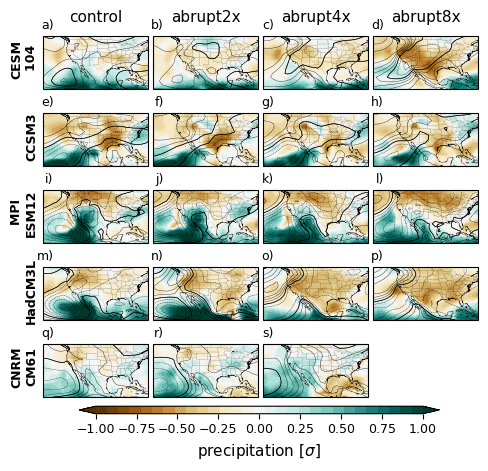

In [112]:
precip_maps_s = data['sw_detrend_dict_mon_map']
margin_ts_s = data['marg_detrend_dict_mon']
eep_ts_s = data['eep_detrend_dict_mon']
sw_ts_s = data['sw_detrend_dict_mon']
tas_maps_s = data['tas_detrend_dict_mon_map']
slp_maps_s = data['slp_detrend_dict_mon_map']


letters = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)','g)', 'h)', 'i)', 'j)', 'k)', 'l)','m)', 'n)', 'o)', 'p)', 'q)', 'r)', 's)']
fig, axes = plt.subplots(len(all_models), 4,
                         figsize=(6,5),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod

    for col, exp in enumerate(exps):
        ax = axes[row, col]

        
        lat = tas_maps_s[mod][exp].lat
        lon = tas_maps_s[mod][exp].lon

        # Get vars for model and experiment
        marg = margin_ts_s[mod][exp][:800]
        eep = eep_ts_s[mod][exp][:800]
        grad = marg-eep
        sw = sw_ts_s[mod][exp][:800]
        slp_map = slp_maps_s[mod][exp][:800]
        pr_map = precip_maps_s[mod][exp][:800]

        # Get mons with reduced gradient!   
        p90, inds, N, z, mean_pr = MHW(grad,sw, type = 'heat')

        # Pr composite mean during MHWs
        mhw_pr = pr_map[inds,:,:]
        plot = (mhw_pr.mean(axis = 0) - pr_map.mean(axis = 0)) / pr_map.std(axis = 0)

        # SLP composite mean during MHWs
        mhw_slp = slp_map[inds,:,:]
        slp_contours = (mhw_slp.mean(axis = 0) - slp_map.mean(axis = 0)) / slp_map.std(axis = 0)

        # Plot pr mean
        f = ax.contourf(lon, lat, plot, 
                        levels = np.linspace(-1,1, 30), 
                        cmap = 'BrBG',
                        norm = colors.TwoSlopeNorm(vcenter=0.),
                        transform=ccrs.PlateCarree(),
                        extend = 'both'
                       )

        # Plot SLP mean
        levels = np.arange(-1.,1,.2)
        ax.contour(lon, lat, slp_contours, levels=levels,
                                  colors='black', linewidths=0.25, transform=ccrs.PlateCarree())

        ax.contour(lon, lat, slp_contours, levels=[0],
                                  colors='black', linewidths=0.5, transform=ccrs.PlateCarree())

        
        
        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.set_extent([220,290,16,46])

        ax.text(0.1, 1.2, letters[row*4 + col], fontsize=9,
        va='center', ha='right', transform=ax.transAxes)   

        # Model title
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        # Exp title
        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.1)
        
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Colorbar

cbar_ax1 = fig.add_axes([0.185, 0.1, 0.6, 0.015])  
cb = fig.colorbar(f, cax=cbar_ax1, ticks = np.arange(-1,1.25,0.25), orientation = 'horizontal')
cb.ax.tick_params(labelsize=9)
cb.set_label('precipitation [$\sigma$]', size=11)
# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_pre_review/MHW_composite.jpg', dpi = 300,bbox_inches="tight")

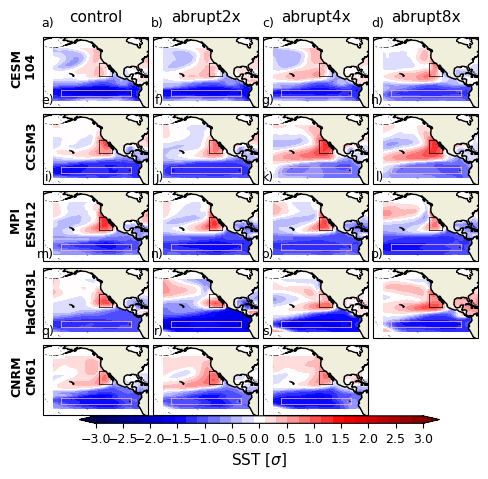

In [113]:
precip_maps_s = data['sw_detrend_dict_mon_map']
margin_ts_s = data['marg_detrend_dict_mon']
eep_ts_s = data['eep_detrend_dict_mon']
sw_ts_s = data['sw_detrend_dict_mon']
tas_maps_s = data['tas_detrend_dict_mon_map']
slp_maps_s = data['slp_detrend_dict_mon_map']


letters = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)','g)', 'h)', 'i)', 'j)', 'k)', 'l)','m)', 'n)', 'o)', 'p)', 'q)', 'r)', 's)']
fig, axes = plt.subplots(len(all_models), 4,
                         figsize=(6,5),
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude = 180)},
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod

    for col, exp in enumerate(exps):
        ax = axes[row, col]

        
        lat = tas_maps_s[mod][exp].lat
        lon = tas_maps_s[mod][exp].lon

        # Get vars for model and experiment
        marg = margin_ts_s[mod][exp][:800]
        eep = eep_ts_s[mod][exp][:800]
        grad = marg-eep
        sw = sw_ts_s[mod][exp][:800]
        slp_map = slp_maps_s[mod][exp][:800]
        tas_map = tas_maps_s[mod][exp][:800]

        # Get MHW mons    
        p90, inds, N, z, mean_pr = MHW(grad,sw, type = 'heat')

        # Pr composite mean during MHWs
        mhw_tas = tas_map[inds,:,:]
        plot = (mhw_tas.mean(axis = 0) - tas_map.mean(axis = 0)) / tas_map.std(axis = 0)

        # # SLP composite mean during MHWs
        # mhw_slp = slp_map[inds,:,:]
        # slp_contours = (mhw_slp.mean(axis = 0) - slp_map.mean(axis = 0)) / slp_map.std(axis = 0)

        # Plot pr mean
        f = ax.contourf(lon, lat, plot, 
                        levels = np.linspace(-3,3, 30), 
                        cmap = 'seismic',
                        norm = colors.TwoSlopeNorm(vcenter=0.),
                        transform=ccrs.PlateCarree(),
                        extend = 'both'
                       )

        # Plot SLP mean
        # levels = np.arange(-1.,1,.2)
        # ax.contour(lon, lat, slp_contours, levels=levels,
        #                           colors='black', linewidths=0.25, transform=ccrs.PlateCarree())

        # ax.contour(lon, lat, slp_contours, levels=[0],
        #                           colors='black', linewidths=0.5, transform=ccrs.PlateCarree())

        ax.plot([233.75,233.75], [18.75, 33.75], color='k', linewidth=0.5,
            transform=ccrs.PlateCarree())
    
        ax.plot([248.75,248.75], [18.75, 33.75], color='k', linewidth=.5,
                transform=ccrs.PlateCarree())
        
        ax.plot([233.75, 248.75], [18.75, 18.75], color='k', linewidth=.5,
                transform=ccrs.PlateCarree())
        
        ax.plot([233.75,248.75], [33.75,33.75], color='k', linewidth=.5,
                transform=ccrs.PlateCarree())

        ax.plot([190,190], [-3.75, 3.75], color='pink', linewidth=0.5,
            transform=ccrs.PlateCarree())
    
        ax.plot([270,270], [-3.75, 3.75], color='pink', linewidth=0.5,
                transform=ccrs.PlateCarree())
        
        ax.plot([190, 270], [-3.75,-3.75], color='pink', linewidth=0.5,
                transform=ccrs.PlateCarree())
        
        ax.plot([190,270], [3.75,3.75], color='pink', linewidth=0.5,
                transform=ccrs.PlateCarree())
                
        
        ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
        ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
        ax.add_feature(cart.feature.LAND, zorder=2, edgecolor='k')
        ax.set_extent([170,290,-8,46])

        ax.text(0.1, 1.2, letters[row*4 + col], fontsize=9,
        va='center', ha='right', transform=ax.transAxes)   

        # Model title
        if col == 0:
            ax.text(-0.05, 0.55, title, fontsize=9, fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)
        # Exp title
        if row == 0:
            ax.set_title(exp, fontsize = 11, y = 1.1)
        
    for col in range(len(exps), 4):
        fig.delaxes(axes[row, col])

# Colorbar

cbar_ax1 = fig.add_axes([0.185, 0.1, 0.6, 0.015])  
cb = fig.colorbar(f, cax=cbar_ax1, ticks = np.arange(-3,3.5,0.5), orientation = 'horizontal')
cb.ax.tick_params(labelsize=9)
cb.set_label('SST [$\sigma$]', size=11)
# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_pre_review/MHW_compositeSST.jpg', dpi = 300,bbox_inches="tight")

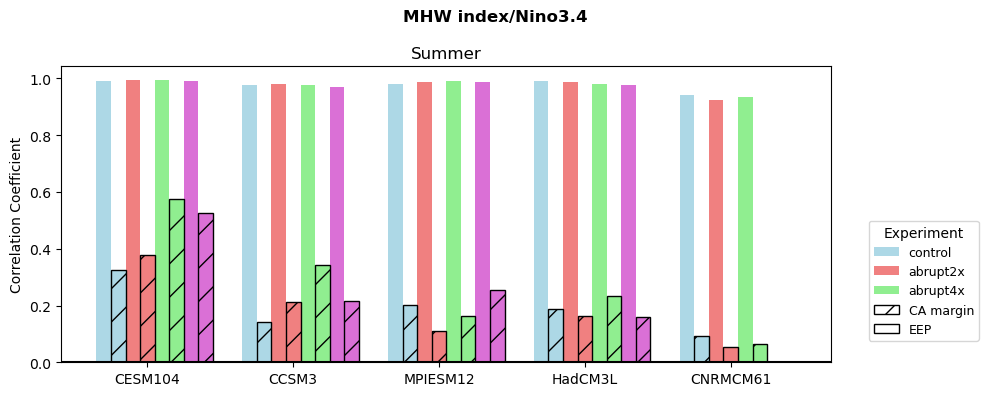

In [114]:
fig, ax = plt.subplots(1,1,figsize=(10, 4))

corr_grad = np.zeros([5,4])
corr_marg = np.zeros([5,4])
for i,mod in enumerate(all_models):
    exps = model_experiments[mod]

    for j,exp in enumerate(exps):
        margin_ts_s = data['marg_detrend_dict_mon'][mod][exp]
        eep_ts_s = data['eep_detrend_dict_mon'][mod][exp]
        grad = margin_ts_s - eep_ts_s
        nino = data['nino_detrend_dict_mon'][mod][exp]
        x,y = nino, eep_ts_s
        r = scipy.stats.pearsonr(x, y)[0]
        corr_grad[i,j] = r

        x,y = nino, margin_ts_s
        r = scipy.stats.pearsonr(x, y)[0]
        corr_marg[i,j] = r


x = np.arange(5)  # the label locations
width = 0.1  # the width of the bars

for i, exp in enumerate(model_experiments[all_models[0]]):
    offset = i*2*width
    plt.bar(x + offset, corr_grad[:, i], width, label=exp, color = colors_scatter[exp])
    plt.bar(x + offset+width, corr_marg[:, i], width, label='CA margin', hatch = '/',color = colors_scatter[exp],edgecolor = 'k', zorder = 2)


plt.ylabel('Correlation Coefficient')
plt.title('Summer')
plt.xticks(x + 3 * width, all_models)
plt.axhline(0, color = 'k')
from matplotlib.patches import Patch
legend_handles = []
for i, exp in enumerate(exps):
    legend_handles.append(Patch(facecolor=colors_scatter[exp], label=exp))
legend_handles.append(Patch(facecolor='none', hatch='/', edgecolor='k', label='CA margin'))
legend_handles.append(Patch(facecolor='none',  edgecolor='k', label='EEP'))

plt.legend(handles=legend_handles, title='Experiment', fontsize=9,bbox_to_anchor=(1.2, .5))
plt.suptitle('MHW index/Nino3.4', fontweight = 'bold')
plt.tight_layout()

plt.show()

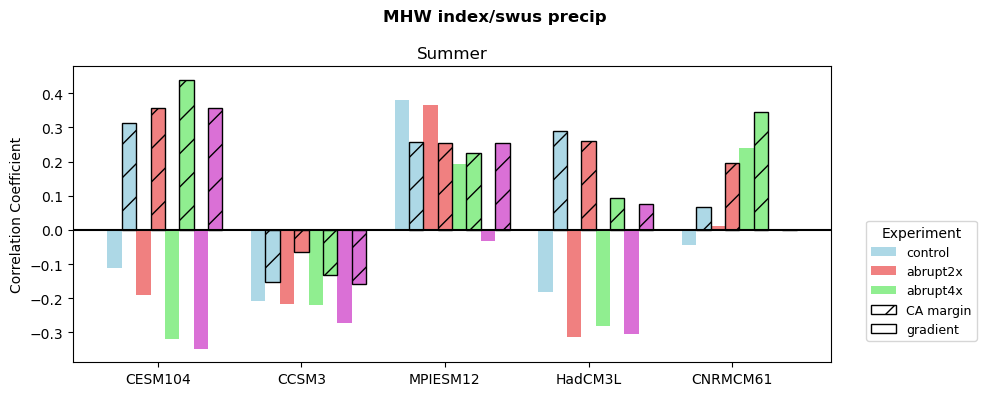

In [115]:
fig, ax = plt.subplots(1,1,figsize=(10, 4))

corr_grad = np.zeros([5,4])
corr_marg = np.zeros([5,4])
for i,mod in enumerate(all_models):
    exps = model_experiments[mod]

    for j,exp in enumerate(exps):
        precip = data['sw_detrend_dict_mon'][mod][exp]
        margin_ts_s = data['marg_detrend_dict_mon'][mod][exp]
        eep_ts_s = data['eep_detrend_dict_mon'][mod][exp]
        grad = margin_ts_s - eep_ts_s
        nino = data['nino_detrend_dict_mon'][mod][exp]
        x,y = grad, precip
        r = scipy.stats.pearsonr(x, y)[0]
        corr_grad[i,j] = r

        x,y =margin_ts_s, precip
        r = scipy.stats.pearsonr(x, y)[0]
        corr_marg[i,j] = r


x = np.arange(5)  # the label locations
width = 0.1  # the width of the bars

for i, exp in enumerate(model_experiments[all_models[0]]):
    offset = i*2*width
    plt.bar(x + offset, corr_grad[:, i], width, label=exp, color = colors_scatter[exp])
    plt.bar(x + offset+width, corr_marg[:, i], width, label='CA margin', hatch = '/',color = colors_scatter[exp],edgecolor = 'k', zorder = 2)


plt.ylabel('Correlation Coefficient')
plt.title('Summer')
plt.xticks(x + 3 * width, all_models)
plt.axhline(0, color = 'k')
from matplotlib.patches import Patch
legend_handles = []
for i, exp in enumerate(exps):
    legend_handles.append(Patch(facecolor=colors_scatter[exp], label=exp))
legend_handles.append(Patch(facecolor='none', hatch='/', edgecolor='k', label='CA margin'))
legend_handles.append(Patch(facecolor='none',  edgecolor='k', label='gradient'))

plt.legend(handles=legend_handles, title='Experiment', fontsize=9,bbox_to_anchor=(1.2, .5))
plt.suptitle('MHW index/swus precip', fontweight = 'bold')
plt.tight_layout()

plt.show()

-0.1677123199566662
0.036487751035170254
-0.1545441297145218
-0.12154860406064733
-0.3029638452105261
-0.22346113896782638
-0.30311802563079887
-0.2426453811006586
0.441527456752645
0.40419220891231994
0.28394484882437193
0.12950202784977763
0.10298339612086596
-0.11368018455435952
-0.15136638210164308
-0.195783313131159
0.06612625847533332
0.27209511811808945
0.33428464276680625


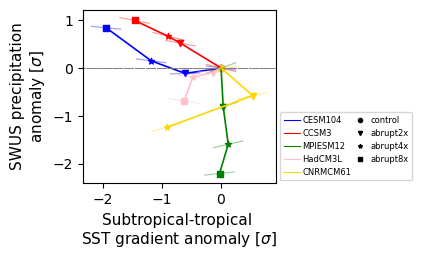

In [135]:
marg_mon_nonanom = data['marg_dict_mon']
eep_mon_nonanom = data['eep_dict_mon']
pr_mon_nonanom = data['sw_dict_mon']

marg_mon = data['marg_detrend_dict_mon']
eep_mon = data['eep_detrend_dict_mon']
# Detrended SWUS precip dictionary
pr_mon = data['sw_detrend_dict_mon']

fig, ax = plt.subplots(1,1, figsize = (2.5,2.25),gridspec_kw={'wspace': 0.05})
shapes = ['o', 'v', '*', 's', 'd']

for i, mod in enumerate(all_models):
    exps = model_experiments[mod]
    sw_eq_mean = []
    marg_eq_mean = []
    
    for j,exp in enumerate(exps):

        pr_exp = pr_mon_nonanom[mod][exp][:1000][-200:]
        pr_cont = pr_mon_nonanom[mod]['control'][:1000][-200:]
        
        margin_exp = marg_mon_nonanom[mod][exp][:1000][-200:]
        marg_cont = marg_mon_nonanom[mod]['control'][:1000][-200:]

        eep_exp = eep_mon_nonanom[mod][exp][:1000][-200:]
        eep_cont = eep_mon_nonanom[mod]['control'][:1000][-200:]

        grad_exp = margin_exp - eep_exp
        grad_cont = marg_cont - eep_cont

        z_sw = (pr_exp.mean() - pr_cont.mean())/pr_cont.std()
        # print(z_sw)
        z_ca = (grad_exp.mean() - grad_cont.mean())/ grad_cont.std()
        #z_sw = get_sw(z_sw)
        
        sw_eq_mean.append(z_sw)
        marg_eq_mean.append(z_ca)

        plt.scatter(z_ca, z_sw, color = model_colors[mod], marker = shapes[j], s = 20)


        marg_raw = marg_mon[mod][exp][:800]
        eep_raw = eep_mon[mod][exp][:800]
        grad_raw = marg_raw - eep_raw
        
        # Identify extremes based on gradient
        p1 = np.percentile(marg_raw, 10)
        mcw_ind = np.where(marg_raw < p1)[0]
        p2 = np.percentile(marg_raw, 90)
        mhw_ind = np.where(marg_raw > p2)[0]
        
        # Standardize
        x_z = (grad_raw - np.mean(grad_raw)) / np.std(grad_raw)
        y_z = (pr_mon[mod][exp][:800] - np.mean(pr_mon[mod][exp][:800])) / np.std(pr_mon[mod][exp][:800])
        
        # Combine extremes
        x_ext = np.concatenate([x_z[mcw_ind], x_z[mhw_ind]])
        y_ext = np.concatenate([y_z[mcw_ind], y_z[mhw_ind]])
        
        # Regression slope
        m, b, r, p, se = scipy.stats.linregress(x_ext, y_ext)
        print(m)


        # # print(m)
        new_x = np.linspace(z_ca.values-.25, z_ca.values+.25, 100)
        new_y = z_sw.values + m * (new_x - z_ca.values)
        plt.plot(new_x, new_y, color=model_colors[mod], alpha=0.4, linewidth = 0.8)
        plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)


    plt.plot(marg_eq_mean, sw_eq_mean, color = model_colors[mod], label = mod, linewidth = 1.2) 
    plt.axhline(0, color = 'gray', alpha = 0.6, linestyle = '--', linewidth = 0.5)



plt.ylabel("SWUS precipitation\nanomaly [$\sigma$]", fontsize = 11)

plt.xlabel("Subtropical-tropical \nSST gradient anomaly [$\sigma$]", fontsize = 11)

from matplotlib.lines import Line2D

# Model handles (just lines, no markers)
model_handles = [
    Line2D([0], [0], color=color, linestyle='-', linewidth=0.8, label=mod)
    for mod, color in model_colors.items()
]

# Experiment handles (black markers only)
shapes = ['o', 'v', '*', 's', 'd']
exp_handles = [
    Line2D([0], [0], marker=shapes[j], color='k', linestyle='None',
           label=exp, markersize=3)
    for j, exp in enumerate(model_experiments[all_models[0]])
]

# Dummy headers
header_models = Line2D([], [], linestyle='None', label=" ")
header_exps   = Line2D([], [], linestyle='None', label=" ")

# Combine both (no headers)
handles = model_handles + exp_handles
labels = [h.get_label() for h in handles]

# Place legend in the second subplot
leg = plt.legend(handles, labels,
                   loc="lower left", bbox_to_anchor=(1, -0.01),
                   fontsize=6, ncol=2, frameon=True,columnspacing=0.1, handletextpad=0.2,)

# Make headers bold
# leg = ax[1].legend(handles, labels,
#                    loc="lower center", bbox_to_anchor=(.5, -0.01),
#                    fontsize=6, ncol=2, frameon=True,columnspacing=0.1, handletextpad=0.2,)
for text in leg.get_texts():
    if text.get_text() in ["Models", "Experiments"]:
        text.set_fontweight("bold")
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_resubmit/fig4_grad.jpg', dpi = 300,bbox_inches="tight")

## Compare with CMIP

In [21]:
models_cmip = ['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'BCC-ESM1', 
          'CAMS-CSM1-0', 'CanESM5','CESM2', 'CESM2-FV2', 'CESM2-WACCM', 'CESM2-WACCM-FV2',
          'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR',
          'CNRM-ESM2-1', 'E3SM-1-0', 'FGOALS-f3-L', 'FGOALS-g3',  
         'GISS-E2-1-G', 'GISS-E2-1-H',
         'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM5A2-INCA', 'IPSL-CM6A-LR',
           'KACE-1-0-G', 'MIROC-ES2L', 'MIROC6', 'MPI-ESM-1-2-HAM', 
          'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorCPM1', 
         'NorESM2-MM', 'SAM0-UNICON', 'TaiESM1', 'UKESM1-0-LL']

In [22]:
with open('/scratch/olee/research/hist_data/hist_dict.pkl', 'rb') as f:
    historical = pickle.load(f)

with open('/scratch/olee/research/piControl_data/piC_dict.pkl', 'rb') as f:
    piControl = pickle.load(f)

In [23]:
for model in models_cmip:
    print(piControl['pr'][model].time.shape)

(6000,)
(10800,)
(6000,)
(7200,)
(5412,)
(6000,)
(12000,)
(14400,)
(6000,)
(5988,)
(6000,)
(6000,)
(6000,)
(3000,)
(6000,)
(3600,)
(6000,)
(6000,)
(6732,)
(8400,)
(10212,)
(9612,)
(6372,)
(14412,)
(3000,)
(24000,)
(1800,)
(6000,)
(9600,)
(9360,)
(6000,)
(12000,)
(8412,)
(6000,)
(6000,)
(6000,)
(8400,)
(6000,)
(9000,)


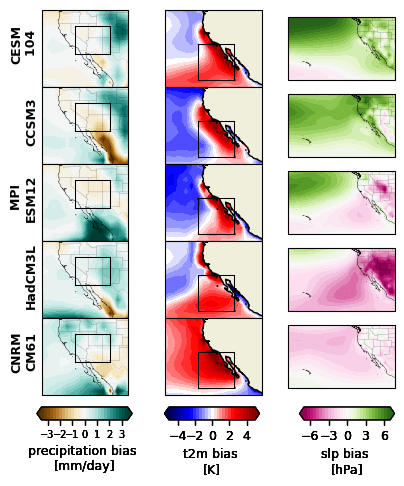

In [21]:
fig, axes = plt.subplots(5, 3,
                         figsize=(5,5),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={ 'hspace': 0.0001})
fig.subplots_adjust( right=0.85)

for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
########## Precip
    ax = axes[row,0]
 

    control_pr = data['pr_mon_map_nonanom_all'][mod]['control'][:1000]
    control_slp = data['slp_mon_map_nonanom_all'][mod]['control'][:1000]
    lon = control_pr.lon
    lat = control_pr.lat
    control_pr =  control_pr[-200:].mean(axis = 0)
    control_slp =  control_slp[-200:].mean(axis = 0)

    pr_diff = control_pr - pr_obs.mean(axis = 0)

    # Plot pr in colored filled contours
    c = ax.contourf(lon, lat, pr_diff, 
                    levels=np.linspace(-3.5,3.5,30),
                    cmap = 'BrBG',
                    norm = colors.TwoSlopeNorm(vcenter=0.),
                    transform=ccrs.PlateCarree(),
                    extend = 'both'
                   )
   

    ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
    ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
    ax.set_extent([230,260,20,46])
    ax.text(-0.05, 0.55, title, fontsize=9,fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)

    # Colorbars
    cbar_ax1 = fig.add_axes([0.135, 0.06, 0.19, 0.025])  
    cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="mm/day", ticks = np.arange(-3,4,1))
    cb.ax.tick_params(labelsize=7)
    cb.set_label('precipitation bias \n[mm/day]', size=9)

    ax.plot([241.25,241.25], [31.25, 41.25], color='k', linewidth=0.75,
           transform=ccrs.PlateCarree())
    
    ax.plot([253.75,253.75], [31.25, 41.25], color='k', linewidth=0.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([241.25,253.75], [31.25, 31.25], color='k', linewidth=0.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([241.25,253.75], [41.25,41.25], color='k', linewidth=0.75,
            transform=ccrs.PlateCarree())
       
############# Tas

    ax = axes[row,1]
    
    control_tas = data['tas_mon_map_nonanom_all'][mod]['control'][:1000]
    lon = control_tas.lon
    lat = control_tas.lat
    control_tas =  control_tas[-200:].mean(axis = 0)

    tas_diff = control_tas - tas_obs.mean(axis = 0)

    # Plot pr in colored filled contours
    c = ax.contourf(lon, lat, tas_diff, 
                    levels=np.linspace(-5,5,30),
                    cmap = 'seismic',
                    norm = colors.TwoSlopeNorm(vcenter=0.),
                    transform=ccrs.PlateCarree(),
                    extend = 'both'
                   )

    ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
    ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
    ax.add_feature(cart.feature.LAND, zorder=2, edgecolor='k')
    ax.set_extent([220,260,16,46])

    ax.plot([233.75,233.75], [18.75, 33.75], color='k', linewidth=0.75,
        transform=ccrs.PlateCarree())

    ax.plot([248.75,248.75], [18.75, 33.75], color='k', linewidth=.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([233.75, 248.75], [18.75, 18.75], color='k', linewidth=.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([233.75,248.75], [33.75,33.75], color='k', linewidth=.75,
            transform=ccrs.PlateCarree())


           
    cbar_ax1 = fig.add_axes([0.39, 0.06, 0.19, 0.025])  
    cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="K", ticks = np.arange(-4,6,2))
    cb.ax.tick_params(labelsize=9)
    cb.set_label('t2m bias \n[K]', size=9)


################# SLP
    ax = axes[row,2]
     
    
    control_slp = data['slp_mon_map_nonanom_all'][mod]['control'][:1000]
    lon = control_tas.lon
    lat = control_tas.lat
    control_slp =  control_slp[-200:].mean(axis = 0)

    slp_diff = control_slp - slp_obs.mean(axis = 0)

    # Plot pr in colored filled contours
    c = ax.contourf(lon, lat, slp_diff, 
                    levels=np.linspace(-7,7,30),
                    cmap = 'PiYG',
                    norm = colors.TwoSlopeNorm(vcenter=0.),
                    transform=ccrs.PlateCarree(),
                    extend = 'both'
                   )
   

    ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
    ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
    # ax.add_feature(cart.feature.LAND, zorder=2, edgecolor='k')
    ax.set_extent([190,260,10,46])

    # ax.plot([233.75,233.75], [18.75, 33.75], color='k', linewidth=0.75,
    #     transform=ccrs.PlateCarree())

    # ax.plot([248.75,248.75], [18.75, 33.75], color='k', linewidth=.75,
    #         transform=ccrs.PlateCarree())
    
    # ax.plot([233.75, 248.75], [18.75, 18.75], color='k', linewidth=.75,
    #         transform=ccrs.PlateCarree())
    
    # ax.plot([233.75,248.75], [33.75,33.75], color='k', linewidth=.75,
    #         transform=ccrs.PlateCarree())


           
    cbar_ax1 = fig.add_axes([0.66, 0.06, 0.19, 0.025])  
    cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="K", ticks = np.arange(-6,9,3))
    cb.ax.tick_params(labelsize=9)
    cb.set_label('slp bias \n[hPa]', size=9)

# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_review1/bias.jpg', dpi = 300,bbox_inches="tight")

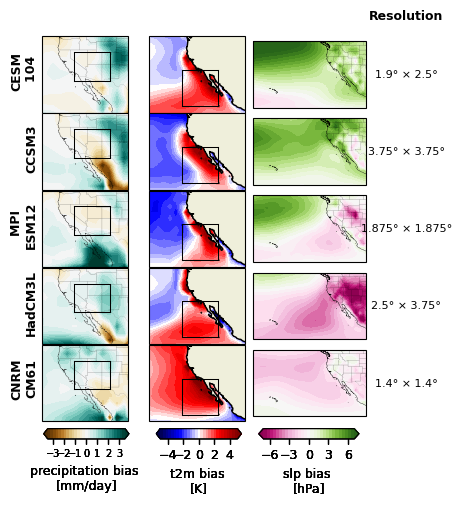

In [48]:
horizontal_resolution = {
    'CCSM3': '3.75° × 3.75°',
    'CESM104': '1.9° × 2.5°',
    'CNRMCM61': '1.4° × 1.4°',
    'HadCM3L': '2.5° × 3.75°',
    'MPIESM12': '1.875° × 1.875°'
}

fig = plt.figure(figsize=(5, 5))

gs = fig.add_gridspec(
    5, 4,
    width_ratios=[1, 1, 1, 0.45],
    hspace=0.01,
    wspace=0.0005
)

axes = np.empty((5, 3), dtype=object)
res_axes = []

for row in range(5):
    for col in range(3):
        axes[row, col] = fig.add_subplot(
            gs[row, col],
            projection=ccrs.PlateCarree()
        )

    res_ax = fig.add_subplot(gs[row, 3])
    res_ax.axis('off')
    res_axes.append(res_ax)

res_axes[0].text(
    0.8, 1.18,
    'Resolution',
    ha='center',
    va='bottom',
    fontsize=9,
    fontweight='bold',
    transform=res_axes[0].transAxes
)


for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
########## Precip
    ax = axes[row,0]
 

    control_pr = data['pr_mon_map_nonanom_all'][mod]['control'][:1000]
    control_slp = data['slp_mon_map_nonanom_all'][mod]['control'][:1000]
    lon = control_pr.lon
    lat = control_pr.lat
    control_pr =  control_pr[-200:].mean(axis = 0)
    control_slp =  control_slp[-200:].mean(axis = 0)

    pr_diff = control_pr - pr_obs.mean(axis = 0)

    # Plot pr in colored filled contours
    c = ax.contourf(lon, lat, pr_diff, 
                    levels=np.linspace(-3.5,3.5,30),
                    cmap = 'BrBG',
                    norm = colors.TwoSlopeNorm(vcenter=0.),
                    transform=ccrs.PlateCarree(),
                    extend = 'both'
                   )
   

    ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.2)
    ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
    ax.set_extent([230,260,20,46])
    ax.text(-0.05, 0.55, title, fontsize=9,fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)

    # Colorbars
    cbar_ax1 = fig.add_axes([0.155, 0.075, 0.17, 0.02])  
    cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="mm/day", ticks = np.arange(-3,4,1))
    cb.ax.tick_params(labelsize=7)
    cb.set_label('precipitation bias \n[mm/day]', size=9)

    ax.plot([241.25,241.25], [31.25, 41.25], color='k', linewidth=0.75,
           transform=ccrs.PlateCarree())
    
    ax.plot([253.75,253.75], [31.25, 41.25], color='k', linewidth=0.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([241.25,253.75], [31.25, 31.25], color='k', linewidth=0.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([241.25,253.75], [41.25,41.25], color='k', linewidth=0.75,
            transform=ccrs.PlateCarree())


    ax = axes[row,1]
    
    control_tas = data['tas_mon_map_nonanom_all'][mod]['control'][:1000]
    lon = control_tas.lon
    lat = control_tas.lat
    control_tas =  control_tas[-200:].mean(axis = 0)

    tas_diff = control_tas - tas_obs.mean(axis = 0)

    # Plot pr in colored filled contours
    c = ax.contourf(lon, lat, tas_diff, 
                    levels=np.linspace(-5,5,30),
                    cmap = 'seismic',
                    norm = colors.TwoSlopeNorm(vcenter=0.),
                    transform=ccrs.PlateCarree(),
                    extend = 'both'
                   )

    ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
    ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
    ax.add_feature(cart.feature.LAND, zorder=2, edgecolor='k')
    ax.set_extent([220,260,16,46])

    ax.plot([233.75,233.75], [18.75, 33.75], color='k', linewidth=0.75,
        transform=ccrs.PlateCarree())

    ax.plot([248.75,248.75], [18.75, 33.75], color='k', linewidth=.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([233.75, 248.75], [18.75, 18.75], color='k', linewidth=.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([233.75,248.75], [33.75,33.75], color='k', linewidth=.75,
            transform=ccrs.PlateCarree())

           
    cbar_ax1 = fig.add_axes([0.38, 0.075, 0.17, 0.02])  
    cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="K", ticks = np.arange(-4,6,2))
    cb.ax.tick_params(labelsize=9)
    cb.set_label('t2m bias \n[K]', size=9)

    ax = axes[row,2]
     
    
    control_slp = data['slp_mon_map_nonanom_all'][mod]['control'][:1000]
    lon = control_tas.lon
    lat = control_tas.lat
    control_slp =  control_slp[-200:].mean(axis = 0)

    slp_diff = control_slp - slp_obs.mean(axis = 0)

    # Plot pr in colored filled contours
    c = ax.contourf(lon, lat, slp_diff, 
                    levels=np.linspace(-7,7,30),
                    cmap = 'PiYG',
                    norm = colors.TwoSlopeNorm(vcenter=0.),
                    transform=ccrs.PlateCarree(),
                    extend = 'both'
                   )
   

    ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
    ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
    # ax.add_feature(cart.feature.LAND, zorder=2, edgecolor='k')
    ax.set_extent([190,260,10,46])

    # ax.plot([233.75,233.75], [18.75, 33.75], color='k', linewidth=0.75,
    #     transform=ccrs.PlateCarree())

    # ax.plot([248.75,248.75], [18.75, 33.75], color='k', linewidth=.75,
    #         transform=ccrs.PlateCarree())
    
    # ax.plot([233.75, 248.75], [18.75, 18.75], color='k', linewidth=.75,
    #         transform=ccrs.PlateCarree())
    
    # ax.plot([233.75,248.75], [33.75,33.75], color='k', linewidth=.75,
    #         transform=ccrs.PlateCarree())

    res_axes[row].text(
        0.8, 0.5,
        horizontal_resolution[mod],
        ha='center',
        va='center',
        fontsize=8
    )

           
    cbar_ax1 = fig.add_axes([0.585, 0.075, 0.2, 0.02])  
    cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="K", ticks = np.arange(-6,9,3))
    cb.ax.tick_params(labelsize=9)
    cb.set_label('slp bias \n[hPa]', size=9)

# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_review1/bias.jpg', dpi = 300,bbox_inches="tight")

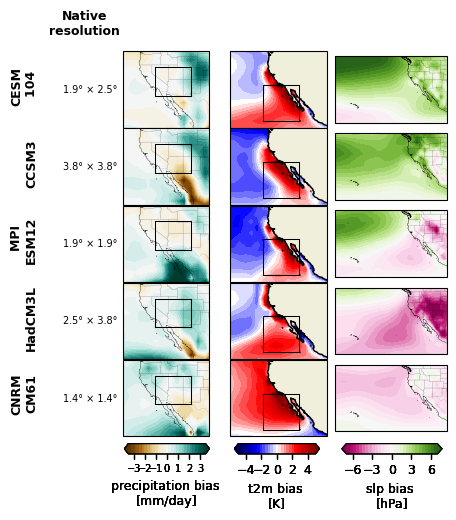

In [85]:
horizontal_resolution = {
    'CCSM3': '3.8° × 3.8°',
    'CESM104': '1.9° × 2.5°',
    'CNRMCM61': '1.4° × 1.4°',
    'HadCM3L': '2.5° × 3.8°',
    'MPIESM12': '1.9° × 1.9°'
}

fig = plt.figure(figsize=(5, 5))

gs = fig.add_gridspec(
    5, 4,
    width_ratios=[0.45,1, 1, 1],
    hspace=0.01,
    wspace=0.0005
)

axes = np.empty((5, 3), dtype=object)
res_axes = []

for row in range(5):

    # leftmost resolution column
    res_ax = fig.add_subplot(gs[row, 0])
    res_ax.axis('off')
    res_axes.append(res_ax)

    # map columns: GridSpec cols 1, 2, 3
    # but axes cols remain 0, 1, 2
    for col in range(3):
        axes[row, col] = fig.add_subplot(
            gs[row, col + 1],
            projection=ccrs.PlateCarree()
        )

res_axes[0].text(
    0.5, 1.18,
    'Native\nresolution',
    ha='center',
    va='bottom',
    fontsize=9,
    fontweight='bold',
    transform=res_axes[0].transAxes
)


for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
########## Precip
    ax = axes[row,0]
 

    control_pr = data['pr_mon_map_nonanom_all'][mod]['control'][:1000]
    control_slp = data['slp_mon_map_nonanom_all'][mod]['control'][:1000]
    lon = control_pr.lon
    lat = control_pr.lat
    control_pr =  control_pr[-200:].mean(axis = 0)
    control_slp =  control_slp[-200:].mean(axis = 0)

    pr_diff = control_pr - pr_obs.mean(axis = 0)

    # Plot pr in colored filled contours
    c = ax.contourf(lon, lat, pr_diff, 
                    levels=np.linspace(-3.5,3.5,30),
                    cmap = 'BrBG',
                    norm = colors.TwoSlopeNorm(vcenter=0.),
                    transform=ccrs.PlateCarree(),
                    extend = 'both'
                   )
   

    ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.2)
    ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
    ax.set_extent([230,260,20,46])
    ax.text(-1, 0.55, title, fontsize=9,fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)

    # Colorbars
    cbar_ax1 = fig.add_axes([0.255, 0.075, 0.17, 0.02])  
    cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="mm/day", ticks = np.arange(-3,4,1))
    cb.ax.tick_params(labelsize=7)
    cb.set_label('precipitation bias \n[mm/day]', size=9)

    ax.plot([241.25,241.25], [31.25, 41.25], color='k', linewidth=0.75,
           transform=ccrs.PlateCarree())
    
    ax.plot([253.75,253.75], [31.25, 41.25], color='k', linewidth=0.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([241.25,253.75], [31.25, 31.25], color='k', linewidth=0.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([241.25,253.75], [41.25,41.25], color='k', linewidth=0.75,
            transform=ccrs.PlateCarree())


    ax = axes[row,1]
    
    control_tas = data['tas_mon_map_nonanom_all'][mod]['control'][:1000]
    lon = control_tas.lon
    lat = control_tas.lat
    control_tas =  control_tas[-200:].mean(axis = 0)

    tas_diff = control_tas - tas_obs.mean(axis = 0)

    # Plot pr in colored filled contours
    c = ax.contourf(lon, lat, tas_diff, 
                    levels=np.linspace(-5,5,30),
                    cmap = 'seismic',
                    norm = colors.TwoSlopeNorm(vcenter=0.),
                    transform=ccrs.PlateCarree(),
                    extend = 'both'
                   )

    ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
    ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
    ax.add_feature(cart.feature.LAND, zorder=2, edgecolor='k')
    ax.set_extent([220,260,16,46])

    ax.plot([233.75,233.75], [18.75, 33.75], color='k', linewidth=0.75,
        transform=ccrs.PlateCarree())

    ax.plot([248.75,248.75], [18.75, 33.75], color='k', linewidth=.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([233.75, 248.75], [18.75, 18.75], color='k', linewidth=.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([233.75,248.75], [33.75,33.75], color='k', linewidth=.75,
            transform=ccrs.PlateCarree())

           
    cbar_ax1 = fig.add_axes([0.475, 0.075, 0.17, 0.02])  
    cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="K", ticks = np.arange(-4,6,2))
    cb.ax.tick_params(labelsize=9)
    cb.set_label('t2m bias \n[K]', size=9)

    ax = axes[row,2]
     
    
    control_slp = data['slp_mon_map_nonanom_all'][mod]['control'][:1000]
    lon = control_tas.lon
    lat = control_tas.lat
    control_slp =  control_slp[-200:].mean(axis = 0)

    slp_diff = control_slp - slp_obs.mean(axis = 0)

    # Plot pr in colored filled contours
    c = ax.contourf(lon, lat, slp_diff, 
                    levels=np.linspace(-7,7,30),
                    cmap = 'PiYG',
                    norm = colors.TwoSlopeNorm(vcenter=0.),
                    transform=ccrs.PlateCarree(),
                    extend = 'both'
                   )
   

    ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
    ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
    # ax.add_feature(cart.feature.LAND, zorder=2, edgecolor='k')
    ax.set_extent([190,260,10,46])

    # ax.plot([233.75,233.75], [18.75, 33.75], color='k', linewidth=0.75,
    #     transform=ccrs.PlateCarree())

    # ax.plot([248.75,248.75], [18.75, 33.75], color='k', linewidth=.75,
    #         transform=ccrs.PlateCarree())
    
    # ax.plot([233.75, 248.75], [18.75, 18.75], color='k', linewidth=.75,
    #         transform=ccrs.PlateCarree())
    
    # ax.plot([233.75,248.75], [33.75,33.75], color='k', linewidth=.75,
    #         transform=ccrs.PlateCarree())

    
    res_axes[row].text(
        0.6, 0.5,
        horizontal_resolution[mod],
        ha='center',
        va='center',
        fontsize=7
    )

           
    cbar_ax1 = fig.add_axes([0.69, 0.075, 0.2, 0.02])  
    cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="K", ticks = np.arange(-6,9,3))
    cb.ax.tick_params(labelsize=9)
    cb.set_label('slp bias \n[hPa]', size=9)

# fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_review2/bias_withres.jpg', dpi = 300,bbox_inches="tight")

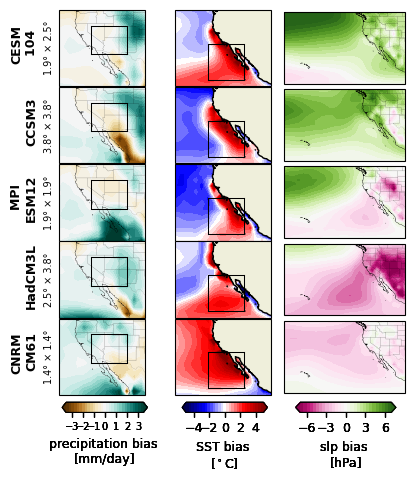

In [22]:
horizontal_resolution = {
    'CCSM3': '3.8° × 3.8°',
    'CESM104': '1.9° × 2.5°',
    'CNRMCM61': '1.4° × 1.4°',
    'HadCM3L': '2.5° × 3.8°',
    'MPIESM12': '1.9° × 1.9°'
}

fig = plt.figure(figsize=(5, 5))

gs = fig.add_gridspec(
    5, 4,
    width_ratios=[0.2,1, 1, 1],
    hspace=0.01,
    wspace=0.0005
)

axes = np.empty((5, 3), dtype=object)
res_axes = []

for row in range(5):

    # leftmost resolution column
    res_ax = fig.add_subplot(gs[row, 0])
    res_ax.axis('off')
    res_axes.append(res_ax)

    # map columns: GridSpec cols 1, 2, 3
    # but axes cols remain 0, 1, 2
    for col in range(3):
        axes[row, col] = fig.add_subplot(
            gs[row, col + 1],
            projection=ccrs.PlateCarree()
        )

# res_axes[0].text(
#     0.5, 1.18,
#     'Native\nresolution',
#     ha='center',
#     va='bottom',
#     fontsize=9,
#     fontweight='bold',
#     transform=res_axes[0].transAxes
# )


for row, mod in enumerate(all_models):
    exps = model_experiments[mod]
    if mod == 'MPIESM12':
        title = "MPI  \nESM12"
    elif mod == 'CNRMCM61':
        title = "CNRM\nCM61"
    elif mod =='CESM104':
        title = 'CESM\n104 '
    else:
        title = mod
########## Precip
    ax = axes[row,0]
 

    control_pr = data['pr_mon_map_nonanom_all'][mod]['control'][:1000]
    control_slp = data['slp_mon_map_nonanom_all'][mod]['control'][:1000]
    lon = control_pr.lon
    lat = control_pr.lat
    control_pr =  control_pr[-200:].mean(axis = 0)
    control_slp =  control_slp[-200:].mean(axis = 0)

    pr_diff = control_pr - pr_obs.mean(axis = 0)

    # Plot pr in colored filled contours
    c = ax.contourf(lon, lat, pr_diff, 
                    levels=np.linspace(-3.5,3.5,30),
                    cmap = 'BrBG',
                    norm = colors.TwoSlopeNorm(vcenter=0.),
                    transform=ccrs.PlateCarree(),
                    extend = 'both'
                   )
   

    ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.2)
    ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
    ax.set_extent([230,260,20,46])
    ax.text(-0.25, 0.55, title, fontsize=9,fontweight='bold',
                    va='center', ha='right', rotation=90, transform=ax.transAxes)

    # Colorbars
    cbar_ax1 = fig.add_axes([0.215, 0.075, 0.17, 0.02])  
    cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="mm/day", ticks = np.arange(-3,4,1))
    cb.ax.tick_params(labelsize=7)
    cb.set_label('precipitation bias \n[mm/day]', size=9)

    ax.plot([241.25,241.25], [31.25, 41.25], color='k', linewidth=0.75,
           transform=ccrs.PlateCarree())
    
    ax.plot([253.75,253.75], [31.25, 41.25], color='k', linewidth=0.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([241.25,253.75], [31.25, 31.25], color='k', linewidth=0.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([241.25,253.75], [41.25,41.25], color='k', linewidth=0.75,
            transform=ccrs.PlateCarree())


    ax = axes[row,1]
    
    control_tas = data['tas_mon_map_nonanom_all'][mod]['control'][:1000]
    lon = control_tas.lon
    lat = control_tas.lat
    control_tas =  control_tas[-200:].mean(axis = 0)

    tas_diff = control_tas - tas_obs.mean(axis = 0)

    # Plot pr in colored filled contours
    c = ax.contourf(lon, lat, tas_diff, 
                    levels=np.linspace(-5,5,30),
                    cmap = 'seismic',
                    norm = colors.TwoSlopeNorm(vcenter=0.),
                    transform=ccrs.PlateCarree(),
                    extend = 'both'
                   )

    ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
    ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
    ax.add_feature(cart.feature.LAND, zorder=2, edgecolor='k')
    ax.set_extent([220,260,16,46])

    ax.plot([233.75,233.75], [18.75, 33.75], color='k', linewidth=0.75,
        transform=ccrs.PlateCarree())

    ax.plot([248.75,248.75], [18.75, 33.75], color='k', linewidth=.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([233.75, 248.75], [18.75, 18.75], color='k', linewidth=.75,
            transform=ccrs.PlateCarree())
    
    ax.plot([233.75,248.75], [33.75,33.75], color='k', linewidth=.75,
            transform=ccrs.PlateCarree())

           
    cbar_ax1 = fig.add_axes([0.455, 0.075, 0.17, 0.02])  
    cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="K", ticks = np.arange(-4,6,2))
    cb.ax.tick_params(labelsize=9)
    cb.set_label('SST bias \n[$^\circ$C]', size=9)

    ax = axes[row,2]
     
    
    control_slp = data['slp_mon_map_nonanom_all'][mod]['control'][:1000]
    lon = control_tas.lon
    lat = control_tas.lat
    control_slp =  control_slp[-200:].mean(axis = 0)

    slp_diff = control_slp - slp_obs.mean(axis = 0)

    # Plot pr in colored filled contours
    c = ax.contourf(lon, lat, slp_diff, 
                    levels=np.linspace(-7,7,30),
                    cmap = 'PiYG',
                    norm = colors.TwoSlopeNorm(vcenter=0.),
                    transform=ccrs.PlateCarree(),
                    extend = 'both'
                   )
   

    ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.25)
    ax.add_feature(cf.STATES, lw=0.2, alpha = 0.25)
    # ax.add_feature(cart.feature.LAND, zorder=2, edgecolor='k')
    ax.set_extent([190,260,10,46])

    # ax.plot([233.75,233.75], [18.75, 33.75], color='k', linewidth=0.75,
    #     transform=ccrs.PlateCarree())

    # ax.plot([248.75,248.75], [18.75, 33.75], color='k', linewidth=.75,
    #         transform=ccrs.PlateCarree())
    
    # ax.plot([233.75, 248.75], [18.75, 18.75], color='k', linewidth=.75,
    #         transform=ccrs.PlateCarree())
    
    # ax.plot([233.75,248.75], [33.75,33.75], color='k', linewidth=.75,
    #         transform=ccrs.PlateCarree())

    
    res_axes[row].text(
        1.3, 0.5,
        horizontal_resolution[mod],
        ha='center',
        va='center',
        fontsize=7,
        rotation=90
    )

           
    cbar_ax1 = fig.add_axes([0.682, 0.075, 0.2, 0.02])  
    cb=fig.colorbar(c, cax=cbar_ax1, orientation="horizontal", label="K", ticks = np.arange(-6,9,3))
    cb.ax.tick_params(labelsize=9)
    cb.set_label('slp bias \n[hPa]', size=9)

fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_review2/bias_withres.jpg', dpi = 300,bbox_inches="tight")

In [24]:
def get_mon(data):
    jjas =data.sel(time=data.time.dt.month.isin([6, 7, 8, 9])).groupby("time.year").mean("time")

    return jjas

# jjas_hist = {'tas':{},
#             'pr': {},
#             'slp': {}
#            }
# for model in models_cmip:
#     jjas_tas = get_mon(historical['tas'][model])
#     jjas_pr = get_mon(historical['pr'][model])
#     jjas_slp = get_mon(historical['slp'][model])/100
    
#     jjas_hist['tas'][model] = jjas_tas.sel(year=slice(1979,2014))
#     jjas_hist['pr'][model] = jjas_pr.sel(year=slice(1979,2014))
#     jjas_hist['slp'][model] = jjas_slp.sel(year=slice(1979,2014))


jjas_pic = {'tas':{},
            'pr': {},
            'slp': {}
           }
for model in models_cmip:
    jjas_tas = get_mon(piControl['tas'][model])
    jjas_pr = get_mon(piControl['pr'][model])
    jjas_slp = get_mon(piControl['slp'][model])/100
    
    jjas_pic['tas'][model] = jjas_tas[:1000,:,:]
    jjas_pic['pr'][model] = jjas_pr[:1000,:,:]
    jjas_pic['slp'][model] = jjas_slp[:1000,:,:]

In [105]:
def get_sw(precip_var):
    """
    Gets variable in SWUS region

    Parameters
    ----------
    precip_var : 2-D array 
        precipitation field at one timestep

    Returns
    ---------
    sw_weighted : integer
        area weighted value in SWUS
    """    
    sw = precip_var.sel(lat = slice(31.25,41.25), lon = slice(241.25, 253.75))
    sw_weighted = weighted(sw)

    return sw_weighted

def get_ca(marg_var):
    """
    Gets variable in CA margin

    Parameters
    ----------
    marg_var : 2-D array 
        SST field at one timestep

    Returns
    ---------
    ca_weighted : integer
        area weighted value in CA margin
    """       
    topo  = xr.open_dataset('/scratch/olee/research/Paleo_group/model_data/topo.nc')
    land_mask = np.where(topo.topo > 0, np.nan, 1)
    land_mask_xr = xr.DataArray(land_mask,dims=['lat', 'lon'],coords={'lat': topo.lat, 'lon':topo.lon})
    
    ca = marg_var.sel(lat = slice(18.75,33.75), lon = slice(233.75, 248.75))
    lat_ca = ca.lat
    lon_ca = ca.lon
    
    topo_box = land_mask_xr.sel(lat=slice(lat_ca.values[0],lat_ca.values[-1]), lon=slice(lon_ca.values[0],lon_ca.values[-1]))

    ca_masked = ca*topo_box
    # print(ca.lat)
    # print(360-ca.lon)
    ca_weighted = weighted(ca_masked)

    return ca_weighted

In [25]:
sw_cmip = []
ca_cmip = []
for model in models_cmip:
    sw_cmip.append(get_sw(jjas_pic['pr'][model][-200:].mean(axis = 0)))
    ca_cmip.append(get_ca(jjas_pic['tas'][model][-200:].mean(axis = 0)))

In [26]:
sw_cmip_vals = [x.item() for x in sw_cmip]
ca_cmip_vals = [x.item() for x in ca_cmip]

In [27]:
sw_obs = get_sw(pr_obs.mean('year')).item()
ca_obs = get_ca(tas_obs.mean('year')).item()

In [28]:
sw_obs

0.89262455701828

In [29]:
sw_cmip_bias = [x - sw_obs for x in sw_cmip_vals]
ca_cmip_bias = [x - ca_obs for x in ca_cmip_vals]

In [30]:
sw_five = []
ca_five = []
for mod in all_models:
    sw_five.append(get_sw(data['pr_mon_map_nonanom_all'][mod]['control'][:1000][-200:].mean(axis = 0)))
    ca_five.append(get_ca(data['tas_mon_map_nonanom_all'][mod]['control'][:1000][-200:].mean(axis = 0)))

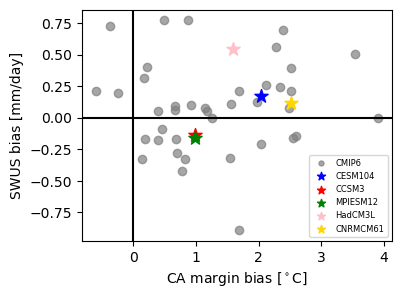

In [31]:
fig = plt.figure(figsize = (4,3))
plt.scatter(ca_cmip_bias, sw_cmip_bias, color = 'grey', alpha = 0.7, label = 'CMIP6')
for i, model in enumerate(all_models):
    pr_bias = sw_five[i] - sw_obs
    tas_bias = ca_five[i] - ca_obs
    plt.scatter(tas_bias, pr_bias, color = model_colors[model], label = model, marker = '*', s = 100)

plt.legend(fontsize = 6,markerscale=0.6,)
plt.xlabel('CA margin bias [$^\circ$C]')
plt.ylabel('SWUS bias [mm/day]')
plt.axhline(0, color = 'k')
plt.axvline(0, color = 'k')
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_review2/cmip_bias_too.jpg', dpi = 300,bbox_inches="tight")

In [32]:
models_five = {
    'CESM104': ['control', 'abrupt2x', 'abrupt4x', 'abrupt8x'],
    'CCSM3': ['control', 'abrupt2x', 'abrupt4x', 'abrupt8x'],
    'MPIESM12': ['control', 'abrupt2x', 'abrupt4x', 'abrupt8x'],
    'HadCM3L': ['control', 'abrupt2x', 'abrupt4x', 'abrupt8x'],
    'CNRMCM61': ['control', 'abrupt2x', 'abrupt4x']
}

all_data = {}

for model, exps in models_five.items():
    all_data[model] = {}
    for exp in exps:
        pr_path = f"/scratch/olee/research/Paleo_group/model_data/pr/pr_mon_{model}_{exp}*.nc"
        tas_path = f"/scratch/olee/research/Paleo_group/model_data/tas/tas_mon_{model}_{exp}*.nc"
        if model == 'CESM104' and exp == 'abrupt4x':
            all_data[model][exp] = {
                'pr': xr.open_mfdataset(pr_path)['pr']*86400000,
                'tas': xr.open_mfdataset(tas_path)['tas']
            }
        elif model == 'CESM104' and exp == 'abrupt8x':
            all_data[model][exp] = {
                'pr': xr.open_mfdataset(pr_path)['pr']*86400000,
                'tas': xr.open_mfdataset(tas_path)['tas']
            }
        else:
            all_data[model][exp] = {
                'pr': xr.open_mfdataset(pr_path)['pr']*86400,
                'tas': xr.open_mfdataset(tas_path)['tas']
            }

In [254]:
all_data[model]['control']['tas'][:12000,:,:][-2400:].time

<xarray.DataArray 'time' (time: 2400)>
array([cftime.DatetimeGregorian(2650, 1, 16, 12, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2650, 2, 15, 0, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2650, 3, 16, 12, 0, 0, 0, has_year_zero=False),
       ...,
       cftime.DatetimeGregorian(2849, 10, 16, 12, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2849, 11, 16, 0, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2849, 12, 16, 12, 0, 0, 0, has_year_zero=False)],
      dtype=object)
Coordinates:
  * time     (time) object 2650-01-16 12:00:00 ... 2849-12-16 12:00:00
    height   float64 ...
Attributes:
    standard_name:  time
    long_name:      Time axis
    bounds:         time_bnds
    axis:           T

In [33]:
seasonal_ca_five = {}
seasonal_sw_five = {}
for model in models_five:
    seasonal_ca_five[model] = get_ca(all_data[model]['control']['tas'][:12000,:,:][-2400:].groupby('time.month').mean())
    seasonal_sw_five[model] = get_sw(all_data[model]['control']['pr'][:12000,:,:][-2400:].groupby('time.month').mean())

In [34]:
seasonal_ca = {}
seasonal_sw = {}
for model in models_cmip:
    seasonal_ca[model] = get_ca(piControl['tas'][model][:12000,:,:][-2400:].groupby('time.month').mean())
    seasonal_sw[model] = get_sw(piControl['pr'][model][:12000,:,:][-2400:].groupby('time.month').mean())

In [35]:
get_ca(piControl['tas']['CESM2-WACCM'].groupby('time.month').mean())

array([291.2701657 , 291.04116645, 291.21393692, 291.71346502,
       292.51838054, 293.58345571, 295.27426374, 296.49996552,
       296.70152605, 295.8015587 , 294.24055539, 292.33876691])

In [36]:
gpcp = xr.open_mfdataset('/scratch/olee/research/Paleo_group/era5_data/precip*.nc',  combine='by_coords',drop_variables='time_bnds',decode_times=True, use_cftime=True).precip
gpcp = gpcp[:432,:,:]
obs_cycle = get_sw(gpcp.groupby('time.month').mean())


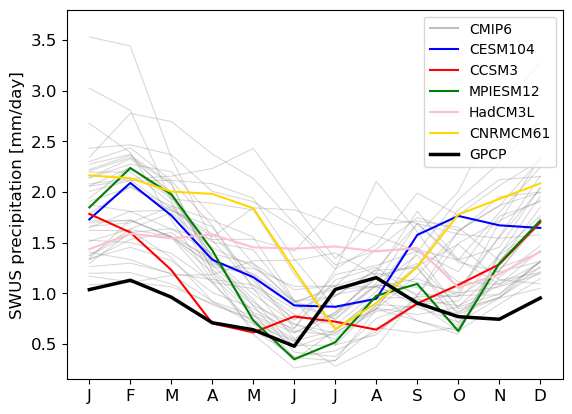

In [54]:
fig = plt.figure()
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
for model in models_cmip:
    if seasonal_sw[model][0] < 0.2:
        continue
        
    plt.plot(np.arange(1,13,1), seasonal_sw[model], color = 'grey', alpha = 0.3, linewidth = 0.8)


plt.plot(np.arange(1,13,1), np.zeros(12), color = 'grey', alpha = 0.5, label = 'CMIP6' )
for model in models_five:
    plt.plot(np.arange(1,13,1), seasonal_sw_five[model], label = model, color = model_colors[model], linewidth = 1.5)

plt.plot(np.arange(1,13,1), obs_cycle, label = 'GPCP', color = 'k', linewidth=2.5)
plt.legend(loc = 'upper right')
plt.ylim([0.15,3.8])
plt.xticks(np.arange(1,13,1), months, fontsize = 12)
plt.yticks( fontsize = 12)
plt.ylabel('SWUS precipitation [mm/day]', fontsize = 12)
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_review2/seasonal_cycle1.jpg', dpi = 300,bbox_inches="tight")


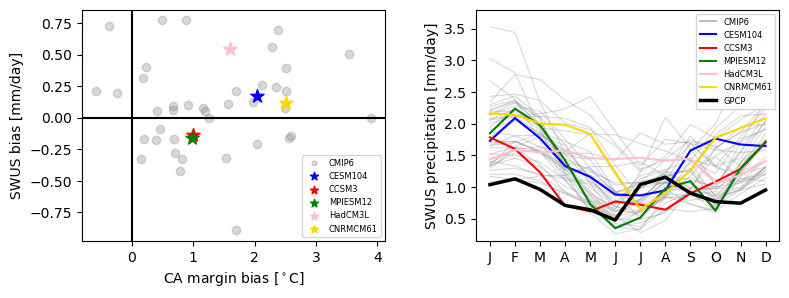

In [66]:
fig, ax = plt.subplots(1,2,figsize = (9,3),gridspec_kw={"wspace": 0.3})

ax[0].scatter(ca_cmip_bias, sw_cmip_bias, color = 'grey', alpha = 0.3, label = 'CMIP6')
for i, model in enumerate(all_models):
    pr_bias = sw_five[i] - sw_obs
    tas_bias = ca_five[i] - ca_obs
    ax[0].scatter(tas_bias, pr_bias, color = model_colors[model], label = model, marker = '*', s = 100)

ax[0].legend(fontsize = 6,markerscale=0.6,)
ax[0].set_xlabel('CA margin bias [$^\circ$C]')
ax[0].set_ylabel('SWUS bias [mm/day]')
ax[0].axhline(0, color = 'k')
ax[0].axvline(0, color = 'k')




months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
for model in models_cmip:
    if seasonal_sw[model][0] < 0.2:
        continue
        
    ax[1].plot(np.arange(1,13,1), seasonal_sw[model], color = 'grey', alpha = 0.3, linewidth = 0.8)


ax[1].plot(np.arange(1,13,1), np.zeros(12), color = 'grey', alpha = 0.5, label = 'CMIP6' )
for model in models_five:
    ax[1].plot(np.arange(1,13,1), seasonal_sw_five[model], label = model, color = model_colors[model], linewidth = 1.5)

ax[1].plot(np.arange(1,13,1), obs_cycle, label = 'GPCP', color = 'k', linewidth=2.5)
ax[1].legend(fontsize = 6,loc = 'upper right')
ax[1].set_ylim([0.15,3.8])
ax[1].set_xticks(np.arange(1,13,1), months)
# ax[1].set_yticks( fontsize = 12)
ax[1].set_ylabel('SWUS precipitation [mm/day]')
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_review2/bias_together.jpg', dpi = 300,bbox_inches="tight")


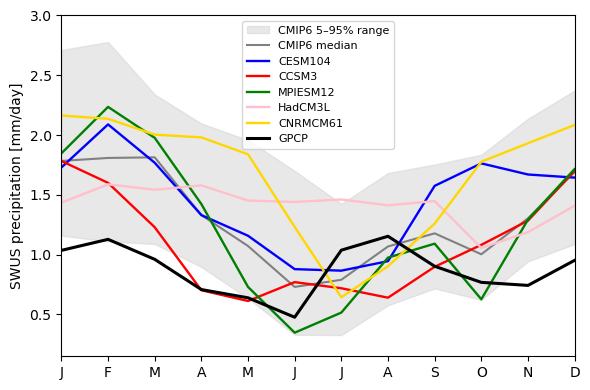

In [272]:
cmip_cycles = []

for model in models_cmip:
    cycle = xr.DataArray(seasonal_sw[model], dims = 'month', coords = {'month':np.arange(1,13,1)})

    if np.isfinite(cycle).all():
        cmip_cycles.append(cycle.expand_dims(model=[model]))

cmip_cycles = xr.concat(cmip_cycles, dim="model")

cmip_median = cmip_cycles.median("model")
cmip_low = cmip_cycles.quantile(0.05, dim="model")
cmip_high = cmip_cycles.quantile(0.95, dim="model")

fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(1, 13)
month_labels = ["J", "F", "M", "A", "M", "J",
                "J", "A", "S", "O", "N", "D"]

ax.fill_between(
    x,
    cmip_low,
    cmip_high,
    color="lightgray",
    alpha=0.5,
    label="CMIP6 5–95% range"
)

ax.plot(
    x,
    cmip_median,
    color="gray",
    linewidth=1.5,
    label="CMIP6 median"
)

for model in models_five:
    ax.plot(
        x,
        seasonal_sw_five[model],
        color=model_colors[model],
        linewidth=1.7,
        label=model
    )

ax.plot(
    x,
    obs_cycle,
    color="black",
    linewidth=2.2,
    label="GPCP"
)

# # Highlight JJAS
# ax.axvspan(6,9, color="gold", alpha=0.08)

ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_ylabel(r"SWUS precipitation [mm/day]")
ax.set_xlim(1, 12)
ax.set_ylim(0.15, 3.)
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig('/scratch/olee/research/Paleo_group/First_paper/cleaned_code/figs_review2/seasonal_cycl2.jpg', dpi = 300,bbox_inches="tight")
